# Chapter 39: Delay Is a Curve, Not a Line

*Systems Thinking with AI* by Jason Karpeles

Taxi-out rises with load while the quoted delay falls, and a cap can only be priced on the curve.

**Goal.** Four demonstrations on the airport record the chapter's pack reads. Compare taxi-out and departure delay against load, test a fitted convex curve on two years, price two schedule caps on the curve, and watch padding hide delay. The curve is inferred from the committed record, pooled across thirty airports, and consistent with a congestion structure without being evidence for one. Varied values are constructed, and nothing is a forecast.

**Demonstrations**

1. Two measures, two slopes
2. A convex curve fitted to one year
3. Pricing a cap needs two points on the curve
4. Padding hides the delay it responds to

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/39-congestion-curve/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/39-congestion-curve/reader.html).

The observed series is the committed public record used by the chapter (US Bureau of Transportation Statistics on-time records, aggregated by airport). Fitted values are inferred from that record, and nothing here is a forecast.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The public record

The chapter reads its observed series from these files. They are written into a working folder so the model code reads them exactly as the book does.

In [2]:
RECORD_FILES = {}
RECORD_FILES['data/bts_ontime/airport_month_delay.csv'] = '''\
airport,period,scheduled_departures,peak_hour_departures,mean_dep_delay_minutes,cancellation_share,mean_taxi_out,departures_above_p90,departures_above_p95,p90_hourly_departures,p95_hourly_departures,load
ATL,2023-01-01,26582,71.742,16.487,0.00888,16.037,130.0,22.0,68.0,73.0,0.9828
ATL,2023-02-01,24126,69.857,9.539,0.00518,15.407,67.0,1.0,68.0,73.0,0.9569
ATL,2023-03-01,28350,77.613,15.909,0.01104,15.958,458.0,239.0,68.0,73.0,1.0632
ATL,2023-04-01,27535,79.133,15.145,0.01464,15.896,516.0,216.0,68.0,73.0,1.084
ATL,2023-05-01,28740,77.581,11.632,0.00341,15.226,488.0,152.0,68.0,73.0,1.0627
ATL,2023-06-01,28685,77.633,21.083,0.013,16.935,594.0,210.0,68.0,73.0,1.0635
ATL,2023-07-01,29919,78.323,21.352,0.01377,17.041,583.0,249.0,68.0,73.0,1.0729
ATL,2023-08-01,29431,78.0,19.174,0.02195,17.402,430.0,181.0,68.0,73.0,1.0685
ATL,2023-09-01,28344,77.4,9.873,0.00303,15.463,514.0,186.0,68.0,73.0,1.0603
ATL,2023-10-01,29251,78.129,7.641,0.00144,15.455,655.0,224.0,68.0,73.0,1.0703
ATL,2023-11-01,27473,79.033,6.448,0.00036,15.254,551.0,256.0,68.0,73.0,1.0826
ATL,2023-12-01,28027,79.097,8.539,0.00086,15.515,598.0,248.0,68.0,73.0,1.0835
ATL,2024-01-01,26315,76.452,14.876,0.01034,16.435,431.0,163.0,68.0,73.0,1.0473
ATL,2024-02-01,24821,79.0,7.224,0.00085,15.714,478.0,206.0,68.0,73.0,1.0822
ATL,2024-03-01,28459,78.645,11.618,0.00271,16.062,778.0,281.0,68.0,73.0,1.0773
ATL,2024-04-01,28419,79.667,11.408,0.00201,16.399,697.0,278.0,68.0,73.0,1.0913
ATL,2024-05-01,29870,84.742,17.973,0.00579,17.184,1045.0,532.0,68.0,73.0,1.1608
ATL,2024-06-01,29361,80.9,13.828,0.00487,16.285,881.0,378.0,68.0,73.0,1.1082
ATL,2024-07-01,30072,81.129,32.624,0.05912,18.808,898.0,429.0,68.0,73.0,1.1114
ATL,2024-08-01,29480,78.871,14.609,0.01035,16.43,607.0,263.0,68.0,73.0,1.0804
ATL,2024-09-01,28247,76.5,10.603,0.00832,15.752,456.0,153.0,68.0,73.0,1.0479
ATL,2024-10-01,29837,83.839,6.957,0.00858,15.541,860.0,490.0,68.0,73.0,1.1485
ATL,2024-11-01,28015,83.133,7.821,0.00082,16.187,821.0,425.0,68.0,73.0,1.1388
ATL,2024-12-01,29014,85.516,14.617,0.00241,16.835,972.0,573.0,68.0,73.0,1.1715
AUS,2023-01-01,7425,20.871,15.891,0.03313,14.955,81.0,30.0,19.0,20.0,1.0435
AUS,2023-02-01,6763,21.321,14.505,0.03992,15.104,92.0,42.0,19.0,20.0,1.0661
AUS,2023-03-01,7820,21.419,15.15,0.011,14.56,118.0,52.0,19.0,20.0,1.071
AUS,2023-04-01,7438,19.4,18.923,0.0164,14.833,27.0,9.0,19.0,20.0,0.97
AUS,2023-05-01,7877,19.419,14.342,0.00609,14.422,29.0,7.0,19.0,20.0,0.971
AUS,2023-06-01,7728,20.6,22.461,0.01281,14.399,109.0,42.0,19.0,20.0,1.03
AUS,2023-07-01,8059,20.452,18.791,0.01253,13.799,77.0,31.0,19.0,20.0,1.0226
AUS,2023-08-01,8137,21.226,16.508,0.01106,14.322,135.0,66.0,19.0,20.0,1.0613
AUS,2023-09-01,7831,21.067,16.94,0.00843,15.203,157.0,86.0,19.0,20.0,1.0533
AUS,2023-10-01,8357,21.161,14.34,0.00215,15.163,157.0,67.0,19.0,20.0,1.0581
AUS,2023-11-01,7714,20.867,11.738,0.00104,15.11,99.0,49.0,19.0,20.0,1.0433
AUS,2023-12-01,7664,21.387,11.22,0.00261,15.211,128.0,57.0,19.0,20.0,1.0694
AUS,2024-01-01,6692,20.419,19.444,0.03347,15.723,86.0,42.0,19.0,20.0,1.021
AUS,2024-02-01,5873,19.793,9.704,0.00358,14.551,47.0,18.0,19.0,20.0,0.9897
AUS,2024-03-01,7154,20.097,16.455,0.00713,15.091,59.0,33.0,19.0,20.0,1.0048
AUS,2024-04-01,7304,21.033,16.938,0.00548,15.028,95.0,50.0,19.0,20.0,1.0517
AUS,2024-05-01,7852,22.161,31.664,0.01541,15.835,124.0,80.0,19.0,20.0,1.1081
AUS,2024-06-01,7551,20.067,21.825,0.00728,13.865,71.0,23.0,19.0,20.0,1.0033
AUS,2024-07-01,7754,20.774,27.341,0.02076,14.016,102.0,39.0,19.0,20.0,1.0387
AUS,2024-08-01,7157,20.742,16.711,0.00922,13.536,118.0,65.0,19.0,20.0,1.0371
AUS,2024-09-01,6816,20.433,9.468,0.00308,16.023,96.0,40.0,19.0,20.0,1.0217
AUS,2024-10-01,7398,20.903,9.671,0.00581,15.661,104.0,48.0,19.0,20.0,1.0452
AUS,2024-11-01,6861,20.867,11.137,0.00423,15.988,89.0,52.0,19.0,20.0,1.0433
AUS,2024-12-01,6932,20.581,17.156,0.00418,15.515,79.0,37.0,19.0,20.0,1.029
BNA,2023-01-01,7590,23.452,14.884,0.02332,14.817,124.0,28.0,21.0,23.0,1.0196
BNA,2023-02-01,6971,24.179,10.475,0.01736,15.353,143.0,34.0,21.0,23.0,1.0512
BNA,2023-03-01,8002,25.129,16.523,0.01587,15.543,248.0,100.0,21.0,23.0,1.0926
BNA,2023-04-01,7780,25.267,16.013,0.01234,14.957,212.0,87.0,21.0,23.0,1.0986
BNA,2023-05-01,8253,22.903,12.884,0.00727,15.558,98.0,21.0,21.0,23.0,0.9958
BNA,2023-06-01,7981,23.0,21.389,0.01666,15.929,72.0,9.0,21.0,23.0,1.0
BNA,2023-07-01,8322,27.032,23.003,0.02151,15.092,220.0,131.0,21.0,23.0,1.1753
BNA,2023-08-01,8203,24.839,13.287,0.01231,14.855,144.0,70.0,21.0,23.0,1.0799
BNA,2023-09-01,8064,25.5,13.021,0.0098,15.061,208.0,87.0,21.0,23.0,1.1087
BNA,2023-10-01,8923,27.161,10.888,0.00303,15.29,337.0,163.0,21.0,23.0,1.1809
BNA,2023-11-01,8161,27.4,9.636,0.00061,16.181,257.0,139.0,21.0,23.0,1.1913
BNA,2023-12-01,8239,25.452,12.239,0.0034,15.919,172.0,85.0,21.0,23.0,1.1066
BNA,2024-01-01,7556,23.871,21.206,0.06908,17.876,143.0,67.0,21.0,23.0,1.0379
BNA,2024-02-01,7010,23.655,8.564,0.00243,15.518,134.0,59.0,21.0,23.0,1.0285
BNA,2024-03-01,8287,23.806,13.54,0.007,15.069,100.0,40.0,21.0,23.0,1.0351
BNA,2024-04-01,8282,24.667,12.7,0.00386,13.997,215.0,80.0,21.0,23.0,1.0725
BNA,2024-05-01,8811,27.0,23.699,0.00874,14.863,397.0,189.0,21.0,23.0,1.1739
BNA,2024-06-01,8899,26.7,19.2,0.01034,14.753,279.0,132.0,21.0,23.0,1.1609
BNA,2024-07-01,9145,27.419,21.691,0.0175,14.882,300.0,158.0,21.0,23.0,1.1921
BNA,2024-08-01,8770,26.065,15.066,0.01722,16.084,332.0,148.0,21.0,23.0,1.1332
BNA,2024-09-01,8290,26.233,10.442,0.00495,16.129,300.0,137.0,21.0,23.0,1.1406
BNA,2024-10-01,8985,27.871,8.285,0.00768,15.954,404.0,206.0,21.0,23.0,1.2118
BNA,2024-11-01,8114,23.733,8.52,0.00246,15.557,129.0,28.0,21.0,23.0,1.0319
BNA,2024-12-01,8071,25.161,13.839,0.00421,16.31,221.0,102.0,21.0,23.0,1.094
BOS,2023-01-01,10871,36.645,16.369,0.01444,22.562,181.0,81.0,31.0,35.0,1.047
BOS,2023-02-01,10594,35.786,17.076,0.02256,22.095,177.0,53.0,31.0,35.0,1.0224
BOS,2023-03-01,12339,33.71,16.23,0.02456,20.334,222.0,10.0,31.0,35.0,0.9631
BOS,2023-04-01,12069,36.067,16.456,0.014,18.818,220.0,75.0,31.0,35.0,1.0305
BOS,2023-05-01,12428,37.258,12.626,0.00402,20.069,376.0,165.0,31.0,35.0,1.0645
BOS,2023-06-01,11781,40.333,22.393,0.02657,20.212,444.0,176.0,31.0,35.0,1.1524
BOS,2023-07-01,12133,41.516,32.19,0.05192,22.681,514.0,243.0,31.0,35.0,1.1862
BOS,2023-08-01,12389,42.677,21.05,0.0138,21.712,515.0,272.0,31.0,35.0,1.2194
BOS,2023-09-01,11742,38.733,24.644,0.03313,18.61,494.0,182.0,31.0,35.0,1.1067
BOS,2023-10-01,12369,40.645,12.704,0.00154,19.139,598.0,233.0,31.0,35.0,1.1613
BOS,2023-11-01,11142,37.533,10.027,0.00099,18.804,322.0,132.0,31.0,35.0,1.0724
BOS,2023-12-01,10660,39.871,14.348,0.00779,19.033,296.0,156.0,31.0,35.0,1.1392
BOS,2024-01-01,10134,38.323,19.434,0.03207,22.062,234.0,106.0,31.0,35.0,1.0949
BOS,2024-02-01,10118,37.621,10.67,0.01077,19.318,268.0,91.0,31.0,35.0,1.0749
BOS,2024-03-01,11324,38.258,13.16,0.00556,18.72,407.0,115.0,31.0,35.0,1.0931
BOS,2024-04-01,11591,41.167,14.493,0.01035,19.78,604.0,270.0,31.0,35.0,1.1762
BOS,2024-05-01,12659,39.516,17.145,0.00703,19.175,502.0,223.0,31.0,35.0,1.129
BOS,2024-06-01,12568,41.767,19.207,0.0156,21.393,592.0,311.0,31.0,35.0,1.1933
BOS,2024-07-01,12953,42.774,22.19,0.02856,21.473,652.0,377.0,31.0,35.0,1.2221
BOS,2024-08-01,13215,44.839,22.712,0.03693,21.95,698.0,434.0,31.0,35.0,1.2811
BOS,2024-09-01,12359,39.033,12.011,0.00388,19.356,506.0,208.0,31.0,35.0,1.1152
BOS,2024-10-01,13035,39.613,8.823,0.00759,20.897,587.0,250.0,31.0,35.0,1.1318
BOS,2024-11-01,11756,39.133,9.735,0.00068,20.469,495.0,180.0,31.0,35.0,1.1181
BOS,2024-12-01,11778,35.645,18.337,0.01409,22.431,252.0,75.0,31.0,35.0,1.0184
BWI,2023-01-01,7393,26.226,14.301,0.01407,13.442,148.0,21.0,23.0,26.0,1.0087
BWI,2023-02-01,6681,26.571,10.473,0.00943,13.507,146.0,29.0,23.0,26.0,1.022
BWI,2023-03-01,7591,31.839,15.772,0.01001,13.849,327.0,187.0,23.0,26.0,1.2246
BWI,2023-04-01,7795,29.867,22.413,0.01437,14.378,316.0,136.0,23.0,26.0,1.1487
BWI,2023-05-01,8316,29.484,13.69,0.00349,13.644,339.0,132.0,23.0,26.0,1.134
BWI,2023-06-01,8010,28.6,23.894,0.01648,14.99,206.0,86.0,23.0,26.0,1.1
BWI,2023-07-01,8471,27.29,30.754,0.01794,15.854,260.0,60.0,23.0,26.0,1.0496
BWI,2023-08-01,8507,26.548,19.915,0.0181,14.701,252.0,36.0,23.0,26.0,1.0211
BWI,2023-09-01,8012,27.233,15.325,0.01498,15.211,223.0,100.0,23.0,26.0,1.0474
BWI,2023-10-01,8784,26.806,13.209,0.00285,14.075,221.0,73.0,23.0,26.0,1.031
BWI,2023-11-01,8293,30.433,10.572,0.00096,13.926,282.0,137.0,23.0,26.0,1.1705
BWI,2023-12-01,8418,29.774,15.478,0.00558,14.319,246.0,120.0,23.0,26.0,1.1452
BWI,2024-01-01,7551,26.065,18.252,0.03629,16.616,116.0,46.0,23.0,26.0,1.0025
BWI,2024-02-01,6894,25.517,9.27,0.00261,14.129,99.0,27.0,23.0,26.0,0.9814
BWI,2024-03-01,8076,29.452,18.007,0.00706,14.31,286.0,147.0,23.0,26.0,1.1328
BWI,2024-04-01,8230,27.733,15.785,0.00644,14.643,211.0,72.0,23.0,26.0,1.0667
BWI,2024-05-01,8654,27.484,20.975,0.00601,14.89,204.0,68.0,23.0,26.0,1.0571
BWI,2024-06-01,8779,28.233,20.876,0.01048,15.04,290.0,100.0,23.0,26.0,1.0859
BWI,2024-07-01,9069,27.839,29.239,0.01632,16.431,307.0,94.0,23.0,26.0,1.0707
BWI,2024-08-01,8940,28.323,23.802,0.02584,17.071,319.0,101.0,23.0,26.0,1.0893
BWI,2024-09-01,8273,28.0,10.609,0.00568,14.811,275.0,78.0,23.0,26.0,1.0769
BWI,2024-10-01,8402,28.129,9.722,0.0144,14.308,275.0,88.0,23.0,26.0,1.0819
BWI,2024-11-01,7796,26.333,9.016,0.00128,14.4,152.0,44.0,23.0,26.0,1.0128
BWI,2024-12-01,7908,26.323,15.033,0.00303,14.522,169.0,72.0,23.0,26.0,1.0124
CLT,2023-01-01,15170,59.355,14.7,0.01365,20.502,140.0,39.0,57.0,59.0,1.006
CLT,2023-02-01,14234,61.286,10.401,0.00527,19.736,158.0,64.0,57.0,59.0,1.0387
CLT,2023-03-01,16457,62.065,13.911,0.00687,20.448,300.0,110.0,57.0,59.0,1.0519
CLT,2023-04-01,15674,60.833,17.728,0.00829,20.111,142.0,63.0,57.0,59.0,1.0311
CLT,2023-05-01,16121,58.129,13.769,0.00217,19.822,61.0,3.0,57.0,59.0,0.9852
CLT,2023-06-01,16674,61.633,25.319,0.01751,20.894,263.0,108.0,57.0,59.0,1.0446
CLT,2023-07-01,16976,64.323,29.843,0.02115,21.101,370.0,210.0,57.0,59.0,1.0902
CLT,2023-08-01,17319,60.548,25.309,0.02061,20.359,176.0,58.0,57.0,59.0,1.0262
CLT,2023-09-01,16175,61.733,15.491,0.00958,20.993,270.0,116.0,57.0,59.0,1.0463
CLT,2023-10-01,17372,60.355,10.783,0.00144,20.36,181.0,67.0,57.0,59.0,1.023
CLT,2023-11-01,16708,59.967,10.263,0.00036,19.911,126.0,48.0,57.0,59.0,1.0164
CLT,2023-12-01,16220,56.968,13.105,0.00166,20.309,43.0,16.0,57.0,59.0,0.9656
CLT,2024-01-01,16378,60.258,20.353,0.01838,19.832,146.0,55.0,57.0,59.0,1.0213
CLT,2024-02-01,15768,60.69,10.403,0.00165,20.381,155.0,61.0,57.0,59.0,1.0286
CLT,2024-03-01,17400,61.161,17.182,0.00351,20.724,157.0,76.0,57.0,59.0,1.0366
CLT,2024-04-01,18144,63.533,17.09,0.00485,21.457,470.0,288.0,57.0,59.0,1.0768
CLT,2024-05-01,19203,61.903,29.397,0.01359,22.294,359.0,177.0,57.0,59.0,1.0492
CLT,2024-06-01,18712,64.467,25.199,0.01667,21.349,519.0,334.0,57.0,59.0,1.0927
CLT,2024-07-01,19043,63.935,45.1,0.03686,22.258,462.0,265.0,57.0,59.0,1.0837
CLT,2024-08-01,19150,63.097,26.657,0.03222,21.868,242.0,138.0,57.0,59.0,1.0694
CLT,2024-09-01,18658,65.133,16.983,0.01978,22.369,310.0,201.0,57.0,59.0,1.104
CLT,2024-10-01,19752,69.194,12.505,0.00876,23.049,809.0,583.0,57.0,59.0,1.1728
CLT,2024-11-01,17515,67.267,8.672,0.00046,22.348,375.0,279.0,57.0,59.0,1.1401
CLT,2024-12-01,17832,62.323,17.397,0.00331,21.801,243.0,142.0,57.0,59.0,1.0563
DAL,2023-01-01,5986,15.29,14.038,0.05246,11.968,16.0,2.0,15.0,16.0,0.9556
DAL,2023-02-01,5444,15.857,8.525,0.04849,12.437,31.0,10.0,15.0,16.0,0.9911
DAL,2023-03-01,6188,16.871,13.646,0.01568,12.506,81.0,28.0,15.0,16.0,1.0544
DAL,2023-04-01,5922,16.267,15.357,0.02634,12.61,65.0,13.0,15.0,16.0,1.0167
DAL,2023-05-01,6176,16.645,13.379,0.00648,11.554,80.0,25.0,15.0,16.0,1.0403
DAL,2023-06-01,6256,17.5,23.356,0.01087,12.637,178.0,86.0,15.0,16.0,1.0938
DAL,2023-07-01,6506,17.742,16.742,0.00523,11.897,215.0,128.0,15.0,16.0,1.1089
DAL,2023-08-01,6611,18.0,10.984,0.00908,11.344,221.0,121.0,15.0,16.0,1.125
DAL,2023-09-01,6221,17.333,11.286,0.00402,12.463,145.0,55.0,15.0,16.0,1.0833
DAL,2023-10-01,6591,17.194,11.818,0.00486,12.427,124.0,47.0,15.0,16.0,1.0746
DAL,2023-11-01,6307,17.8,8.96,0.00174,12.054,142.0,61.0,15.0,16.0,1.1125
DAL,2023-12-01,6549,18.0,9.66,0.00351,11.752,147.0,70.0,15.0,16.0,1.125
DAL,2024-01-01,6037,17.032,14.753,0.03528,12.724,86.0,36.0,15.0,16.0,1.0645
DAL,2024-02-01,5522,16.724,8.358,0.00145,11.861,68.0,25.0,15.0,16.0,1.0453
DAL,2024-03-01,6272,17.032,14.787,0.00749,12.776,111.0,45.0,15.0,16.0,1.0645
DAL,2024-04-01,6080,16.933,18.418,0.00954,12.578,113.0,47.0,15.0,16.0,1.0583
DAL,2024-05-01,6207,16.806,28.23,0.03238,13.914,109.0,37.0,15.0,16.0,1.0504
DAL,2024-06-01,6275,17.5,19.48,0.00335,12.49,128.0,54.0,15.0,16.0,1.0938
DAL,2024-07-01,6447,17.548,19.292,0.00791,12.01,134.0,56.0,15.0,16.0,1.0968
DAL,2024-08-01,5891,17.032,11.902,0.00526,13.087,82.0,40.0,15.0,16.0,1.0645
DAL,2024-09-01,5602,16.9,8.724,0.00286,14.722,68.0,34.0,15.0,16.0,1.0562
DAL,2024-10-01,6140,17.355,7.922,0.00603,14.317,111.0,72.0,15.0,16.0,1.0847
DAL,2024-11-01,5973,17.4,10.868,0.00954,13.076,82.0,46.0,15.0,16.0,1.0875
DAL,2024-12-01,6228,17.355,22.824,0.00739,13.057,94.0,53.0,15.0,16.0,1.0847
DCA,2023-01-01,11772,35.677,11.997,0.01699,20.661,206.0,86.0,32.0,34.0,1.0493
DCA,2023-02-01,11082,36.107,9.289,0.0111,20.888,192.0,82.0,32.0,34.0,1.062
DCA,2023-03-01,12338,38.161,10.327,0.00956,22.173,268.0,135.0,32.0,34.0,1.1224
DCA,2023-04-01,11688,38.733,13.999,0.01908,21.47,224.0,143.0,32.0,34.0,1.1392
DCA,2023-05-01,12202,38.323,10.109,0.00303,21.0,235.0,142.0,32.0,34.0,1.1271
DCA,2023-06-01,11455,36.267,19.898,0.02855,21.79,181.0,83.0,32.0,34.0,1.0667
DCA,2023-07-01,11566,35.581,26.414,0.0434,21.921,172.0,58.0,32.0,34.0,1.0465
DCA,2023-08-01,11912,36.484,16.234,0.01998,21.456,200.0,94.0,32.0,34.0,1.0731
DCA,2023-09-01,11513,38.3,15.193,0.02354,21.814,227.0,132.0,32.0,34.0,1.1265
DCA,2023-10-01,12110,38.194,9.037,0.00058,20.339,212.0,140.0,32.0,34.0,1.1233
DCA,2023-11-01,11353,39.3,8.416,0.0015,19.633,304.0,183.0,32.0,34.0,1.1559
DCA,2023-12-01,11014,37.419,12.724,0.0049,19.754,225.0,117.0,32.0,34.0,1.1006
DCA,2024-01-01,11486,36.355,19.666,0.05694,21.912,165.0,77.0,32.0,34.0,1.0693
DCA,2024-02-01,11298,37.483,9.564,0.00398,20.021,216.0,114.0,32.0,34.0,1.1024
DCA,2024-03-01,11970,38.258,13.752,0.00434,20.406,280.0,166.0,32.0,34.0,1.1252
DCA,2024-04-01,11546,38.6,14.939,0.00641,20.418,273.0,150.0,32.0,34.0,1.1353
DCA,2024-05-01,11965,38.258,19.801,0.00836,21.655,312.0,170.0,32.0,34.0,1.1252
DCA,2024-06-01,11457,38.567,18.169,0.01519,20.589,299.0,186.0,32.0,34.0,1.1343
DCA,2024-07-01,11948,39.258,26.534,0.03264,22.099,364.0,250.0,32.0,34.0,1.1546
DCA,2024-08-01,11874,39.419,22.289,0.03807,21.702,302.0,179.0,32.0,34.0,1.1594
DCA,2024-09-01,11546,41.3,10.204,0.00745,21.018,331.0,219.0,32.0,34.0,1.2147
DCA,2024-10-01,12035,41.419,8.833,0.0069,19.983,379.0,268.0,32.0,34.0,1.2182
DCA,2024-11-01,11545,36.133,9.749,0.00147,20.636,216.0,108.0,32.0,34.0,1.0627
DCA,2024-12-01,11346,36.129,18.573,0.00837,20.797,201.0,105.0,32.0,34.0,1.0626
DEN,2023-01-01,22460,73.484,21.65,0.035,21.245,444.0,24.0,66.0,76.0,0.9669
DEN,2023-02-01,20653,76.214,16.839,0.02169,18.175,488.0,32.0,66.0,76.0,1.0028
DEN,2023-03-01,23694,80.452,16.177,0.00785,17.858,738.0,173.0,66.0,76.0,1.0586
DEN,2023-04-01,22735,78.433,17.002,0.01306,17.21,586.0,95.0,66.0,76.0,1.032
DEN,2023-05-01,23997,79.129,19.373,0.01138,16.654,727.0,133.0,66.0,76.0,1.0412
DEN,2023-06-01,24185,78.667,28.556,0.02973,17.081,659.0,128.0,66.0,76.0,1.0351
DEN,2023-07-01,25684,80.581,29.215,0.02648,17.078,781.0,167.0,66.0,76.0,1.0603
DEN,2023-08-01,26308,82.258,18.57,0.01129,17.429,907.0,256.0,66.0,76.0,1.0823
DEN,2023-09-01,24738,85.6,13.897,0.00461,17.109,1126.0,418.0,66.0,76.0,1.1263
DEN,2023-10-01,25543,80.935,13.186,0.00388,18.304,917.0,194.0,66.0,76.0,1.0649
DEN,2023-11-01,23934,77.2,9.719,0.00134,17.327,585.0,56.0,66.0,76.0,1.0158
DEN,2023-12-01,25054,78.065,11.076,0.00379,17.703,565.0,73.0,66.0,76.0,1.0272
DEN,2024-01-01,23361,77.839,18.668,0.04242,17.847,802.0,85.0,66.0,76.0,1.0242
DEN,2024-02-01,21759,78.828,16.089,0.00942,21.265,799.0,108.0,66.0,76.0,1.0372
DEN,2024-03-01,24976,79.677,14.067,0.02082,18.711,841.0,119.0,66.0,76.0,1.0484
DEN,2024-04-01,24657,82.867,14.271,0.00402,18.646,1003.0,236.0,66.0,76.0,1.0904
DEN,2024-05-01,26368,83.097,20.811,0.00804,17.772,1319.0,363.0,66.0,76.0,1.0934
DEN,2024-06-01,27585,88.267,20.442,0.00765,18.445,2023.0,712.0,66.0,76.0,1.1614
DEN,2024-07-01,28401,87.323,20.874,0.01595,17.448,1701.0,591.0,66.0,76.0,1.149
DEN,2024-08-01,27334,87.226,19.149,0.00721,18.64,1820.0,607.0,66.0,76.0,1.1477
DEN,2024-09-01,26146,88.367,10.511,0.00199,17.363,1802.0,690.0,66.0,76.0,1.1627
DEN,2024-10-01,26929,84.419,9.064,0.00401,16.965,1618.0,463.0,66.0,76.0,1.1108
DEN,2024-11-01,25224,83.6,12.37,0.01392,21.347,1272.0,348.0,66.0,76.0,1.1
DEN,2024-12-01,25905,86.097,12.045,0.00332,16.999,1355.0,408.0,66.0,76.0,1.1329
DFW,2023-01-01,20502,75.839,14.299,0.03624,19.406,489.0,127.0,64.0,72.0,1.0533
DFW,2023-02-01,19910,74.107,16.352,0.04395,18.642,341.0,59.0,64.0,72.0,1.0293
DFW,2023-03-01,22583,78.226,21.349,0.02214,18.788,661.0,193.0,64.0,72.0,1.0865
DFW,2023-04-01,22870,72.333,19.061,0.02759,19.339,432.0,33.0,64.0,72.0,1.0046
DFW,2023-05-01,23900,74.613,18.867,0.00958,19.41,534.0,89.0,64.0,72.0,1.0363
DFW,2023-06-01,24996,77.167,27.655,0.01528,21.482,460.0,155.0,64.0,72.0,1.0718
DFW,2023-07-01,26010,75.387,24.621,0.00888,19.483,429.0,105.0,64.0,72.0,1.047
DFW,2023-08-01,26370,79.871,23.262,0.00868,18.881,574.0,247.0,64.0,72.0,1.1093
DFW,2023-09-01,24533,85.833,16.24,0.00624,20.881,1164.0,564.0,64.0,72.0,1.1921
DFW,2023-10-01,25786,87.677,14.885,0.01485,20.248,1404.0,804.0,64.0,72.0,1.2177
DFW,2023-11-01,24070,85.3,10.338,0.00158,20.169,1069.0,571.0,64.0,72.0,1.1847
DFW,2023-12-01,23714,82.097,10.199,0.00084,19.085,912.0,425.0,64.0,72.0,1.1402
DFW,2024-01-01,23570,82.29,23.081,0.02775,20.666,1056.0,527.0,64.0,72.0,1.1429
DFW,2024-02-01,22679,82.655,10.413,0.00101,18.644,1066.0,514.0,64.0,72.0,1.148
DFW,2024-03-01,25567,87.935,22.432,0.01709,19.809,1353.0,658.0,64.0,72.0,1.2213
DFW,2024-04-01,24911,81.267,21.067,0.02256,19.953,1328.0,532.0,64.0,72.0,1.1287
DFW,2024-05-01,27111,84.903,36.912,0.06355,21.654,1667.0,827.0,64.0,72.0,1.1792
DFW,2024-06-01,27690,83.833,28.088,0.01795,19.977,1627.0,611.0,64.0,72.0,1.1644
DFW,2024-07-01,29084,89.0,30.318,0.01791,20.019,1938.0,859.0,64.0,72.0,1.2361
DFW,2024-08-01,27900,91.871,21.24,0.01007,19.13,1970.0,1049.0,64.0,72.0,1.276
DFW,2024-09-01,26198,92.467,12.069,0.0029,20.959,1931.0,1006.0,64.0,72.0,1.2843
DFW,2024-10-01,27861,96.452,11.625,0.00348,19.113,2111.0,1168.0,64.0,72.0,1.3396
DFW,2024-11-01,25197,84.1,15.066,0.01707,19.616,1578.0,701.0,64.0,72.0,1.1681
DFW,2024-12-01,25814,79.742,22.523,0.02076,19.15,1186.0,453.0,64.0,72.0,1.1075
DTW,2023-01-01,9905,36.645,15.338,0.00959,20.609,195.0,8.0,33.0,37.0,0.9904
DTW,2023-02-01,9141,37.75,12.87,0.02254,17.697,170.0,27.0,33.0,37.0,1.0203
DTW,2023-03-01,10889,38.774,14.48,0.0248,18.145,209.0,62.0,33.0,37.0,1.048
DTW,2023-04-01,10389,39.167,12.376,0.01463,16.241,213.0,67.0,33.0,37.0,1.0586
DTW,2023-05-01,10680,36.613,7.528,0.00346,15.28,177.0,10.0,33.0,37.0,0.9895
DTW,2023-06-01,10524,43.567,17.953,0.01606,15.703,407.0,201.0,33.0,37.0,1.1775
DTW,2023-07-01,10999,46.129,20.61,0.01818,16.207,542.0,295.0,33.0,37.0,1.2467
DTW,2023-08-01,11211,48.387,18.908,0.01677,15.721,611.0,365.0,33.0,37.0,1.3078
DTW,2023-09-01,10819,46.067,11.148,0.011,16.068,525.0,285.0,33.0,37.0,1.245
DTW,2023-10-01,11213,44.548,8.317,0.00196,15.343,545.0,247.0,33.0,37.0,1.204
DTW,2023-11-01,10320,43.4,7.242,0.00019,17.726,606.0,257.0,33.0,37.0,1.173
DTW,2023-12-01,9982,41.065,8.95,0.0016,16.522,380.0,137.0,33.0,37.0,1.1099
DTW,2024-01-01,9473,47.548,25.798,0.0342,23.776,915.0,578.0,33.0,37.0,1.2851
DTW,2024-02-01,9097,50.414,7.88,0.00176,17.287,1109.0,750.0,33.0,37.0,1.3625
DTW,2024-03-01,10760,50.935,11.898,0.00251,17.105,1419.0,891.0,33.0,37.0,1.3766
DTW,2024-04-01,10770,44.333,11.58,0.00427,16.937,1034.0,523.0,33.0,37.0,1.1982
DTW,2024-05-01,11294,44.097,15.263,0.00487,17.222,1146.0,641.0,33.0,37.0,1.1918
DTW,2024-06-01,11408,45.3,18.891,0.0064,16.96,846.0,389.0,33.0,37.0,1.2243
DTW,2024-07-01,11751,45.129,23.553,0.0411,16.641,757.0,342.0,33.0,37.0,1.2197
DTW,2024-08-01,11834,46.935,18.369,0.01513,16.431,865.0,424.0,33.0,37.0,1.2685
DTW,2024-09-01,11165,46.067,8.151,0.00278,15.743,648.0,326.0,33.0,37.0,1.245
DTW,2024-10-01,11731,46.194,8.177,0.00469,16.353,806.0,401.0,33.0,37.0,1.2485
DTW,2024-11-01,10986,43.467,8.98,0.001,18.621,700.0,316.0,33.0,37.0,1.1748
DTW,2024-12-01,11098,44.516,17.042,0.00487,20.156,753.0,349.0,33.0,37.0,1.2031
EWR,2023-01-01,11623,31.323,17.789,0.01058,22.526,124.0,57.0,28.0,30.0,1.0441
EWR,2023-02-01,10991,33.464,14.925,0.01092,23.397,295.0,156.0,28.0,30.0,1.1155
EWR,2023-03-01,12593,33.903,16.912,0.01064,24.659,417.0,204.0,28.0,30.0,1.1301
EWR,2023-04-01,12022,30.767,23.867,0.03702,25.045,218.0,38.0,28.0,30.0,1.0256
EWR,2023-05-01,12371,31.935,14.691,0.00356,23.347,222.0,72.0,28.0,30.0,1.0645
EWR,2023-06-01,11339,30.3,34.96,0.08475,25.283,78.0,23.0,28.0,30.0,1.01
EWR,2023-07-01,11646,30.419,37.613,0.1057,27.499,110.0,24.0,28.0,30.0,1.014
EWR,2023-08-01,11561,30.129,15.962,0.01548,24.102,81.0,11.0,28.0,30.0,1.0043
EWR,2023-09-01,11373,32.933,18.525,0.04924,24.836,265.0,133.0,28.0,30.0,1.0978
EWR,2023-10-01,11805,32.452,7.911,0.00169,22.186,266.0,99.0,28.0,30.0,1.0817
EWR,2023-11-01,10737,29.533,8.277,0.00075,21.244,76.0,7.0,28.0,30.0,0.9844
EWR,2023-12-01,10517,27.613,11.089,0.00114,21.199,24.0,3.0,28.0,30.0,0.9204
EWR,2024-01-01,10176,27.581,15.914,0.06938,22.003,19.0,0.0,28.0,30.0,0.9194
EWR,2024-02-01,9893,28.655,9.231,0.01253,20.814,36.0,2.0,28.0,30.0,0.9552
EWR,2024-03-01,10697,29.323,14.964,0.00608,21.554,45.0,5.0,28.0,30.0,0.9774
EWR,2024-04-01,10729,29.2,16.143,0.01361,23.81,59.0,2.0,28.0,30.0,0.9733
EWR,2024-05-01,11358,30.097,17.865,0.01321,24.146,138.0,29.0,28.0,30.0,1.0032
EWR,2024-06-01,10768,31.167,24.496,0.03622,25.36,148.0,50.0,28.0,30.0,1.0389
EWR,2024-07-01,11102,31.29,32.584,0.04963,28.642,139.0,50.0,28.0,30.0,1.043
EWR,2024-08-01,10861,30.613,25.803,0.07283,26.311,115.0,35.0,28.0,30.0,1.0204
EWR,2024-09-01,10572,32.333,10.568,0.00851,25.025,155.0,75.0,28.0,30.0,1.0778
EWR,2024-10-01,11260,32.452,10.982,0.01146,23.762,205.0,107.0,28.0,30.0,1.0817
EWR,2024-11-01,10698,29.0,15.494,0.00308,24.897,58.0,2.0,28.0,30.0,0.9667
EWR,2024-12-01,10865,28.806,17.661,0.0069,24.854,36.0,0.0,28.0,30.0,0.9602
FLL,2023-01-01,7600,27.452,23.623,0.01355,17.06,285.0,139.0,20.0,23.0,1.1935
FLL,2023-02-01,7133,28.071,16.258,0.00631,16.95,334.0,149.0,20.0,23.0,1.2205
FLL,2023-03-01,8570,25.742,22.859,0.01027,18.428,407.0,147.0,20.0,23.0,1.1192
FLL,2023-04-01,8071,25.767,35.184,0.08462,20.47,344.0,129.0,20.0,23.0,1.1203
FLL,2023-05-01,7426,25.355,19.591,0.00593,17.2,241.0,85.0,20.0,23.0,1.1024
FLL,2023-06-01,6890,22.833,40.194,0.03222,19.727,129.0,32.0,20.0,23.0,0.9928
FLL,2023-07-01,7137,23.194,37.395,0.0248,18.508,118.0,36.0,20.0,23.0,1.0084
FLL,2023-08-01,7024,21.29,30.421,0.01837,18.506,60.0,8.0,20.0,23.0,0.9257
FLL,2023-09-01,6571,22.833,20.803,0.01294,17.377,95.0,18.0,20.0,23.0,0.9928
FLL,2023-10-01,7290,25.065,15.453,0.00316,16.992,206.0,72.0,20.0,23.0,1.0898
FLL,2023-11-01,7683,24.933,19.724,0.0013,16.246,304.0,112.0,20.0,23.0,1.0841
FLL,2023-12-01,8440,25.548,21.413,0.0045,17.162,373.0,141.0,20.0,23.0,1.1108
FLL,2024-01-01,8460,26.097,22.217,0.03132,18.227,491.0,210.0,20.0,23.0,1.1346
FLL,2024-02-01,8111,27.138,18.104,0.00555,17.63,550.0,235.0,20.0,23.0,1.1799
FLL,2024-03-01,9235,26.903,28.095,0.01505,19.466,670.0,240.0,20.0,23.0,1.1697
FLL,2024-04-01,8299,27.133,18.09,0.00904,16.575,446.0,189.0,20.0,23.0,1.1797
FLL,2024-05-01,7892,26.161,21.601,0.00862,17.295,388.0,134.0,20.0,23.0,1.1374
FLL,2024-06-01,7290,25.1,22.741,0.04047,18.0,232.0,69.0,20.0,23.0,1.0913
FLL,2024-07-01,7391,24.806,26.797,0.02868,17.353,181.0,56.0,20.0,23.0,1.0785
FLL,2024-08-01,6885,25.387,26.547,0.035,18.059,173.0,79.0,20.0,23.0,1.1038
FLL,2024-09-01,6037,21.8,13.082,0.00596,19.62,97.0,14.0,20.0,23.0,0.9478
FLL,2024-10-01,6766,22.71,10.411,0.0102,16.492,117.0,38.0,20.0,23.0,0.9874
FLL,2024-11-01,7305,24.667,9.998,0.00137,15.266,302.0,113.0,20.0,23.0,1.0725
FLL,2024-12-01,8219,25.419,19.206,0.00535,16.971,379.0,141.0,20.0,23.0,1.1052
IAH,2023-01-01,9123,36.581,20.562,0.01282,19.92,465.0,134.0,29.0,33.0,1.1085
IAH,2023-02-01,8653,42.107,13.9,0.00786,19.384,530.0,264.0,29.0,33.0,1.276
IAH,2023-03-01,9726,42.226,16.199,0.00565,19.693,489.0,290.0,29.0,33.0,1.2796
IAH,2023-04-01,8753,38.633,24.402,0.0144,19.849,343.0,169.0,29.0,33.0,1.1707
IAH,2023-05-01,9395,37.839,23.374,0.01629,18.337,346.0,150.0,29.0,33.0,1.1466
IAH,2023-06-01,9385,40.6,28.477,0.03175,18.724,448.0,232.0,29.0,33.0,1.2303
IAH,2023-07-01,9775,39.839,26.195,0.01913,17.585,544.0,301.0,29.0,33.0,1.2072
IAH,2023-08-01,9786,42.194,15.544,0.0092,17.955,579.0,330.0,29.0,33.0,1.2786
IAH,2023-09-01,9283,41.367,15.196,0.0056,18.828,424.0,256.0,29.0,33.0,1.2535
IAH,2023-10-01,9918,43.355,13.151,0.00434,20.278,491.0,321.0,29.0,33.0,1.3138
IAH,2023-11-01,9019,42.533,8.856,0.00044,19.966,465.0,292.0,29.0,33.0,1.2889
IAH,2023-12-01,9076,42.774,10.402,0.00077,18.793,518.0,308.0,29.0,33.0,1.2962
IAH,2024-01-01,8933,40.742,23.132,0.06291,20.687,493.0,246.0,29.0,33.0,1.2346
IAH,2024-02-01,8464,40.345,9.736,0.00248,19.25,488.0,243.0,29.0,33.0,1.2226
IAH,2024-03-01,9557,39.161,18.795,0.00638,19.13,449.0,199.0,29.0,33.0,1.1867
IAH,2024-04-01,9288,40.067,15.541,0.00463,19.786,364.0,212.0,29.0,33.0,1.2141
IAH,2024-05-01,10125,41.065,39.652,0.03358,20.91,526.0,258.0,29.0,33.0,1.2444
IAH,2024-06-01,10028,42.067,26.644,0.01336,19.747,647.0,320.0,29.0,33.0,1.2747
IAH,2024-07-01,10383,42.71,38.423,0.07705,20.411,577.0,306.0,29.0,33.0,1.2942
IAH,2024-08-01,10284,42.065,19.676,0.01468,18.682,671.0,306.0,29.0,33.0,1.2747
IAH,2024-09-01,9502,39.7,11.251,0.00589,19.012,753.0,390.0,29.0,33.0,1.203
IAH,2024-10-01,10228,41.129,10.519,0.00508,18.796,984.0,512.0,29.0,33.0,1.2463
IAH,2024-11-01,9576,38.433,11.231,0.00219,20.141,632.0,274.0,29.0,33.0,1.1646
IAH,2024-12-01,9572,39.806,20.142,0.01181,20.132,616.0,281.0,29.0,33.0,1.2063
JFK,2023-01-01,10918,32.129,18.777,0.00742,24.136,327.0,122.0,27.0,30.0,1.071
JFK,2023-02-01,10567,33.321,14.886,0.01372,23.755,376.0,146.0,27.0,30.0,1.1107
JFK,2023-03-01,12158,34.548,18.26,0.01423,26.172,451.0,178.0,27.0,30.0,1.1516
JFK,2023-04-01,11638,33.5,22.091,0.03076,27.696,353.0,147.0,27.0,30.0,1.1167
JFK,2023-05-01,11822,33.258,13.149,0.00431,24.697,236.0,109.0,27.0,30.0,1.1086
JFK,2023-06-01,11014,31.767,24.223,0.04712,29.24,195.0,58.0,27.0,30.0,1.0589
JFK,2023-07-01,11188,31.097,35.008,0.08116,30.96,207.0,39.0,27.0,30.0,1.0366
JFK,2023-08-01,11130,29.323,20.235,0.01734,28.56,102.0,7.0,27.0,30.0,0.9774
JFK,2023-09-01,10760,31.133,23.746,0.0527,28.122,211.0,61.0,27.0,30.0,1.0378
JFK,2023-10-01,10920,31.871,12.245,0.00064,25.096,256.0,72.0,27.0,30.0,1.0624
JFK,2023-11-01,10520,32.3,10.339,0.00038,22.899,266.0,89.0,27.0,30.0,1.0767
JFK,2023-12-01,10413,31.774,13.904,0.00471,23.535,207.0,75.0,27.0,30.0,1.0591
JFK,2024-01-01,9471,27.935,17.019,0.02935,24.443,35.0,2.0,27.0,30.0,0.9312
JFK,2024-02-01,9242,27.966,12.137,0.01331,22.71,65.0,0.0,27.0,30.0,0.9322
JFK,2024-03-01,10153,29.29,17.035,0.00699,23.484,96.0,6.0,27.0,30.0,0.9763
JFK,2024-04-01,10152,29.467,14.55,0.00975,25.615,78.0,6.0,27.0,30.0,0.9822
JFK,2024-05-01,10627,31.581,16.948,0.00837,26.684,284.0,71.0,27.0,30.0,1.0527
JFK,2024-06-01,10455,30.7,21.161,0.03434,28.435,198.0,36.0,27.0,30.0,1.0233
JFK,2024-07-01,10870,31.194,27.893,0.03937,30.361,183.0,39.0,27.0,30.0,1.0398
JFK,2024-08-01,10862,32.161,23.986,0.06444,32.494,210.0,67.0,27.0,30.0,1.072
JFK,2024-09-01,10376,32.4,9.955,0.00231,27.202,285.0,96.0,27.0,30.0,1.08
JFK,2024-10-01,10732,33.29,7.595,0.00634,24.48,263.0,102.0,27.0,30.0,1.1097
JFK,2024-11-01,10140,33.0,7.559,0.0003,23.284,256.0,106.0,27.0,30.0,1.1
JFK,2024-12-01,10268,30.065,18.008,0.00497,25.944,161.0,46.0,27.0,30.0,1.0022
LAS,2023-01-01,15792,39.258,18.564,0.01843,17.585,231.0,98.0,35.0,38.0,1.0331
LAS,2023-02-01,14116,37.929,18.732,0.01644,17.417,120.0,53.0,35.0,38.0,0.9981
LAS,2023-03-01,15890,38.161,20.257,0.00969,18.387,217.0,76.0,35.0,38.0,1.0042
LAS,2023-04-01,15802,38.133,20.607,0.01968,17.472,167.0,48.0,35.0,38.0,1.0035
LAS,2023-05-01,16205,36.806,17.805,0.00963,19.367,88.0,10.0,35.0,38.0,0.9686
LAS,2023-06-01,15535,37.633,20.493,0.01101,18.575,151.0,38.0,35.0,38.0,0.9904
LAS,2023-07-01,15879,35.548,25.447,0.01404,19.188,64.0,10.0,35.0,38.0,0.9355
LAS,2023-08-01,15939,36.774,18.52,0.02497,18.622,114.0,13.0,35.0,38.0,0.9677
LAS,2023-09-01,16110,40.7,16.452,0.01049,19.674,447.0,175.0,35.0,38.0,1.0711
LAS,2023-10-01,17503,43.677,14.312,0.00428,19.559,633.0,292.0,35.0,38.0,1.1494
LAS,2023-11-01,16234,41.567,10.0,0.00277,18.101,416.0,181.0,35.0,38.0,1.0939
LAS,2023-12-01,15872,40.452,10.86,0.00221,17.058,306.0,134.0,35.0,38.0,1.0645
LAS,2024-01-01,14942,40.419,14.123,0.02503,16.86,359.0,177.0,35.0,38.0,1.0637
LAS,2024-02-01,14070,41.931,13.566,0.00782,17.406,401.0,222.0,35.0,38.0,1.1034
LAS,2024-03-01,16062,40.065,19.782,0.0094,17.616,281.0,127.0,35.0,38.0,1.0543
LAS,2024-04-01,15579,39.3,14.175,0.00302,17.646,290.0,121.0,35.0,38.0,1.0342
LAS,2024-05-01,16345,39.935,17.802,0.00673,17.688,313.0,125.0,35.0,38.0,1.0509
LAS,2024-06-01,15699,37.367,19.394,0.0065,18.96,139.0,31.0,35.0,38.0,0.9833
LAS,2024-07-01,16285,38.355,26.126,0.02647,18.722,183.0,50.0,35.0,38.0,1.0093
LAS,2024-08-01,16089,41.0,17.128,0.00833,18.648,494.0,207.0,35.0,38.0,1.0789
LAS,2024-09-01,15672,43.0,12.889,0.00313,19.346,641.0,327.0,35.0,38.0,1.1316
LAS,2024-10-01,17195,45.839,10.448,0.00349,19.103,933.0,529.0,35.0,38.0,1.2063
LAS,2024-11-01,15733,44.1,9.729,0.00229,16.788,511.0,245.0,35.0,38.0,1.1605
LAS,2024-12-01,15581,41.355,12.987,0.00424,16.557,377.0,158.0,35.0,38.0,1.0883
LAX,2023-01-01,15424,49.71,15.348,0.01076,17.516,451.0,191.0,37.0,44.0,1.1298
LAX,2023-02-01,13973,52.214,18.125,0.01524,16.874,455.0,230.0,37.0,44.0,1.1867
LAX,2023-03-01,15910,55.613,16.25,0.01025,17.259,677.0,360.0,37.0,44.0,1.2639
LAX,2023-04-01,15660,53.233,13.252,0.01194,16.755,540.0,277.0,37.0,44.0,1.2098
LAX,2023-05-01,16736,52.032,12.106,0.0049,17.054,569.0,249.0,37.0,44.0,1.1826
LAX,2023-06-01,16779,54.867,17.976,0.01311,16.782,702.0,333.0,37.0,44.0,1.247
LAX,2023-07-01,17523,53.806,18.469,0.01119,17.018,725.0,312.0,37.0,44.0,1.2229
LAX,2023-08-01,17683,53.806,15.723,0.0095,17.815,861.0,351.0,37.0,44.0,1.2229
LAX,2023-09-01,16152,54.067,12.151,0.00539,18.144,761.0,320.0,37.0,44.0,1.2288
LAX,2023-10-01,16823,51.71,11.106,0.00244,18.301,778.0,249.0,37.0,44.0,1.1752
LAX,2023-11-01,15742,50.433,8.455,0.00133,18.471,662.0,197.0,37.0,44.0,1.1462
LAX,2023-12-01,15948,51.161,10.753,0.00182,19.243,637.0,223.0,37.0,44.0,1.1628
LAX,2024-01-01,15228,47.548,13.08,0.03093,18.127,475.0,112.0,37.0,44.0,1.0806
LAX,2024-02-01,14154,46.759,12.982,0.00466,18.587,464.0,94.0,37.0,44.0,1.0627
LAX,2024-03-01,15916,45.323,15.047,0.0044,19.621,446.0,47.0,37.0,44.0,1.0301
LAX,2024-04-01,15718,49.033,13.734,0.00274,19.52,523.0,158.0,37.0,44.0,1.1144
LAX,2024-05-01,16587,55.323,17.102,0.00549,19.459,670.0,351.0,37.0,44.0,1.2573
LAX,2024-06-01,16676,58.567,15.909,0.00612,20.042,790.0,440.0,37.0,44.0,1.3311
LAX,2024-07-01,17518,57.355,18.792,0.0242,19.044,900.0,468.0,37.0,44.0,1.3035
LAX,2024-08-01,17177,53.645,13.456,0.00763,17.618,836.0,356.0,37.0,44.0,1.2192
LAX,2024-09-01,15969,49.9,10.054,0.00213,17.463,577.0,193.0,37.0,44.0,1.1341
LAX,2024-10-01,16856,49.387,8.898,0.00303,18.879,682.0,235.0,37.0,44.0,1.1224
LAX,2024-11-01,15759,52.033,9.931,0.00235,17.52,723.0,305.0,37.0,44.0,1.1826
LAX,2024-12-01,16495,51.097,13.287,0.0037,18.052,669.0,260.0,37.0,44.0,1.1613
LGA,2023-01-01,13479,36.032,15.945,0.02211,23.711,221.0,85.0,34.0,36.0,1.0009
LGA,2023-02-01,13203,36.929,13.96,0.02325,24.926,194.0,84.0,34.0,36.0,1.0258
LGA,2023-03-01,14763,37.581,14.104,0.01903,24.268,264.0,104.0,34.0,36.0,1.0439
LGA,2023-04-01,13816,37.233,16.861,0.02063,23.141,235.0,104.0,34.0,36.0,1.0343
LGA,2023-05-01,14517,36.129,8.596,0.004,22.877,157.0,29.0,34.0,36.0,1.0036
LGA,2023-06-01,13568,36.033,22.282,0.06375,24.715,95.0,37.0,34.0,36.0,1.0009
LGA,2023-07-01,13377,34.903,26.19,0.08702,25.921,64.0,32.0,34.0,36.0,0.9695
LGA,2023-08-01,14074,36.452,14.577,0.02089,23.162,125.0,45.0,34.0,36.0,1.0125
LGA,2023-09-01,13372,35.167,19.735,0.0602,26.199,96.0,35.0,34.0,36.0,0.9769
LGA,2023-10-01,13861,36.387,8.519,0.00166,21.233,137.0,67.0,34.0,36.0,1.0108
LGA,2023-11-01,13264,36.333,7.278,0.00075,22.189,115.0,54.0,34.0,36.0,1.0093
LGA,2023-12-01,12432,34.742,11.009,0.0078,21.23,72.0,25.0,34.0,36.0,0.9651
LGA,2024-01-01,12700,33.419,18.021,0.04583,23.124,33.0,0.0,34.0,36.0,0.9283
LGA,2024-02-01,12644,33.138,11.551,0.02056,22.454,17.0,0.0,34.0,36.0,0.9205
LGA,2024-03-01,13366,33.194,12.544,0.00374,21.494,10.0,0.0,34.0,36.0,0.922
LGA,2024-04-01,13515,34.933,13.177,0.01413,22.317,82.0,8.0,34.0,36.0,0.9704
LGA,2024-05-01,14093,35.516,17.479,0.01611,23.465,117.0,19.0,34.0,36.0,0.9866
LGA,2024-06-01,13562,36.233,19.612,0.0348,24.304,131.0,32.0,34.0,36.0,1.0065
LGA,2024-07-01,14343,36.516,25.384,0.05375,26.682,179.0,58.0,34.0,36.0,1.0143
LGA,2024-08-01,14136,36.806,22.446,0.07675,27.201,194.0,65.0,34.0,36.0,1.0224
LGA,2024-09-01,13549,35.667,7.519,0.00421,23.019,127.0,39.0,34.0,36.0,0.9907
LGA,2024-10-01,14154,35.0,8.204,0.00636,22.286,124.0,13.0,34.0,36.0,0.9722
LGA,2024-11-01,13365,35.267,7.675,0.0012,21.687,86.0,40.0,34.0,36.0,0.9796
LGA,2024-12-01,13005,34.194,15.667,0.00346,23.439,67.0,30.0,34.0,36.0,0.9498
MCO,2023-01-01,13333,36.806,20.217,0.0171,17.66,144.0,65.0,33.0,35.0,1.0516
MCO,2023-02-01,12400,37.643,14.599,0.00798,17.48,153.0,78.0,33.0,35.0,1.0755
MCO,2023-03-01,14593,37.871,23.383,0.01473,19.602,238.0,109.0,33.0,35.0,1.082
MCO,2023-04-01,14085,38.1,23.823,0.01569,19.391,273.0,131.0,33.0,35.0,1.0886
MCO,2023-05-01,13983,38.258,19.259,0.00544,18.474,241.0,118.0,33.0,35.0,1.0931
MCO,2023-06-01,13216,36.633,35.852,0.02694,21.147,184.0,67.0,33.0,35.0,1.0467
MCO,2023-07-01,13770,37.065,39.538,0.02912,22.315,223.0,95.0,33.0,35.0,1.059
MCO,2023-08-01,13360,35.387,26.943,0.01699,18.246,114.0,38.0,33.0,35.0,1.0111
MCO,2023-09-01,12265,34.533,22.148,0.01321,18.403,105.0,39.0,33.0,35.0,0.9867
MCO,2023-10-01,13927,35.355,12.333,0.00574,17.199,116.0,38.0,33.0,35.0,1.0101
MCO,2023-11-01,14325,38.867,12.568,0.00161,18.077,300.0,157.0,33.0,35.0,1.1105
MCO,2023-12-01,15112,38.161,15.427,0.00337,18.161,346.0,163.0,33.0,35.0,1.0903
MCO,2024-01-01,14296,38.581,20.122,0.02924,19.337,297.0,152.0,33.0,35.0,1.1023
MCO,2024-02-01,13577,36.931,12.626,0.00302,18.232,239.0,103.0,33.0,35.0,1.0552
MCO,2024-03-01,15650,37.129,23.771,0.01534,20.971,303.0,106.0,33.0,35.0,1.0608
MCO,2024-04-01,14178,38.0,15.884,0.01136,17.079,199.0,100.0,33.0,35.0,1.0857
MCO,2024-05-01,13837,36.032,22.039,0.00889,18.638,130.0,46.0,33.0,35.0,1.0295
MCO,2024-06-01,13175,36.467,26.06,0.01146,18.493,142.0,55.0,33.0,35.0,1.0419
MCO,2024-07-01,13337,36.742,30.996,0.02609,19.915,192.0,73.0,33.0,35.0,1.0498
MCO,2024-08-01,12173,35.742,24.738,0.03089,19.041,136.0,71.0,33.0,35.0,1.0212
MCO,2024-09-01,10764,32.3,9.937,0.00446,18.076,20.0,10.0,33.0,35.0,0.9229
MCO,2024-10-01,12289,33.065,8.975,0.0756,16.456,53.0,14.0,33.0,35.0,0.9447
MCO,2024-11-01,12656,35.333,9.235,0.00213,16.697,135.0,55.0,33.0,35.0,1.0095
MCO,2024-12-01,13621,37.581,16.939,0.00352,17.195,265.0,140.0,33.0,35.0,1.0737
MDW,2023-01-01,6498,24.806,17.391,0.04448,15.779,251.0,126.0,19.0,21.0,1.1813
MDW,2023-02-01,5850,25.429,9.576,0.02957,13.279,226.0,127.0,19.0,21.0,1.2109
MDW,2023-03-01,7071,23.581,13.654,0.01584,14.17,225.0,106.0,19.0,21.0,1.1229
MDW,2023-04-01,6829,24.367,18.024,0.01054,12.856,207.0,107.0,19.0,21.0,1.1603
MDW,2023-05-01,7336,24.484,12.371,0.00245,12.744,198.0,109.0,19.0,21.0,1.1659
MDW,2023-06-01,7337,21.467,18.74,0.00709,13.285,75.0,19.0,19.0,21.0,1.0222
MDW,2023-07-01,7942,21.452,28.554,0.01851,14.479,147.0,23.0,19.0,21.0,1.0215
MDW,2023-08-01,7890,22.774,16.426,0.01217,13.618,275.0,81.0,19.0,21.0,1.0845
MDW,2023-09-01,7109,22.233,12.96,0.00619,14.141,151.0,46.0,19.0,21.0,1.0587
MDW,2023-10-01,7653,22.258,12.168,0.00065,13.86,168.0,55.0,19.0,21.0,1.0599
MDW,2023-11-01,6745,21.467,8.89,0.00104,13.588,120.0,24.0,19.0,21.0,1.0222
MDW,2023-12-01,6836,20.968,14.957,0.0275,13.697,96.0,6.0,19.0,21.0,0.9985
MDW,2024-01-01,5886,21.613,17.796,0.08342,16.718,144.0,51.0,19.0,21.0,1.0292
MDW,2024-02-01,5236,20.862,7.75,0.00191,12.909,129.0,45.0,19.0,21.0,0.9934
MDW,2024-03-01,6684,21.258,14.156,0.00658,12.997,108.0,24.0,19.0,21.0,1.0123
MDW,2024-04-01,6791,21.6,13.228,0.00265,12.983,104.0,31.0,19.0,21.0,1.0286
MDW,2024-05-01,6973,22.258,22.074,0.00645,14.206,145.0,48.0,19.0,21.0,1.0599
MDW,2024-06-01,7537,24.967,21.346,0.00398,13.89,380.0,200.0,19.0,21.0,1.1889
MDW,2024-07-01,7884,25.323,21.957,0.01319,13.713,464.0,249.0,19.0,21.0,1.2058
MDW,2024-08-01,7199,24.419,15.089,0.0082,14.521,423.0,224.0,19.0,21.0,1.1628
MDW,2024-09-01,6849,24.4,8.501,0.00321,13.986,398.0,210.0,19.0,21.0,1.1619
MDW,2024-10-01,6744,25.258,8.005,0.0086,12.769,354.0,198.0,19.0,21.0,1.2028
MDW,2024-11-01,5901,24.0,10.021,0.00339,13.578,228.0,122.0,19.0,21.0,1.1429
MDW,2024-12-01,5949,23.968,13.862,0.00487,14.236,205.0,104.0,19.0,21.0,1.1413
MIA,2023-01-01,8697,29.387,17.268,0.01196,19.174,284.0,64.0,23.0,28.0,1.0495
MIA,2023-02-01,8001,31.036,15.454,0.00537,19.255,262.0,85.0,23.0,28.0,1.1084
MIA,2023-03-01,8936,25.71,20.063,0.0056,20.567,117.0,0.0,23.0,28.0,0.9182
MIA,2023-04-01,8478,33.0,26.166,0.01227,22.622,541.0,249.0,23.0,28.0,1.1786
MIA,2023-05-01,8649,35.29,19.539,0.00335,20.204,444.0,241.0,23.0,28.0,1.2604
MIA,2023-06-01,8211,33.867,36.268,0.03349,23.62,494.0,185.0,23.0,28.0,1.2095
MIA,2023-07-01,8623,35.968,33.312,0.0218,22.299,562.0,264.0,23.0,28.0,1.2846
MIA,2023-08-01,8505,35.419,26.656,0.01728,22.117,530.0,237.0,23.0,28.0,1.265
MIA,2023-09-01,7554,31.6,22.037,0.01138,22.536,369.0,109.0,23.0,28.0,1.1286
MIA,2023-10-01,8159,32.032,11.765,0.00306,20.203,526.0,207.0,23.0,28.0,1.144
MIA,2023-11-01,8861,35.033,12.365,0.00034,19.342,558.0,244.0,23.0,28.0,1.2512
MIA,2023-12-01,9861,37.194,15.67,0.00101,22.078,676.0,312.0,23.0,28.0,1.3283
MIA,2024-01-01,10214,37.548,22.402,0.02526,22.673,808.0,383.0,23.0,28.0,1.341
MIA,2024-02-01,9548,37.759,16.05,0.00251,21.58,817.0,397.0,23.0,28.0,1.3485
MIA,2024-03-01,10533,38.581,28.681,0.02146,23.018,932.0,455.0,23.0,28.0,1.3779
MIA,2024-04-01,9590,35.133,17.839,0.00803,19.575,685.0,329.0,23.0,28.0,1.2548
MIA,2024-05-01,9503,31.29,26.539,0.00958,19.933,500.0,142.0,23.0,28.0,1.1175
MIA,2024-06-01,8553,33.633,34.7,0.04583,21.94,398.0,171.0,23.0,28.0,1.2012
MIA,2024-07-01,8733,32.387,32.402,0.02095,21.163,359.0,136.0,23.0,28.0,1.1567
MIA,2024-08-01,8459,31.968,32.57,0.04149,21.613,489.0,184.0,23.0,28.0,1.1417
MIA,2024-09-01,7603,32.9,12.426,0.00829,20.431,338.0,154.0,23.0,28.0,1.175
MIA,2024-10-01,8299,30.935,10.526,0.0188,17.249,369.0,93.0,23.0,28.0,1.1048
MIA,2024-11-01,8972,34.233,11.021,0.00123,18.032,515.0,218.0,23.0,28.0,1.2226
MIA,2024-12-01,9937,34.323,18.259,0.00463,22.157,841.0,333.0,23.0,28.0,1.2258
MSP,2023-01-01,9470,33.387,16.361,0.02999,25.391,146.0,78.0,29.0,31.0,1.077
MSP,2023-02-01,8637,31.964,11.944,0.04458,20.456,97.0,40.0,29.0,31.0,1.0311
MSP,2023-03-01,10303,33.774,12.361,0.01631,20.812,251.0,114.0,29.0,31.0,1.0895
MSP,2023-04-01,9930,35.133,11.351,0.01742,16.627,291.0,143.0,29.0,31.0,1.1333
MSP,2023-05-01,10244,37.226,6.572,0.00361,14.628,387.0,218.0,29.0,31.0,1.2008
MSP,2023-06-01,10470,31.4,13.339,0.01184,15.082,112.0,29.0,29.0,31.0,1.0129
MSP,2023-07-01,11138,31.742,15.874,0.01095,15.418,180.0,60.0,29.0,31.0,1.0239
MSP,2023-08-01,11271,32.742,11.977,0.00586,14.958,200.0,71.0,29.0,31.0,1.0562
MSP,2023-09-01,10226,33.3,10.65,0.0045,15.561,253.0,119.0,29.0,31.0,1.0742
MSP,2023-10-01,10650,33.484,8.943,0.00085,15.695,287.0,152.0,29.0,31.0,1.0801
MSP,2023-11-01,9776,31.867,6.192,0.00051,16.658,137.0,47.0,29.0,31.0,1.028
MSP,2023-12-01,9904,31.097,8.436,0.00464,19.438,85.0,21.0,29.0,31.0,1.0031
MSP,2024-01-01,9438,36.613,17.0,0.01854,21.549,278.0,196.0,29.0,31.0,1.1811
MSP,2024-02-01,8806,39.655,8.526,0.00329,18.767,348.0,267.0,29.0,31.0,1.2792
MSP,2024-03-01,10253,38.419,11.673,0.01053,18.733,320.0,230.0,29.0,31.0,1.2393
MSP,2024-04-01,10260,39.933,8.999,0.00185,15.907,396.0,292.0,29.0,31.0,1.2882
MSP,2024-05-01,10850,39.774,13.058,0.00332,16.008,553.0,368.0,29.0,31.0,1.283
MSP,2024-06-01,11265,35.133,21.075,0.00497,20.061,367.0,221.0,29.0,31.0,1.1333
MSP,2024-07-01,11786,33.323,25.203,0.04124,18.717,327.0,138.0,29.0,31.0,1.0749
MSP,2024-08-01,11736,33.129,15.491,0.00673,18.842,339.0,145.0,29.0,31.0,1.0687
MSP,2024-09-01,10687,33.6,6.488,0.00178,17.039,291.0,151.0,29.0,31.0,1.0839
MSP,2024-10-01,11050,34.516,6.121,0.00416,15.985,340.0,186.0,29.0,31.0,1.1134
MSP,2024-11-01,10177,34.433,7.214,0.00088,18.49,246.0,134.0,29.0,31.0,1.1108
MSP,2024-12-01,10471,32.161,16.297,0.00573,24.209,128.0,62.0,29.0,31.0,1.0375
ORD,2023-01-01,20086,76.258,16.247,0.01399,24.535,714.0,240.0,64.0,71.0,1.0741
ORD,2023-02-01,19329,78.75,13.908,0.01707,20.955,726.0,324.0,64.0,71.0,1.1092
ORD,2023-03-01,21905,78.968,13.803,0.01529,22.359,827.0,340.0,64.0,71.0,1.1122
ORD,2023-04-01,21185,72.933,17.16,0.02025,21.48,562.0,96.0,64.0,71.0,1.0272
ORD,2023-05-01,21932,74.677,11.575,0.00246,21.265,546.0,155.0,64.0,71.0,1.0518
ORD,2023-06-01,22073,72.567,21.179,0.02098,21.756,468.0,91.0,64.0,71.0,1.0221
ORD,2023-07-01,22796,75.161,26.232,0.03101,23.13,663.0,220.0,64.0,71.0,1.0586
ORD,2023-08-01,23347,76.613,17.274,0.01285,23.007,706.0,202.0,64.0,71.0,1.0791
ORD,2023-09-01,22384,75.1,15.098,0.0063,23.303,559.0,142.0,64.0,71.0,1.0577
ORD,2023-10-01,22812,77.516,10.079,0.00224,22.598,594.0,234.0,64.0,71.0,1.0918
ORD,2023-11-01,20354,84.767,9.495,0.00103,21.883,697.0,428.0,64.0,71.0,1.1939
ORD,2023-12-01,20664,75.677,10.21,0.00194,23.144,406.0,154.0,64.0,71.0,1.0659
ORD,2024-01-01,20321,69.935,25.896,0.06988,25.013,229.0,65.0,64.0,71.0,0.985
ORD,2024-02-01,19553,71.621,9.422,0.00281,21.116,337.0,49.0,64.0,71.0,1.0087
ORD,2024-03-01,22288,76.161,12.372,0.0044,22.103,437.0,180.0,64.0,71.0,1.0727
ORD,2024-04-01,23646,81.8,13.74,0.00359,22.628,1016.0,436.0,64.0,71.0,1.1521
ORD,2024-05-01,24845,82.194,29.706,0.0167,24.969,1273.0,566.0,64.0,71.0,1.1577
ORD,2024-06-01,24207,86.833,24.584,0.01446,24.498,1404.0,800.0,64.0,71.0,1.223
ORD,2024-07-01,24531,83.355,27.426,0.02609,24.697,1055.0,522.0,64.0,71.0,1.174
ORD,2024-08-01,25500,86.129,23.012,0.01384,25.155,1188.0,648.0,64.0,71.0,1.2131
ORD,2024-09-01,24847,85.3,10.948,0.0027,23.689,1224.0,607.0,64.0,71.0,1.2014
ORD,2024-10-01,25211,78.71,9.165,0.00405,23.03,860.0,313.0,64.0,71.0,1.1086
ORD,2024-11-01,22435,72.5,10.95,0.00294,23.878,452.0,107.0,64.0,71.0,1.0211
ORD,2024-12-01,22668,71.839,16.947,0.00591,24.322,509.0,169.0,64.0,71.0,1.0118
PHL,2023-01-01,7015,34.516,12.942,0.0114,18.424,495.0,195.0,24.0,29.0,1.1902
PHL,2023-02-01,6062,32.429,9.81,0.00528,18.437,251.0,106.0,24.0,29.0,1.1182
PHL,2023-03-01,6878,32.323,12.55,0.00785,18.621,264.0,109.0,24.0,29.0,1.1146
PHL,2023-04-01,7254,35.233,15.634,0.01186,19.208,484.0,199.0,24.0,29.0,1.2149
PHL,2023-05-01,7251,32.355,12.87,0.00469,18.347,498.0,136.0,24.0,29.0,1.1157
PHL,2023-06-01,7759,30.7,23.422,0.02668,21.223,395.0,59.0,24.0,29.0,1.0586
PHL,2023-07-01,8309,31.548,28.877,0.03599,23.735,397.0,89.0,24.0,29.0,1.0879
PHL,2023-08-01,8378,30.871,21.058,0.01755,20.516,396.0,79.0,24.0,29.0,1.0645
PHL,2023-09-01,8331,29.5,18.149,0.02149,21.66,378.0,36.0,24.0,29.0,1.0172
PHL,2023-10-01,8449,30.194,12.181,0.00249,18.546,452.0,62.0,24.0,29.0,1.0412
PHL,2023-11-01,7338,32.3,10.249,0.00095,18.236,275.0,111.0,24.0,29.0,1.1138
PHL,2023-12-01,7047,27.129,13.545,0.00298,18.549,128.0,21.0,24.0,29.0,0.9355
PHL,2024-01-01,6943,28.097,20.433,0.02636,22.882,131.0,29.0,24.0,29.0,0.9689
PHL,2024-02-01,6558,27.931,10.676,0.00259,18.863,136.0,10.0,24.0,29.0,0.9631
PHL,2024-03-01,7470,28.677,16.147,0.00736,17.307,193.0,29.0,24.0,29.0,0.9889
PHL,2024-04-01,7893,33.9,14.93,0.00595,19.25,375.0,147.0,24.0,29.0,1.169
PHL,2024-05-01,8740,31.226,19.856,0.00904,20.318,446.0,74.0,24.0,29.0,1.0768
PHL,2024-06-01,9374,35.033,23.838,0.02763,21.218,845.0,297.0,24.0,29.0,1.208
PHL,2024-07-01,9968,36.452,30.864,0.03672,22.77,1090.0,448.0,24.0,29.0,1.257
PHL,2024-08-01,10241,36.516,29.005,0.04863,25.087,1246.0,551.0,24.0,29.0,1.2592
PHL,2024-09-01,9023,36.033,11.563,0.00477,23.054,937.0,472.0,24.0,29.0,1.2425
PHL,2024-10-01,9363,35.419,10.695,0.00951,21.42,782.0,320.0,24.0,29.0,1.2214
PHL,2024-11-01,7598,26.167,10.32,0.00145,18.499,142.0,35.0,24.0,29.0,0.9023
PHL,2024-12-01,7464,27.161,18.397,0.00456,20.878,132.0,6.0,24.0,29.0,0.9366
PHX,2023-01-01,14613,41.032,13.035,0.01163,14.97,251.0,34.4,36.0,41.05,0.9996
PHX,2023-02-01,13700,45.071,13.451,0.0127,16.026,283.0,112.7,36.0,41.05,1.098
PHX,2023-03-01,15557,46.613,16.505,0.00881,15.186,448.0,173.5,36.0,41.05,1.1355
PHX,2023-04-01,14928,45.667,14.187,0.00764,14.569,375.0,138.5,36.0,41.05,1.1125
PHX,2023-05-01,14621,47.806,12.401,0.00308,14.41,459.0,209.5,36.0,41.05,1.1646
PHX,2023-06-01,13355,49.433,16.744,0.00629,14.112,405.0,251.5,36.0,41.05,1.2042
PHX,2023-07-01,14037,49.968,22.359,0.00869,14.159,437.0,284.5,36.0,41.05,1.2172
PHX,2023-08-01,14304,53.968,16.217,0.01307,15.086,557.0,400.5,36.0,41.05,1.3147
PHX,2023-09-01,14285,51.5,11.144,0.00301,15.112,597.0,332.2,36.0,41.05,1.2546
PHX,2023-10-01,15503,49.71,11.483,0.00148,15.498,574.0,292.8,36.0,41.05,1.211
PHX,2023-11-01,15792,48.167,8.537,0.00063,16.02,899.0,374.4,36.0,41.05,1.1734
PHX,2023-12-01,15996,47.0,9.585,0.00219,16.309,815.0,321.9,36.0,41.05,1.1449
PHX,2024-01-01,15378,48.194,14.577,0.02048,15.91,675.0,308.1,36.0,41.05,1.174
PHX,2024-02-01,14823,46.31,9.471,0.00175,16.255,604.0,206.2,36.0,41.05,1.1281
PHX,2024-03-01,17375,47.613,14.704,0.00472,16.683,830.0,305.9,36.0,41.05,1.1599
PHX,2024-04-01,16531,47.267,12.826,0.0026,15.446,871.0,290.6,36.0,41.05,1.1514
PHX,2024-05-01,16741,46.419,17.597,0.00663,15.209,854.0,259.7,36.0,41.05,1.1308
PHX,2024-06-01,15326,49.667,16.462,0.00476,15.66,630.0,289.7,36.0,41.05,1.2099
PHX,2024-07-01,15733,49.194,21.857,0.01608,15.059,660.0,298.2,36.0,41.05,1.1984
PHX,2024-08-01,15416,50.645,14.961,0.00701,15.837,800.0,417.9,36.0,41.05,1.2337
PHX,2024-09-01,15081,50.7,9.567,0.00199,15.743,887.0,449.2,36.0,41.05,1.2351
PHX,2024-10-01,16978,46.419,10.327,0.00247,16.07,912.0,305.5,36.0,41.05,1.1308
PHX,2024-11-01,16827,49.867,9.663,0.00244,15.646,1392.0,683.4,36.0,41.05,1.2148
PHX,2024-12-01,17342,51.871,12.737,0.00311,16.228,1332.0,629.8,36.0,41.05,1.2636
SAN,2023-01-01,6983,21.226,14.264,0.01919,18.911,49.0,6.0,20.0,22.0,0.9648
SAN,2023-02-01,6328,21.357,14.075,0.01106,18.023,50.0,9.0,20.0,22.0,0.9708
SAN,2023-03-01,7374,22.516,14.879,0.00909,19.458,123.0,26.0,20.0,22.0,1.0235
SAN,2023-04-01,7319,23.667,13.574,0.01093,19.279,197.0,76.0,20.0,22.0,1.0758
SAN,2023-05-01,7765,23.032,11.204,0.00644,19.241,179.0,43.0,20.0,22.0,1.0469
SAN,2023-06-01,7841,24.967,16.49,0.0102,18.2,180.0,92.0,20.0,22.0,1.1348
SAN,2023-07-01,8128,25.097,17.447,0.00923,19.329,199.0,102.0,20.0,22.0,1.1408
SAN,2023-08-01,8058,24.774,15.885,0.02854,19.875,171.0,88.0,20.0,22.0,1.1261
SAN,2023-09-01,7612,22.133,10.786,0.00631,18.626,97.0,20.0,20.0,22.0,1.0061
SAN,2023-10-01,8026,23.258,12.504,0.00311,19.592,160.0,48.0,20.0,22.0,1.0572
SAN,2023-11-01,7673,24.433,9.52,0.00365,18.962,221.0,94.0,20.0,22.0,1.1106
SAN,2023-12-01,7848,23.645,8.832,0.00255,18.625,136.0,58.0,20.0,22.0,1.0748
SAN,2024-01-01,7075,20.323,12.458,0.04989,17.622,20.0,2.0,20.0,22.0,0.9238
SAN,2024-02-01,6581,20.483,12.719,0.00684,19.077,26.0,7.0,20.0,22.0,0.931
SAN,2024-03-01,7577,21.323,14.651,0.00633,19.248,53.0,10.0,20.0,22.0,0.9692
SAN,2024-04-01,7585,21.3,14.587,0.00461,19.806,66.0,8.0,20.0,22.0,0.9682
SAN,2024-05-01,7936,22.161,16.62,0.00844,19.849,124.0,22.0,20.0,22.0,1.0073
SAN,2024-06-01,8291,24.367,18.25,0.00736,21.909,294.0,112.0,20.0,22.0,1.1076
SAN,2024-07-01,8721,24.548,20.555,0.01892,22.376,278.0,100.0,20.0,22.0,1.1158
SAN,2024-08-01,8577,23.613,12.466,0.00793,22.467,285.0,89.0,20.0,22.0,1.0733
SAN,2024-09-01,7942,22.733,11.003,0.0029,22.993,165.0,34.0,20.0,22.0,1.0333
SAN,2024-10-01,8377,23.419,16.884,0.01313,25.208,222.0,62.0,20.0,22.0,1.0645
SAN,2024-11-01,7908,24.167,12.28,0.00379,22.358,290.0,114.0,20.0,22.0,1.0985
SAN,2024-12-01,8075,23.871,25.727,0.02551,23.305,213.0,80.0,20.0,22.0,1.085
SEA,2023-01-01,11873,34.903,10.327,0.00792,20.452,10.0,0.0,35.0,39.0,0.895
SEA,2023-02-01,11028,37.5,12.248,0.01913,20.74,114.0,23.0,35.0,39.0,0.9615
SEA,2023-03-01,12781,41.613,11.295,0.00759,19.655,333.0,99.0,35.0,39.0,1.067
SEA,2023-04-01,12820,41.1,10.764,0.01014,20.082,365.0,90.0,35.0,39.0,1.0538
SEA,2023-05-01,13784,40.742,8.852,0.0029,19.952,382.0,71.0,35.0,39.0,1.0447
SEA,2023-06-01,14679,42.933,13.922,0.00695,20.348,401.0,152.0,35.0,39.0,1.1009
SEA,2023-07-01,15666,43.742,15.44,0.006,20.093,495.0,234.0,35.0,39.0,1.1216
SEA,2023-08-01,15974,42.226,11.535,0.00382,20.905,419.0,165.0,35.0,39.0,1.0827
SEA,2023-09-01,15041,41.867,10.618,0.00352,21.305,421.0,131.0,35.0,39.0,1.0735
SEA,2023-10-01,14313,43.677,8.047,0.00105,21.341,345.0,145.0,35.0,39.0,1.1199
SEA,2023-11-01,13117,40.667,10.093,0.0016,21.502,195.0,60.0,35.0,39.0,1.0427
SEA,2023-12-01,12736,36.323,10.317,0.00534,20.583,56.0,5.0,35.0,39.0,0.9313
SEA,2024-01-01,11751,37.387,18.96,0.08212,19.135,90.0,25.0,35.0,39.0,0.9586
SEA,2024-02-01,11102,36.069,8.697,0.00297,19.523,52.0,14.0,35.0,39.0,0.9248
SEA,2024-03-01,12627,38.871,12.278,0.00317,20.122,125.0,40.0,35.0,39.0,0.9967
SEA,2024-04-01,12924,44.533,11.104,0.00193,20.378,305.0,167.0,35.0,39.0,1.1419
SEA,2024-05-01,14338,44.161,13.27,0.00488,21.073,377.0,160.0,35.0,39.0,1.1323
SEA,2024-06-01,15183,43.6,15.496,0.00461,21.816,573.0,189.0,35.0,39.0,1.1179
SEA,2024-07-01,16198,43.871,15.185,0.01679,21.458,647.0,245.0,35.0,39.0,1.1249
SEA,2024-08-01,15984,42.839,14.593,0.00801,22.651,575.0,173.0,35.0,39.0,1.0984
SEA,2024-09-01,14805,43.267,10.331,0.00324,22.914,539.0,182.0,35.0,39.0,1.1094
SEA,2024-10-01,13763,43.452,8.212,0.00385,21.818,370.0,171.0,35.0,39.0,1.1141
SEA,2024-11-01,12453,37.167,8.081,0.00369,21.074,81.0,3.0,35.0,39.0,0.953
SEA,2024-12-01,12596,36.452,12.496,0.005,21.586,68.0,1.0,35.0,39.0,0.9347
SFO,2023-01-01,10276,34.613,18.586,0.02384,20.778,179.0,30.0,31.0,34.0,1.018
SFO,2023-02-01,9713,36.5,13.419,0.01308,19.366,202.0,76.0,31.0,34.0,1.0735
SFO,2023-03-01,11257,38.194,21.407,0.02096,20.035,383.0,167.0,31.0,34.0,1.1233
SFO,2023-04-01,10908,38.3,12.685,0.01008,22.189,287.0,134.0,31.0,34.0,1.1265
SFO,2023-05-01,11880,36.548,13.402,0.00497,22.116,307.0,101.0,31.0,34.0,1.075
SFO,2023-06-01,11736,32.333,17.546,0.01892,20.207,67.0,7.0,31.0,34.0,0.951
SFO,2023-07-01,12201,34.323,17.442,0.0141,19.46,130.0,17.0,31.0,34.0,1.0095
SFO,2023-08-01,12185,33.419,14.169,0.01092,19.6,96.0,4.0,31.0,34.0,0.9829
SFO,2023-09-01,11543,35.433,12.071,0.0065,19.837,321.0,74.0,31.0,34.0,1.0422
SFO,2023-10-01,11784,37.839,10.067,0.00348,18.863,347.0,135.0,31.0,34.0,1.1129
SFO,2023-11-01,11186,35.5,10.273,0.00107,18.925,264.0,65.0,31.0,34.0,1.0441
SFO,2023-12-01,11036,36.452,14.901,0.00245,19.656,286.0,97.0,31.0,34.0,1.0721
SFO,2024-01-01,10133,39.065,16.845,0.05665,19.815,274.0,160.0,31.0,34.0,1.149
SFO,2024-02-01,9632,38.621,22.853,0.01838,21.229,257.0,134.0,31.0,34.0,1.1359
SFO,2024-03-01,10894,36.581,21.026,0.00854,21.072,228.0,82.0,31.0,34.0,1.0759
SFO,2024-04-01,10622,34.267,20.9,0.0081,21.059,158.0,16.0,31.0,34.0,1.0078
SFO,2024-05-01,10974,35.968,19.559,0.00847,19.891,243.0,86.0,31.0,34.0,1.0579
SFO,2024-06-01,10256,31.567,19.444,0.00673,19.402,35.0,0.0,31.0,34.0,0.9284
SFO,2024-07-01,11828,34.613,18.682,0.02384,19.334,181.0,26.0,31.0,34.0,1.018
SFO,2024-08-01,12036,35.032,15.288,0.00897,19.648,244.0,49.0,31.0,34.0,1.0304
SFO,2024-09-01,11767,35.5,11.843,0.00323,20.114,273.0,72.0,31.0,34.0,1.0441
SFO,2024-10-01,12568,35.258,11.314,0.00326,19.32,251.0,58.0,31.0,34.0,1.037
SFO,2024-11-01,12171,34.367,16.652,0.01183,20.236,194.0,43.0,31.0,34.0,1.0108
SFO,2024-12-01,12097,35.581,16.892,0.00727,20.379,224.0,72.0,31.0,34.0,1.0465
SLC,2023-01-01,8944,36.161,15.429,0.00906,22.549,409.0,152.0,27.0,32.05,1.1283
SLC,2023-02-01,8138,37.357,16.803,0.01966,20.025,392.0,162.3,27.0,32.05,1.1656
SLC,2023-03-01,9304,40.387,16.835,0.01139,20.173,541.0,258.5,27.0,32.05,1.2601
SLC,2023-04-01,8791,41.167,12.526,0.01376,18.335,542.0,276.4,27.0,32.05,1.2845
SLC,2023-05-01,9010,39.323,8.674,0.00477,16.73,468.0,226.4,27.0,32.05,1.2269
SLC,2023-06-01,9124,41.967,14.592,0.00921,16.749,517.0,298.5,27.0,32.05,1.3094
SLC,2023-07-01,9648,39.645,16.298,0.01078,16.952,397.0,235.5,27.0,32.05,1.237
SLC,2023-08-01,9621,36.032,12.711,0.00624,16.639,280.0,123.5,27.0,32.05,1.1243
SLC,2023-09-01,9166,42.6,9.81,0.00327,17.067,562.0,320.3,27.0,32.05,1.3292
SLC,2023-10-01,9414,43.161,7.047,0.00106,16.53,616.0,351.3,27.0,32.05,1.3467
SLC,2023-11-01,8816,41.833,6.054,0.00057,18.014,671.0,352.3,27.0,32.05,1.3053
SLC,2023-12-01,9301,42.613,9.136,0.0014,20.914,791.0,403.4,27.0,32.05,1.3296
SLC,2024-01-01,9459,42.032,17.036,0.01089,22.499,869.0,349.4,27.0,32.05,1.3115
SLC,2024-02-01,8723,42.414,9.283,0.00195,19.348,730.0,310.2,27.0,32.05,1.3234
SLC,2024-03-01,9721,44.097,12.545,0.00432,19.014,881.0,422.7,27.0,32.05,1.3759
SLC,2024-04-01,9336,44.1,10.697,0.00161,16.808,803.0,433.0,27.0,32.05,1.376
SLC,2024-05-01,9621,44.032,12.523,0.00405,16.616,726.0,410.7,27.0,32.05,1.3739
SLC,2024-06-01,9610,46.267,16.025,0.00323,16.826,788.0,491.6,27.0,32.05,1.4436
SLC,2024-07-01,9946,47.935,19.909,0.03268,16.977,944.0,608.2,27.0,32.05,1.4956
SLC,2024-08-01,9799,48.71,15.542,0.00592,17.373,868.0,573.7,27.0,32.05,1.5198
SLC,2024-09-01,9281,47.967,9.106,0.0014,17.026,866.0,553.5,27.0,32.05,1.4966
SLC,2024-10-01,9446,45.387,7.665,0.0018,16.482,868.0,483.2,27.0,32.05,1.4161
SLC,2024-11-01,8809,44.8,8.778,0.0025,18.873,752.0,406.9,27.0,32.05,1.3978
SLC,2024-12-01,9496,47.097,13.074,0.00253,20.828,927.0,501.3,27.0,32.05,1.4695
TPA,2023-01-01,6479,23.097,16.143,0.01821,13.808,294.0,143.0,16.0,19.0,1.2156
TPA,2023-02-01,6010,23.214,11.328,0.00932,13.813,281.0,132.0,16.0,19.0,1.2218
TPA,2023-03-01,7353,22.581,18.074,0.01292,14.649,392.0,139.0,16.0,19.0,1.1885
TPA,2023-04-01,7077,23.9,17.899,0.01484,14.183,348.0,163.0,16.0,19.0,1.2579
TPA,2023-05-01,6642,22.839,13.568,0.00482,13.821,248.0,121.0,16.0,19.0,1.202
TPA,2023-06-01,6201,19.5,26.041,0.01597,16.093,129.0,17.0,16.0,19.0,1.0263
TPA,2023-07-01,6441,20.258,25.388,0.01879,15.417,190.0,42.0,16.0,19.0,1.0662
TPA,2023-08-01,6159,23.29,18.509,0.07453,14.611,253.0,133.0,16.0,19.0,1.2258
TPA,2023-09-01,5700,22.167,14.176,0.0086,14.569,196.0,98.0,16.0,19.0,1.1667
TPA,2023-10-01,6607,23.194,10.676,0.00303,14.534,270.0,131.0,16.0,19.0,1.2207
TPA,2023-11-01,6737,23.2,9.166,0.00148,14.127,412.0,172.0,16.0,19.0,1.2211
TPA,2023-12-01,7257,25.613,13.069,0.00331,14.423,522.0,242.0,16.0,19.0,1.348
TPA,2024-01-01,6822,24.387,16.252,0.03137,14.556,452.0,191.0,16.0,19.0,1.2835
TPA,2024-02-01,6571,22.793,9.252,0.00365,14.969,458.0,157.0,16.0,19.0,1.1996
TPA,2024-03-01,8040,22.581,23.737,0.01567,17.94,642.0,200.0,16.0,19.0,1.1885
TPA,2024-04-01,7121,23.4,15.507,0.01306,14.538,473.0,169.0,16.0,19.0,1.2316
TPA,2024-05-01,6846,22.258,24.121,0.01096,15.825,380.0,130.0,16.0,19.0,1.1715
TPA,2024-06-01,6247,24.133,20.935,0.00976,15.226,277.0,157.0,16.0,19.0,1.2702
TPA,2024-07-01,6327,25.387,28.793,0.02655,17.235,302.0,198.0,16.0,19.0,1.3362
TPA,2024-08-01,5902,24.903,21.588,0.04253,15.597,294.0,183.0,16.0,19.0,1.3107
TPA,2024-09-01,5440,23.733,11.248,0.05515,15.114,239.0,143.0,16.0,19.0,1.2491
TPA,2024-10-01,6051,21.935,9.809,0.10478,13.712,315.0,124.0,16.0,19.0,1.1545
TPA,2024-11-01,6347,22.967,9.488,0.00236,14.11,352.0,136.0,16.0,19.0,1.2088
TPA,2024-12-01,6803,21.29,16.433,0.00353,14.649,333.0,107.0,16.0,19.0,1.1205
'''
RECORD_FILES['data/bts_ontime/airport_hour_load.csv'] = '''\
airport,year,load_bin_low,flights,mean_taxi_out,mean_dep_delay_minutes,cancellation_share
ATL,2023,0.0,2158,15.535,12.933,0.01297
ATL,2023,0.1,903,16.32,19.058,0.01218
ATL,2023,0.2,3648,16.182,17.044,0.01124
ATL,2023,0.3,8109,15.632,10.051,0.01295
ATL,2023,0.4,8781,15.287,13.375,0.01036
ATL,2023,0.5,33842,15.29,14.504,0.00889
ATL,2023,0.6,73067,15.706,13.496,0.00873
ATL,2023,0.7,56840,15.988,14.647,0.00646
ATL,2023,0.8,64620,16.186,13.789,0.00729
ATL,2023,0.9,50483,16.382,14.128,0.00911
ATL,2023,1.0,26587,16.326,9.587,0.00617
ATL,2023,1.1,6977,17.218,15.274,0.01304
ATL,2023,1.2,448,15.819,15.696,0.0
ATL,2024,0.0,1897,14.973,12.778,0.01634
ATL,2024,0.1,2841,15.983,12.838,0.01021
ATL,2024,0.2,6477,15.663,12.287,0.01498
ATL,2024,0.3,4896,16.148,9.579,0.01164
ATL,2024,0.4,8791,15.958,12.58,0.0091
ATL,2024,0.5,27200,15.706,13.734,0.00614
ATL,2024,0.6,55629,15.728,13.142,0.00892
ATL,2024,0.7,56261,16.445,14.496,0.00999
ATL,2024,0.8,61891,16.65,14.641,0.01023
ATL,2024,0.9,66012,16.759,13.08,0.00901
ATL,2024,1.0,29025,17.564,14.21,0.01127
ATL,2024,1.1,17827,17.471,14.128,0.01773
ATL,2024,1.2,2877,17.217,14.152,0.00695
ATL,2024,1.3,286,16.227,21.143,0.0
AUS,2023,0.0,78,13.442,31.896,0.01282
AUS,2023,0.1,325,12.398,28.031,0.00923
AUS,2023,0.2,1215,13.118,17.561,0.02305
AUS,2023,0.3,1022,13.43,18.045,0.00783
AUS,2023,0.4,6475,13.652,17.362,0.01143
AUS,2023,0.5,7957,14.17,16.223,0.01345
AUS,2023,0.6,13890,14.463,17.903,0.01461
AUS,2023,0.7,8925,14.636,15.146,0.01345
AUS,2023,0.8,29905,14.906,15.497,0.01147
AUS,2023,0.9,15403,15.485,15.005,0.01234
AUS,2023,1.0,4410,15.37,14.059,0.01723
AUS,2023,1.1,3156,15.416,13.347,0.00665
AUS,2023,1.2,52,14.25,10.577,0.0
AUS,2024,0.0,134,13.579,21.692,0.00746
AUS,2024,0.1,485,15.555,24.89,0.00825
AUS,2024,0.2,1576,13.973,15.435,0.01142
AUS,2024,0.3,1428,13.939,14.5,0.01401
AUS,2024,0.4,7383,14.241,16.479,0.00975
AUS,2024,0.5,9472,14.558,14.932,0.00961
AUS,2024,0.6,15438,14.861,17.109,0.00952
AUS,2024,0.7,8895,14.956,15.713,0.00731
AUS,2024,0.8,23465,15.195,18.579,0.01053
AUS,2024,0.9,10221,15.59,19.235,0.01027
AUS,2024,1.0,3759,15.992,18.955,0.0149
AUS,2024,1.1,3088,17.023,23.11,0.01133
BNA,2023,0.0,97,13.83,22.383,0.03093
BNA,2023,0.1,361,12.155,17.094,0.0
BNA,2023,0.2,552,13.436,17.21,0.00725
BNA,2023,0.3,4101,13.973,16.641,0.01341
BNA,2023,0.4,7723,14.24,14.77,0.01644
BNA,2023,0.5,12822,14.587,15.921,0.0092
BNA,2023,0.6,23697,15.145,16.158,0.01279
BNA,2023,0.7,13040,15.708,15.02,0.01104
BNA,2023,0.8,10252,16.019,13.503,0.00917
BNA,2023,0.9,15093,16.285,12.256,0.01272
BNA,2023,1.0,4309,16.225,11.234,0.01346
BNA,2023,1.1,2486,16.573,10.089,0.00684
BNA,2023,1.2,1652,16.4,10.818,0.0109
BNA,2023,1.3,304,16.507,7.408,0.0
BNA,2024,0.0,224,12.882,24.386,0.01786
BNA,2024,0.1,156,14.234,18.812,0.01282
BNA,2024,0.2,711,14.118,12.571,0.00985
BNA,2024,0.3,3620,14.988,17.212,0.01934
BNA,2024,0.4,5173,14.25,14.376,0.01373
BNA,2024,0.5,9644,15.06,15.191,0.01389
BNA,2024,0.6,20793,15.082,15.653,0.0125
BNA,2024,0.7,17438,15.438,15.345,0.00981
BNA,2024,0.8,13908,15.799,14.842,0.01352
BNA,2024,0.9,16282,16.31,13.618,0.01345
BNA,2024,1.0,6013,16.155,15.33,0.01081
BNA,2024,1.1,3984,16.449,12.41,0.01581
BNA,2024,1.2,1670,16.87,10.273,0.00958
BNA,2024,1.3,439,17.97,8.516,0.00683
BNA,2024,1.4,165,16.321,5.83,0.0
BOS,2023,0.0,581,17.0,24.965,0.02754
BOS,2023,0.1,1230,17.773,24.111,0.0439
BOS,2023,0.2,3028,16.65,19.418,0.0175
BOS,2023,0.3,4162,16.765,16.75,0.01562
BOS,2023,0.4,10848,18.399,16.217,0.01881
BOS,2023,0.5,25063,19.089,17.812,0.01791
BOS,2023,0.6,23992,19.857,19.28,0.01926
BOS,2023,0.7,22403,21.685,23.424,0.02593
BOS,2023,0.8,20299,21.77,20.137,0.01434
BOS,2023,0.9,12223,21.085,13.452,0.01415
BOS,2023,1.0,6952,21.802,11.621,0.01036
BOS,2023,1.1,7367,21.206,8.588,0.00896
BOS,2023,1.2,2277,23.044,13.37,0.02108
BOS,2023,1.3,92,34.12,19.957,0.0
BOS,2024,0.0,602,15.326,27.854,0.05648
BOS,2024,0.1,864,16.784,29.56,0.04167
BOS,2024,0.2,2203,16.799,16.434,0.01362
BOS,2024,0.3,4751,17.651,11.212,0.012
BOS,2024,0.4,9958,17.641,13.75,0.01215
BOS,2024,0.5,21198,18.931,14.888,0.01288
BOS,2024,0.6,22289,19.861,17.518,0.01516
BOS,2024,0.7,22540,21.605,19.467,0.01539
BOS,2024,0.8,24303,22.242,20.764,0.01872
BOS,2024,0.9,11562,21.98,11.809,0.01003
BOS,2024,1.0,8921,21.856,8.888,0.00583
BOS,2024,1.1,10784,22.006,8.727,0.01604
BOS,2024,1.2,2632,21.936,7.1,0.01292
BOS,2024,1.3,883,21.736,11.94,0.01699
BWI,2023,0.0,561,12.815,16.031,0.01783
BWI,2023,0.1,1027,12.907,15.248,0.01558
BWI,2023,0.2,1684,13.368,13.728,0.00713
BWI,2023,0.3,8357,13.55,17.595,0.00802
BWI,2023,0.4,15166,13.847,17.309,0.01121
BWI,2023,0.5,10977,14.014,21.119,0.01239
BWI,2023,0.6,15902,14.036,20.929,0.01226
BWI,2023,0.7,8611,14.367,20.317,0.01126
BWI,2023,0.8,12620,14.588,17.319,0.0088
BWI,2023,0.9,12319,14.819,14.246,0.01128
BWI,2023,1.0,3027,16.424,7.848,0.00496
BWI,2023,1.1,4721,15.963,7.76,0.00847
BWI,2023,1.2,65,18.078,3.0,0.01538
BWI,2023,1.3,1197,17.106,6.83,0.01086
BWI,2023,1.4,37,16.162,6.973,0.0
BWI,2024,0.0,548,13.356,14.169,0.02007
BWI,2024,0.1,910,13.288,13.416,0.01209
BWI,2024,0.2,931,14.139,18.262,0.01182
BWI,2024,0.3,5800,14.119,13.777,0.00948
BWI,2024,0.4,13553,14.117,15.772,0.01144
BWI,2024,0.5,14726,14.415,17.883,0.01182
BWI,2024,0.6,22184,14.647,19.121,0.00992
BWI,2024,0.7,9125,15.124,21.14,0.01753
BWI,2024,0.8,12015,15.501,20.034,0.0104
BWI,2024,0.9,7807,16.38,13.622,0.01153
BWI,2024,1.0,6364,17.352,13.378,0.011
BWI,2024,1.1,3893,18.673,7.383,0.00976
BWI,2024,1.2,614,17.31,5.804,0.0114
BWI,2024,1.3,102,15.922,2.471,0.0
CLT,2023,0.0,1424,15.676,13.481,0.01475
CLT,2023,0.1,12057,18.359,15.296,0.01294
CLT,2023,0.2,17009,19.264,18.066,0.01223
CLT,2023,0.3,7407,20.287,18.001,0.01242
CLT,2023,0.4,1507,18.965,13.74,0.00398
CLT,2023,0.5,4715,18.855,11.742,0.00085
CLT,2023,0.6,13792,19.448,13.308,0.00754
CLT,2023,0.7,24886,20.088,14.293,0.00567
CLT,2023,0.8,36023,20.499,17.858,0.00838
CLT,2023,0.9,52663,21.352,17.358,0.01018
CLT,2023,1.0,21777,21.383,18.65,0.00918
CLT,2023,1.1,1840,22.569,31.348,0.00598
CLT,2024,0.0,1661,16.92,19.375,0.02529
CLT,2024,0.1,8706,18.7,12.701,0.01126
CLT,2024,0.2,8993,19.437,17.235,0.01001
CLT,2024,0.3,17681,20.084,22.898,0.01572
CLT,2024,0.4,13729,21.536,30.451,0.0201
CLT,2024,0.5,3621,19.529,16.587,0.0069
CLT,2024,0.6,11338,19.813,20.232,0.01226
CLT,2024,0.7,29109,20.792,16.24,0.00787
CLT,2024,0.8,35338,22.205,20.198,0.01316
CLT,2024,0.9,48849,22.86,21.581,0.0155
CLT,2024,1.0,27948,23.172,24.18,0.01646
CLT,2024,1.1,9222,23.758,19.552,0.0116
CLT,2024,1.2,1360,24.928,9.628,0.00809
DAL,2023,0.0,7,11.571,20.429,0.0
DAL,2023,0.1,202,9.797,14.421,0.0
DAL,2023,0.2,64,10.125,15.078,0.0
DAL,2023,0.3,981,11.06,13.42,0.01733
DAL,2023,0.4,3152,11.278,15.162,0.01681
DAL,2023,0.5,4356,11.808,15.161,0.01423
DAL,2023,0.6,12883,11.889,14.613,0.0156
DAL,2023,0.7,8928,11.799,15.302,0.01669
DAL,2023,0.8,20974,12.341,13.187,0.01921
DAL,2023,0.9,16068,12.532,12.384,0.01263
DAL,2023,1.0,2907,12.157,5.634,0.00378
DAL,2023,1.1,4235,12.261,8.672,0.0059
DAL,2024,0.0,67,10.612,11.821,0.0
DAL,2024,0.1,126,9.893,24.238,0.03175
DAL,2024,0.2,4,8.25,23.25,0.0
DAL,2024,0.3,379,12.202,28.354,0.00792
DAL,2024,0.4,2148,11.732,16.832,0.01397
DAL,2024,0.5,3510,12.748,15.276,0.00655
DAL,2024,0.6,15777,12.976,16.205,0.01217
DAL,2024,0.7,10968,13.184,17.909,0.00857
DAL,2024,0.8,21454,13.145,16.588,0.01011
DAL,2024,0.9,11632,13.336,14.388,0.01212
DAL,2024,1.0,3621,12.734,10.413,0.01823
DAL,2024,1.1,2988,12.973,5.589,0.00535
DCA,2023,0.0,1563,16.908,10.822,0.02431
DCA,2023,0.1,613,16.292,14.579,0.02773
DCA,2023,0.2,684,18.355,21.378,0.02047
DCA,2023,0.3,1797,16.901,17.579,0.02282
DCA,2023,0.4,13415,19.171,13.867,0.01297
DCA,2023,0.5,14425,19.482,14.022,0.01525
DCA,2023,0.6,24442,19.77,14.721,0.02185
DCA,2023,0.7,30038,20.352,14.559,0.01601
DCA,2023,0.8,17316,21.533,11.666,0.00797
DCA,2023,0.9,20411,23.236,13.974,0.01573
DCA,2023,1.0,8058,23.999,12.058,0.01042
DCA,2023,1.1,6504,27.69,7.768,0.00815
DCA,2023,1.2,739,23.794,7.662,0.00271
DCA,2024,0.0,1348,16.135,12.059,0.01335
DCA,2024,0.1,869,17.192,20.936,0.03452
DCA,2024,0.2,663,17.426,13.405,0.00905
DCA,2024,0.3,3793,19.536,15.601,0.01318
DCA,2024,0.4,12731,18.797,17.091,0.01233
DCA,2024,0.5,14724,18.929,14.842,0.01114
DCA,2024,0.6,20398,19.669,15.347,0.02157
DCA,2024,0.7,32997,20.495,18.21,0.01873
DCA,2024,0.8,13906,20.59,14.469,0.01079
DCA,2024,0.9,19663,22.604,16.401,0.01653
DCA,2024,1.0,8726,23.175,14.817,0.00882
DCA,2024,1.1,5750,27.187,15.625,0.02052
DCA,2024,1.2,4448,27.797,9.346,0.01551
DEN,2023,0.0,2595,16.166,20.169,0.01696
DEN,2023,0.1,5074,16.103,24.251,0.02089
DEN,2023,0.2,5871,17.128,11.593,0.01686
DEN,2023,0.3,34896,16.36,18.526,0.01696
DEN,2023,0.4,39712,16.671,16.991,0.01403
DEN,2023,0.5,42195,17.182,16.273,0.01239
DEN,2023,0.6,43243,17.625,18.862,0.01464
DEN,2023,0.7,35473,18.193,17.287,0.01398
DEN,2023,0.8,18173,18.21,18.789,0.01062
DEN,2023,0.9,30440,19.259,18.112,0.01248
DEN,2023,1.0,26109,19.701,19.394,0.01367
DEN,2023,1.1,5204,19.758,18.05,0.00884
DEN,2024,0.0,3215,16.013,20.516,0.01244
DEN,2024,0.1,4800,18.074,15.071,0.0125
DEN,2024,0.2,5653,16.81,17.033,0.01238
DEN,2024,0.3,19742,16.609,15.353,0.012
DEN,2024,0.4,43343,17.729,15.47,0.01197
DEN,2024,0.5,40501,17.476,16.113,0.01133
DEN,2024,0.6,40880,18.375,16.56,0.01274
DEN,2024,0.7,22931,19.012,13.244,0.01238
DEN,2024,0.8,21263,18.48,12.504,0.00847
DEN,2024,0.9,50135,19.063,16.181,0.01117
DEN,2024,1.0,32029,19.466,18.039,0.01346
DEN,2024,1.1,20252,19.842,15.524,0.00543
DEN,2024,1.2,3901,20.414,11.911,0.00359
DFW,2023,0.0,854,17.534,36.67,0.02693
DFW,2023,0.1,8272,16.77,10.26,0.01886
DFW,2023,0.2,4704,17.577,11.883,0.01084
DFW,2023,0.3,7128,17.952,17.76,0.02511
DFW,2023,0.4,29939,18.555,16.502,0.01069
DFW,2023,0.5,34410,18.684,19.953,0.02069
DFW,2023,0.6,40564,18.932,26.505,0.02305
DFW,2023,0.7,45648,19.423,21.196,0.01661
DFW,2023,0.8,50408,20.135,19.07,0.01264
DFW,2023,0.9,28697,20.693,13.944,0.01126
DFW,2023,1.0,19308,22.162,9.826,0.01466
DFW,2023,1.1,10919,22.788,9.211,0.00247
DFW,2023,1.2,4393,25.102,8.185,0.00228
DFW,2024,0.0,893,17.448,37.16,0.02016
DFW,2024,0.1,7063,17.462,10.673,0.00934
DFW,2024,0.2,7063,18.975,13.74,0.00963
DFW,2024,0.3,5808,18.538,20.096,0.01567
DFW,2024,0.4,17928,17.936,21.728,0.01924
DFW,2024,0.5,25598,18.549,24.475,0.02223
DFW,2024,0.6,52110,19.051,24.003,0.02351
DFW,2024,0.7,44549,19.037,26.484,0.02184
DFW,2024,0.8,39423,19.435,22.886,0.01948
DFW,2024,0.9,34762,20.1,21.375,0.01709
DFW,2024,1.0,32087,21.467,21.065,0.01767
DFW,2024,1.1,32035,22.499,14.397,0.01383
DFW,2024,1.2,9093,23.919,12.75,0.011
DFW,2024,1.3,5170,24.32,7.529,0.00193
DTW,2023,0.0,579,14.844,11.379,0.01209
DTW,2023,0.1,5999,15.949,14.144,0.01367
DTW,2023,0.2,10611,15.658,14.094,0.01065
DTW,2023,0.3,8913,16.394,16.139,0.01885
DTW,2023,0.4,10287,16.176,15.07,0.0138
DTW,2023,0.5,14281,16.453,12.672,0.01155
DTW,2023,0.6,12283,17.113,14.614,0.01498
DTW,2023,0.7,17253,16.515,14.053,0.0131
DTW,2023,0.8,14226,16.748,12.889,0.01153
DTW,2023,0.9,15878,17.721,10.872,0.00523
DTW,2023,1.0,6971,17.921,9.162,0.01004
DTW,2023,1.1,2561,17.549,8.64,0.00469
DTW,2023,1.2,5137,17.062,7.801,0.00545
DTW,2023,1.3,1093,16.759,13.181,0.02928
DTW,2024,0.0,607,15.564,18.195,0.00988
DTW,2024,0.1,7309,16.193,13.726,0.01327
DTW,2024,0.2,8745,16.644,13.786,0.01326
DTW,2024,0.3,6796,16.688,15.31,0.01545
DTW,2024,0.4,9977,17.049,20.512,0.01614
DTW,2024,0.5,10832,17.267,17.145,0.01052
DTW,2024,0.6,7234,16.741,15.378,0.00788
DTW,2024,0.7,10436,17.555,12.328,0.00517
DTW,2024,0.8,11507,18.035,13.251,0.00947
DTW,2024,0.9,14069,17.885,14.091,0.0081
DTW,2024,1.0,13967,18.009,15.772,0.0106
DTW,2024,1.1,14410,18.589,12.614,0.00701
DTW,2024,1.2,11087,19.098,11.149,0.00929
DTW,2024,1.3,2794,19.238,18.086,0.02219
DTW,2024,1.4,1485,18.464,16.086,0.00471
DTW,2024,1.5,112,16.545,9.688,0.0
EWR,2023,0.0,136,17.597,12.567,0.01471
EWR,2023,0.1,1514,18.655,21.049,0.03104
EWR,2023,0.2,2845,19.639,22.653,0.0348
EWR,2023,0.3,1155,20.003,19.302,0.01905
EWR,2023,0.4,2678,18.526,13.347,0.00971
EWR,2023,0.5,8061,22.188,19.236,0.033
EWR,2023,0.6,23866,23.786,20.063,0.03319
EWR,2023,0.7,19830,23.903,19.091,0.03354
EWR,2023,0.8,46021,24.507,19.319,0.02655
EWR,2023,0.9,21595,24.028,16.226,0.02417
EWR,2023,1.0,6151,23.41,11.223,0.01772
EWR,2023,1.1,4467,25.727,13.537,0.01366
EWR,2023,1.2,259,30.412,17.071,0.01544
EWR,2024,0.0,292,18.326,25.195,0.03425
EWR,2024,0.1,1328,19.054,24.332,0.0369
EWR,2024,0.2,1877,17.85,12.75,0.01811
EWR,2024,0.3,804,19.128,17.015,0.02114
EWR,2024,0.4,7630,20.669,15.219,0.02844
EWR,2024,0.5,13575,23.651,18.763,0.03219
EWR,2024,0.6,33999,24.933,19.262,0.02609
EWR,2024,0.7,20329,25.446,20.773,0.02494
EWR,2024,0.8,27216,24.742,16.013,0.02289
EWR,2024,0.9,16802,25.087,15.552,0.02047
EWR,2024,1.0,2929,23.349,11.746,0.02868
EWR,2024,1.1,2198,21.157,8.587,0.01865
FLL,2023,0.0,525,15.161,26.019,0.00762
FLL,2023,0.1,866,15.202,22.724,0.01732
FLL,2023,0.2,1525,15.368,23.129,0.01967
FLL,2023,0.3,6036,17.125,27.759,0.02386
FLL,2023,0.4,7979,17.616,23.262,0.01529
FLL,2023,0.5,12876,18.212,22.647,0.01623
FLL,2023,0.6,22819,18.125,25.503,0.02082
FLL,2023,0.7,11237,18.164,26.03,0.01397
FLL,2023,0.8,7836,18.638,28.261,0.01787
FLL,2023,0.9,8811,17.423,23.159,0.02247
FLL,2023,1.0,4354,17.824,27.039,0.01148
FLL,2023,1.1,2795,16.973,24.386,0.02934
FLL,2023,1.2,1565,18.461,23.469,0.01214
FLL,2023,1.3,611,17.542,20.7,0.00327
FLL,2024,0.0,571,14.772,14.292,0.01751
FLL,2024,0.1,1263,14.841,16.647,0.01188
FLL,2024,0.2,1464,15.69,22.081,0.01913
FLL,2024,0.3,4987,17.453,18.082,0.01765
FLL,2024,0.4,7907,17.824,22.479,0.01986
FLL,2024,0.5,12194,17.928,20.028,0.01681
FLL,2024,0.6,18881,18.021,21.592,0.01917
FLL,2024,0.7,11277,17.546,20.021,0.0125
FLL,2024,0.8,9320,17.154,18.763,0.01298
FLL,2024,0.9,10341,17.463,20.187,0.01644
FLL,2024,1.0,6324,17.442,20.096,0.01676
FLL,2024,1.1,4788,17.542,16.628,0.01546
FLL,2024,1.2,2150,17.372,14.184,0.00884
FLL,2024,1.3,423,20.033,23.138,0.00709
IAH,2023,0.0,670,15.355,21.709,0.00448
IAH,2023,0.1,4183,15.774,19.013,0.00908
IAH,2023,0.2,7979,16.475,16.292,0.01216
IAH,2023,0.3,10744,16.794,16.696,0.01257
IAH,2023,0.4,5448,18.732,16.086,0.0101
IAH,2023,0.5,7177,18.889,17.796,0.00738
IAH,2023,0.6,11796,19.499,19.823,0.01246
IAH,2023,0.7,14253,19.082,15.367,0.00905
IAH,2023,0.8,18886,19.741,16.577,0.00805
IAH,2023,0.9,13387,20.289,17.562,0.01023
IAH,2023,1.0,2771,20.903,20.863,0.02526
IAH,2023,1.1,4180,21.124,28.853,0.01483
IAH,2023,1.2,4686,20.334,26.512,0.02091
IAH,2023,1.3,5638,21.451,16.24,0.00408
IAH,2023,1.4,94,27.333,11.925,0.01064
IAH,2024,0.0,643,16.362,23.554,0.02022
IAH,2024,0.1,3225,16.815,20.664,0.01488
IAH,2024,0.2,8943,16.76,18.388,0.01621
IAH,2024,0.3,15770,17.834,18.032,0.01845
IAH,2024,0.4,7739,18.623,21.301,0.02481
IAH,2024,0.5,4570,19.397,23.756,0.02823
IAH,2024,0.6,7360,20.169,23.175,0.02486
IAH,2024,0.7,11484,20.555,19.31,0.01942
IAH,2024,0.8,15250,20.629,17.557,0.01862
IAH,2024,0.9,17180,20.659,22.278,0.02439
IAH,2024,1.0,6294,21.297,17.269,0.01541
IAH,2024,1.1,5918,20.921,18.011,0.01132
IAH,2024,1.2,8255,21.324,23.963,0.01757
IAH,2024,1.3,3121,20.774,36.628,0.03781
IAH,2024,1.4,188,21.41,21.463,0.0
JFK,2023,0.0,551,18.85,18.026,0.02178
JFK,2023,0.1,579,18.636,11.357,0.01382
JFK,2023,0.2,400,24.546,33.807,0.0425
JFK,2023,0.3,1422,27.927,30.688,0.07525
JFK,2023,0.4,9627,24.113,18.622,0.01953
JFK,2023,0.5,18186,25.175,18.153,0.02337
JFK,2023,0.6,28481,27.191,21.858,0.02862
JFK,2023,0.7,20359,26.997,21.368,0.02927
JFK,2023,0.8,26928,27.165,18.624,0.0199
JFK,2023,0.9,12332,25.612,15.072,0.01346
JFK,2023,1.0,7789,25.209,13.636,0.01322
JFK,2023,1.1,6394,25.175,11.243,0.01282
JFK,2024,0.0,586,21.365,10.363,0.03242
JFK,2024,0.1,520,20.517,14.089,0.00962
JFK,2024,0.2,1765,24.392,18.167,0.02323
JFK,2024,0.3,3485,26.085,18.64,0.03271
JFK,2024,0.4,10486,24.131,15.455,0.01564
JFK,2024,0.5,23042,26.745,19.676,0.02426
JFK,2024,0.6,28398,27.563,18.166,0.02074
JFK,2024,0.7,14486,24.658,14.408,0.0147
JFK,2024,0.8,20700,26.888,15.816,0.01889
JFK,2024,0.9,11173,25.772,11.982,0.01146
JFK,2024,1.0,5893,27.129,10.939,0.01018
JFK,2024,1.1,2814,26.697,7.025,0.00355
LAS,2023,0.0,749,13.189,26.383,0.01602
LAS,2023,0.1,1512,14.379,15.234,0.00926
LAS,2023,0.2,2131,14.421,16.147,0.01173
LAS,2023,0.3,3301,14.177,15.163,0.00666
LAS,2023,0.4,11433,15.007,18.685,0.01496
LAS,2023,0.5,18367,15.649,20.417,0.01459
LAS,2023,0.6,28894,17.312,20.517,0.01319
LAS,2023,0.7,40969,18.615,18.973,0.01274
LAS,2023,0.8,44587,20.172,16.558,0.01083
LAS,2023,0.9,25456,20.378,15.995,0.01131
LAS,2023,1.0,8018,20.232,10.994,0.00611
LAS,2023,1.1,4280,19.683,7.51,0.00491
LAS,2023,1.2,1130,20.181,6.048,0.00265
LAS,2023,1.3,50,16.959,14.122,0.02
LAS,2024,0.0,772,13.705,11.796,0.00907
LAS,2024,0.1,2294,14.274,9.071,0.00349
LAS,2024,0.2,3672,14.421,14.528,0.01089
LAS,2024,0.3,4482,14.497,12.486,0.01093
LAS,2024,0.4,9475,15.323,13.649,0.0076
LAS,2024,0.5,15781,15.949,17.399,0.00944
LAS,2024,0.6,26387,17.287,19.11,0.01019
LAS,2024,0.7,38711,18.037,18.039,0.0092
LAS,2024,0.8,38586,19.111,16.654,0.00868
LAS,2024,0.9,26139,19.265,13.605,0.00689
LAS,2024,1.0,10891,19.487,11.865,0.01203
LAS,2024,1.1,8118,19.35,9.331,0.00542
LAS,2024,1.2,2820,19.323,5.73,0.00957
LAS,2024,1.3,1124,20.267,4.711,0.00267
LAX,2023,0.0,1285,16.343,21.742,0.01556
LAX,2023,0.1,743,17.177,12.828,0.00404
LAX,2023,0.2,3061,15.675,8.062,0.00882
LAX,2023,0.3,7680,16.498,12.272,0.00885
LAX,2023,0.4,23977,16.718,16.906,0.00792
LAX,2023,0.5,35103,16.951,16.034,0.00994
LAX,2023,0.6,36348,17.044,13.483,0.00699
LAX,2023,0.7,36347,17.311,15.202,0.00913
LAX,2023,0.8,15919,18.386,13.97,0.00867
LAX,2023,0.9,12910,19.466,11.885,0.00418
LAX,2023,1.0,3475,19.813,10.266,0.00403
LAX,2023,1.1,5898,20.315,8.987,0.00661
LAX,2023,1.2,10374,20.269,9.878,0.00781
LAX,2023,1.3,1233,21.156,10.847,0.00324
LAX,2024,0.0,964,16.011,21.784,0.01763
LAX,2024,0.1,1740,16.681,10.421,0.01552
LAX,2024,0.2,3803,16.516,8.615,0.0121
LAX,2024,0.3,5931,17.208,11.427,0.00641
LAX,2024,0.4,22048,17.674,13.814,0.0078
LAX,2024,0.5,33244,18.005,15.02,0.00914
LAX,2024,0.6,42088,18.178,14.691,0.00682
LAX,2024,0.7,39881,18.765,13.482,0.00938
LAX,2024,0.8,10392,19.593,13.733,0.00664
LAX,2024,0.9,9559,20.402,13.189,0.00701
LAX,2024,1.0,10228,20.32,10.61,0.00753
LAX,2024,1.1,6508,20.677,9.876,0.00507
LAX,2024,1.2,4898,21.913,11.449,0.00715
LAX,2024,1.3,2330,22.315,13.008,0.01373
LAX,2024,1.4,439,25.046,9.718,0.00683
LGA,2023,0.0,1313,17.145,22.528,0.04722
LGA,2023,0.1,920,16.656,21.927,0.04674
LGA,2023,0.2,409,17.841,18.319,0.0489
LGA,2023,0.3,1249,17.598,15.885,0.01201
LGA,2023,0.4,5515,18.509,12.971,0.01958
LGA,2023,0.5,9063,19.671,14.27,0.03862
LGA,2023,0.6,12098,21.167,14.876,0.02066
LGA,2023,0.7,18107,24.957,16.111,0.03496
LGA,2023,0.8,65492,24.515,15.56,0.02642
LGA,2023,0.9,38203,24.838,14.525,0.02662
LGA,2023,1.0,8557,22.697,8.73,0.02279
LGA,2023,1.1,2800,21.356,6.276,0.02286
LGA,2024,0.0,1207,16.93,22.834,0.03397
LGA,2024,0.1,1000,16.695,27.96,0.032
LGA,2024,0.2,368,16.941,26.607,0.03804
LGA,2024,0.3,1409,17.599,15.265,0.00639
LGA,2024,0.4,4507,19.059,12.863,0.02241
LGA,2024,0.5,9974,20.591,14.773,0.02857
LGA,2024,0.6,10471,21.052,13.589,0.01576
LGA,2024,0.7,30116,23.571,15.914,0.02258
LGA,2024,0.8,68117,24.876,16.269,0.02644
LGA,2024,0.9,27759,23.748,11.911,0.01927
LGA,2024,1.0,7504,22.231,9.145,0.02439
MCO,2023,0.0,496,15.864,33.839,0.01008
MCO,2023,0.1,1175,15.394,24.69,0.01532
MCO,2023,0.2,2352,15.425,17.617,0.0102
MCO,2023,0.3,2799,15.846,22.372,0.01215
MCO,2023,0.4,5306,18.013,32.061,0.01847
MCO,2023,0.5,18899,18.48,26.917,0.01624
MCO,2023,0.6,25232,18.669,24.448,0.01324
MCO,2023,0.7,30839,19.199,25.262,0.01446
MCO,2023,0.8,36945,19.425,22.763,0.01223
MCO,2023,0.9,24143,18.529,15.388,0.01056
MCO,2023,1.0,12125,19.636,12.282,0.01122
MCO,2023,1.1,4015,19.556,8.951,0.00747
MCO,2023,1.2,43,23.535,2.093,0.0
MCO,2024,0.0,542,14.815,13.109,0.02214
MCO,2024,0.1,1648,14.848,15.988,0.01153
MCO,2024,0.2,2736,15.369,24.399,0.02522
MCO,2024,0.3,2631,15.937,16.356,0.01634
MCO,2024,0.4,7553,16.923,17.904,0.01986
MCO,2024,0.5,18030,17.764,18.256,0.02085
MCO,2024,0.6,22156,18.905,21.701,0.0172
MCO,2024,0.7,27404,18.587,20.752,0.02043
MCO,2024,0.8,39151,18.614,20.111,0.01836
MCO,2024,0.9,23617,18.807,16.137,0.01732
MCO,2024,1.0,10385,19.199,11.994,0.01156
MCO,2024,1.1,3610,19.146,9.503,0.0144
MCO,2024,1.2,90,17.2,10.944,0.0
MDW,2023,0.0,212,14.867,37.652,0.00943
MDW,2023,0.1,310,13.948,12.705,0.00645
MDW,2023,0.2,2189,13.198,11.561,0.01005
MDW,2023,0.3,3661,13.183,13.052,0.01256
MDW,2023,0.4,9152,13.061,14.214,0.01573
MDW,2023,0.5,13573,13.206,15.674,0.01076
MDW,2023,0.6,12088,13.749,14.287,0.0134
MDW,2023,0.7,13427,13.878,16.354,0.01154
MDW,2023,0.8,10808,13.658,16.325,0.01138
MDW,2023,0.9,12064,14.603,17.656,0.02155
MDW,2023,1.0,4166,14.501,15.993,0.01104
MDW,2023,1.1,1920,15.238,14.383,0.00469
MDW,2023,1.2,1526,15.561,10.11,0.05636
MDW,2024,0.0,289,14.993,29.021,0.02768
MDW,2024,0.1,715,14.089,17.931,0.02657
MDW,2024,0.2,1769,13.177,14.543,0.02318
MDW,2024,0.3,4445,12.906,12.438,0.0126
MDW,2024,0.4,10524,12.917,14.574,0.01017
MDW,2024,0.5,13587,13.426,13.693,0.00729
MDW,2024,0.6,11722,13.836,13.368,0.01672
MDW,2024,0.7,8878,13.722,15.944,0.0089
MDW,2024,0.8,6325,13.815,14.893,0.00696
MDW,2024,0.9,8785,14.35,14.145,0.01024
MDW,2024,1.0,6153,15.221,17.338,0.02097
MDW,2024,1.1,4096,15.444,17.521,0.01245
MDW,2024,1.2,1588,14.563,16.015,0.00504
MDW,2024,1.3,487,16.318,29.505,0.0
MDW,2024,1.4,270,14.933,6.09,0.01111
MIA,2023,0.0,249,16.419,19.512,0.01205
MIA,2023,0.1,1399,15.949,10.057,0.01287
MIA,2023,0.2,1969,21.061,20.95,0.01828
MIA,2023,0.3,11478,20.262,19.594,0.01211
MIA,2023,0.4,19722,20.254,17.183,0.00958
MIA,2023,0.5,13780,20.219,19.617,0.00972
MIA,2023,0.6,14746,20.939,20.815,0.01133
MIA,2023,0.7,12140,21.373,19.831,0.00815
MIA,2023,0.8,7464,21.245,19.802,0.00509
MIA,2023,0.9,5603,24.978,28.16,0.01321
MIA,2023,1.0,2368,21.677,26.636,0.01267
MIA,2023,1.1,5327,23.188,27.586,0.00638
MIA,2023,1.2,4226,23.469,37.878,0.0194
MIA,2023,1.3,1765,22.946,29.326,0.01133
MIA,2023,1.4,125,24.976,10.968,0.0
MIA,2023,1.5,129,38.281,41.094,0.00775
MIA,2023,1.6,45,20.778,4.022,0.0
MIA,2024,0.0,348,17.433,17.404,0.03161
MIA,2024,0.1,1013,17.103,13.254,0.01283
MIA,2024,0.2,2288,19.126,12.976,0.0118
MIA,2024,0.3,9192,20.727,16.025,0.01632
MIA,2024,0.4,17139,20.074,18.53,0.01745
MIA,2024,0.5,14280,19.46,19.975,0.01674
MIA,2024,0.6,17637,20.796,25.869,0.02013
MIA,2024,0.7,13212,21.041,24.248,0.01385
MIA,2024,0.8,10274,20.44,22.526,0.01694
MIA,2024,0.9,4710,21.817,24.447,0.02696
MIA,2024,1.0,4318,23.563,22.53,0.01413
MIA,2024,1.1,7146,22.179,24.715,0.01679
MIA,2024,1.2,4714,21.763,23.695,0.01082
MIA,2024,1.3,2635,24.932,26.927,0.01366
MIA,2024,1.4,732,26.357,36.377,0.01913
MIA,2024,1.5,306,22.844,32.938,0.05882
MSP,2023,0.0,625,15.656,12.456,0.0272
MSP,2023,0.1,2999,16.952,15.602,0.02868
MSP,2023,0.2,3761,17.576,12.977,0.01755
MSP,2023,0.3,6414,17.265,12.782,0.01154
MSP,2023,0.4,9885,17.29,11.929,0.01497
MSP,2023,0.5,13029,16.918,9.87,0.00913
MSP,2023,0.6,18405,17.543,9.678,0.01358
MSP,2023,0.7,19885,17.429,10.858,0.01016
MSP,2023,0.8,13748,17.208,10.946,0.01346
MSP,2023,0.9,19404,17.684,11.409,0.01139
MSP,2023,1.0,10469,18.126,12.17,0.00688
MSP,2023,1.1,2210,15.875,9.974,0.00679
MSP,2023,1.2,973,16.863,10.73,0.00719
MSP,2023,1.3,165,18.222,31.08,0.01818
MSP,2023,1.5,47,22.362,3.213,0.0
MSP,2024,0.0,373,16.193,19.798,0.01609
MSP,2024,0.1,2412,17.662,11.762,0.00912
MSP,2024,0.2,4727,18.277,13.744,0.01164
MSP,2024,0.3,5777,18.326,14.548,0.00952
MSP,2024,0.4,5236,17.516,13.486,0.00898
MSP,2024,0.5,12713,18.396,11.372,0.00771
MSP,2024,0.6,20089,18.509,13.046,0.00697
MSP,2024,0.7,19337,18.902,12.985,0.01148
MSP,2024,0.8,19038,18.925,13.253,0.00825
MSP,2024,0.9,17079,18.887,13.973,0.00966
MSP,2024,1.0,10733,18.615,16.786,0.01099
MSP,2024,1.1,4060,20.162,11.454,0.00468
MSP,2024,1.2,2887,20.186,9.342,0.00381
MSP,2024,1.3,2318,16.561,9.801,0.00302
ORD,2023,0.0,2028,15.55,17.699,0.01479
ORD,2023,0.1,3091,17.161,12.058,0.01294
ORD,2023,0.2,9888,17.969,12.427,0.01082
ORD,2023,0.3,17939,19.898,17.402,0.01477
ORD,2023,0.4,28434,20.492,17.382,0.01407
ORD,2023,0.5,24904,21.622,17.717,0.01586
ORD,2023,0.6,28421,22.726,16.026,0.01144
ORD,2023,0.7,41451,22.71,12.652,0.0089
ORD,2023,0.8,36171,22.521,13.019,0.00904
ORD,2023,0.9,33810,24.022,15.542,0.01369
ORD,2023,1.0,22515,25.8,15.982,0.01297
ORD,2023,1.1,7810,26.504,17.758,0.01729
ORD,2023,1.2,2311,29.924,11.455,0.00173
ORD,2023,1.3,94,29.479,17.543,0.0
ORD,2024,0.0,1176,17.341,19.435,0.01786
ORD,2024,0.1,3151,16.721,11.584,0.0165
ORD,2024,0.2,4245,18.486,12.899,0.01366
ORD,2024,0.3,17527,19.734,16.869,0.01592
ORD,2024,0.4,28030,21.366,19.396,0.01302
ORD,2024,0.5,29807,22.276,20.336,0.01651
ORD,2024,0.6,23280,23.475,17.212,0.01843
ORD,2024,0.7,39141,24.119,18.219,0.01398
ORD,2024,0.8,51647,23.965,14.325,0.01011
ORD,2024,0.9,39175,25.323,18.727,0.01373
ORD,2024,1.0,21767,25.786,15.717,0.00836
ORD,2024,1.1,13212,28.322,24.038,0.01506
ORD,2024,1.2,7894,31.163,26.35,0.01279
PHL,2023,0.0,315,16.104,31.3,0.0254
PHL,2023,0.1,1948,16.552,16.79,0.01591
PHL,2023,0.2,8619,17.019,14.709,0.01323
PHL,2023,0.3,12737,17.953,15.391,0.01186
PHL,2023,0.4,9277,18.897,19.232,0.01153
PHL,2023,0.5,6487,18.461,18.487,0.01588
PHL,2023,0.6,11075,18.839,15.002,0.01192
PHL,2023,0.7,13048,19.842,14.727,0.0105
PHL,2023,0.8,6607,22.188,15.779,0.01408
PHL,2023,0.9,8026,22.983,16.209,0.01719
PHL,2023,1.0,5690,22.625,15.752,0.01265
PHL,2023,1.1,3747,22.188,17.606,0.01201
PHL,2023,1.2,2113,22.786,19.925,0.01372
PHL,2023,1.3,382,23.581,18.165,0.01832
PHL,2024,0.0,650,17.258,30.527,0.02769
PHL,2024,0.1,979,16.622,18.953,0.01328
PHL,2024,0.2,6060,17.921,13.821,0.01023
PHL,2024,0.3,12566,18.334,17.684,0.01576
PHL,2024,0.4,12123,19.017,17.24,0.01567
PHL,2024,0.5,11340,20.111,20.994,0.02293
PHL,2024,0.6,12055,20.208,17.901,0.01344
PHL,2024,0.7,10495,20.758,14.998,0.00915
PHL,2024,0.8,8989,21.93,16.843,0.00934
PHL,2024,0.9,8518,23.452,20.898,0.01831
PHL,2024,1.0,4486,25.409,23.249,0.02675
PHL,2024,1.1,4508,26.479,24.678,0.03061
PHL,2024,1.2,5545,28.246,22.014,0.02633
PHL,2024,1.3,2321,23.351,13.896,0.01637
PHX,2023,0.0,600,12.818,10.138,0.00833
PHX,2023,0.1,1517,13.124,16.5,0.00791
PHX,2023,0.2,5368,13.136,17.19,0.01285
PHX,2023,0.3,8865,12.943,15.789,0.00914
PHX,2023,0.4,16112,13.75,12.144,0.0077
PHX,2023,0.5,29227,13.989,13.003,0.00698
PHX,2023,0.6,29868,13.931,15.236,0.00536
PHX,2023,0.7,28674,15.018,16.198,0.00708
PHX,2023,0.8,21524,15.656,15.461,0.00813
PHX,2023,0.9,14030,16.922,11.821,0.00378
PHX,2023,1.0,5508,18.366,7.638,0.00327
PHX,2023,1.1,9330,20.154,7.833,0.00171
PHX,2023,1.2,4546,19.758,7.833,0.0022
PHX,2023,1.3,1174,20.497,7.317,0.01193
PHX,2023,1.4,348,22.644,5.494,0.0
PHX,2024,0.0,1376,13.133,10.033,0.00799
PHX,2024,0.1,1522,14.039,13.416,0.01051
PHX,2024,0.2,4327,14.269,17.072,0.01479
PHX,2024,0.3,4660,13.313,10.719,0.00901
PHX,2024,0.4,10429,14.098,12.402,0.00988
PHX,2024,0.5,19458,14.124,13.821,0.00771
PHX,2024,0.6,30632,14.86,14.674,0.00695
PHX,2024,0.7,29088,15.324,15.672,0.00485
PHX,2024,0.8,26568,15.484,16.003,0.00591
PHX,2024,0.9,26442,16.211,14.448,0.00484
PHX,2024,1.0,18110,18.42,10.633,0.00381
PHX,2024,1.1,12266,18.858,9.091,0.00351
PHX,2024,1.2,7793,19.503,9.726,0.00513
PHX,2024,1.3,880,20.644,6.282,0.00114
SAN,2023,0.0,24,18.792,20.042,0.0
SAN,2023,0.1,83,17.963,19.146,0.01205
SAN,2023,0.2,577,15.806,15.742,0.00693
SAN,2023,0.3,2005,16.699,13.537,0.01047
SAN,2023,0.4,11850,16.796,16.051,0.01131
SAN,2023,0.5,12587,17.338,15.457,0.01255
SAN,2023,0.6,17766,18.504,13.797,0.01008
SAN,2023,0.7,13837,19.187,13.614,0.0099
SAN,2023,0.8,12784,19.981,12.578,0.00876
SAN,2023,0.9,12180,20.982,10.663,0.00722
SAN,2023,1.0,4540,21.86,8.336,0.00815
SAN,2023,1.1,2317,23.624,8.362,0.01165
SAN,2023,1.2,405,23.384,8.371,0.02222
SAN,2024,0.0,34,15.647,34.647,0.0
SAN,2024,0.1,147,16.542,10.662,0.03401
SAN,2024,0.2,550,18.141,11.554,0.01818
SAN,2024,0.3,2438,18.405,11.654,0.01477
SAN,2024,0.4,9241,18.513,17.56,0.00952
SAN,2024,0.5,11307,19.362,18.242,0.01389
SAN,2024,0.6,13855,19.865,18.497,0.01537
SAN,2024,0.7,14913,21.399,16.791,0.01287
SAN,2024,0.8,15464,22.117,15.279,0.01306
SAN,2024,0.9,18950,23.769,13.756,0.01177
SAN,2024,1.0,5160,25.293,11.537,0.00736
SAN,2024,1.1,2475,25.82,10.2,0.01899
SAN,2024,1.2,111,32.315,8.162,0.0
SEA,2023,0.0,444,14.66,18.476,0.02027
SEA,2023,0.1,1107,16.687,15.447,0.00452
SEA,2023,0.2,5969,17.317,11.082,0.00804
SEA,2023,0.3,11872,18.76,10.5,0.00472
SEA,2023,0.4,15440,19.152,12.46,0.0079
SEA,2023,0.5,20999,20.195,10.925,0.00905
SEA,2023,0.6,29789,21.101,11.556,0.0048
SEA,2023,0.7,23091,20.623,11.55,0.00403
SEA,2023,0.8,25770,20.742,11.178,0.00539
SEA,2023,0.9,12361,21.562,9.903,0.00574
SEA,2023,1.0,11449,23.228,10.15,0.00742
SEA,2023,1.1,5380,23.508,10.15,0.00465
SEA,2023,1.2,141,25.511,4.028,0.0
SEA,2024,0.0,791,15.046,14.799,0.02023
SEA,2024,0.1,1474,16.827,15.71,0.01357
SEA,2024,0.2,5358,18.151,11.583,0.01512
SEA,2024,0.3,11438,19.116,13.283,0.01539
SEA,2024,0.4,14576,19.48,12.542,0.01749
SEA,2024,0.5,23372,20.393,13.059,0.01074
SEA,2024,0.6,23716,20.647,11.353,0.01075
SEA,2024,0.7,25442,21.303,12.461,0.00963
SEA,2024,0.8,26420,21.956,13.22,0.00961
SEA,2024,0.9,15181,23.181,12.632,0.00758
SEA,2024,1.0,8177,24.458,11.376,0.01015
SEA,2024,1.1,6734,25.842,11.084,0.00876
SEA,2024,1.2,1045,25.063,7.661,0.00287
SFO,2023,0.0,680,16.236,19.896,0.00882
SFO,2023,0.1,2226,16.559,11.794,0.01123
SFO,2023,0.2,7824,16.91,13.861,0.00997
SFO,2023,0.3,9017,17.468,15.113,0.01142
SFO,2023,0.4,17125,18.439,14.403,0.01074
SFO,2023,0.5,12725,19.737,13.686,0.01037
SFO,2023,0.6,15054,19.853,12.272,0.00976
SFO,2023,0.7,18433,20.551,16.444,0.01671
SFO,2023,0.8,18876,21.656,16.523,0.00943
SFO,2023,0.9,20632,21.619,15.035,0.00848
SFO,2023,1.0,9858,21.487,14.332,0.00974
SFO,2023,1.1,2801,23.297,9.05,0.00785
SFO,2023,1.2,454,23.641,9.151,0.01101
SFO,2024,0.0,573,16.391,13.426,0.00349
SFO,2024,0.1,2195,16.584,18.495,0.02232
SFO,2024,0.2,7501,17.387,19.641,0.01306
SFO,2024,0.3,10633,18.35,19.274,0.01364
SFO,2024,0.4,18587,18.784,17.83,0.0128
SFO,2024,0.5,16723,19.696,17.615,0.01202
SFO,2024,0.6,14061,20.656,16.428,0.01344
SFO,2024,0.7,20374,21.134,18.468,0.01526
SFO,2024,0.8,13218,20.349,16.461,0.01596
SFO,2024,0.9,20489,21.078,16.556,0.00893
SFO,2024,1.0,7784,22.41,15.575,0.00899
SFO,2024,1.1,1971,23.693,13.108,0.03298
SFO,2024,1.2,869,23.695,12.197,0.03567
SLC,2023,0.0,1033,17.644,17.839,0.01355
SLC,2023,0.1,3804,17.967,12.476,0.01472
SLC,2023,0.2,8714,19.399,10.991,0.00769
SLC,2023,0.3,8783,17.824,12.533,0.00797
SLC,2023,0.4,16103,17.844,14.011,0.00907
SLC,2023,0.5,11327,19.171,13.696,0.00768
SLC,2023,0.6,11151,18.072,9.894,0.00843
SLC,2023,0.7,14484,19.148,11.584,0.00753
SLC,2023,0.8,9720,17.835,13.156,0.00525
SLC,2023,0.9,6960,17.705,14.722,0.00618
SLC,2023,1.0,2956,18.283,10.747,0.00135
SLC,2023,1.1,3935,18.369,10.791,0.00508
SLC,2023,1.2,3891,19.256,9.678,0.00925
SLC,2023,1.3,5963,17.514,8.302,0.00285
SLC,2023,1.4,453,17.658,6.24,0.00662
SLC,2024,0.0,1048,18.651,13.339,0.00477
SLC,2024,0.1,4702,17.323,15.872,0.00659
SLC,2024,0.2,8672,18.389,11.129,0.00669
SLC,2024,0.3,9054,18.127,12.712,0.00707
SLC,2024,0.4,14866,17.328,14.0,0.00632
SLC,2024,0.5,7976,17.395,13.888,0.00552
SLC,2024,0.6,10245,18.395,14.538,0.01074
SLC,2024,0.7,13475,19.579,10.373,0.00527
SLC,2024,0.8,6935,18.742,9.139,0.0026
SLC,2024,0.9,10859,18.072,12.817,0.00534
SLC,2024,1.0,6387,17.538,16.061,0.00251
SLC,2024,1.1,2367,17.108,24.577,0.01563
SLC,2024,1.2,1139,21.579,12.099,0.00615
SLC,2024,1.3,4522,18.758,9.446,0.00464
SLC,2024,1.4,8529,18.105,10.156,0.00492
SLC,2024,1.5,2471,18.625,12.382,0.01214
TPA,2023,0.0,144,14.394,32.292,0.04861
TPA,2023,0.1,434,13.5,16.535,0.01382
TPA,2023,0.2,883,12.757,20.557,0.01472
TPA,2023,0.3,3222,13.49,22.133,0.03197
TPA,2023,0.4,7863,13.714,19.597,0.02009
TPA,2023,0.5,13630,14.636,18.191,0.01548
TPA,2023,0.6,16701,14.673,16.256,0.01407
TPA,2023,0.7,13435,14.558,16.064,0.01347
TPA,2023,0.8,8736,14.585,14.453,0.01145
TPA,2023,0.9,4083,14.916,13.987,0.01078
TPA,2023,1.0,1280,14.592,12.701,0.01094
TPA,2023,1.1,3178,14.367,9.251,0.00787
TPA,2023,1.2,3111,15.078,9.925,0.01736
TPA,2023,1.3,1472,14.895,8.066,0.02514
TPA,2023,1.4,462,16.171,9.677,0.0
TPA,2023,1.5,29,17.448,6.828,0.0
TPA,2024,0.0,249,13.606,18.888,0.03213
TPA,2024,0.1,791,13.51,20.593,0.02781
TPA,2024,0.2,1300,13.656,20.887,0.02154
TPA,2024,0.3,2691,13.54,17.674,0.03456
TPA,2024,0.4,5746,14.428,17.38,0.03446
TPA,2024,0.5,11502,14.772,18.192,0.02252
TPA,2024,0.6,15026,15.371,17.78,0.03288
TPA,2024,0.7,13719,15.822,20.525,0.02187
TPA,2024,0.8,9741,15.825,18.518,0.01776
TPA,2024,0.9,5749,16.226,17.403,0.01739
TPA,2024,1.0,2120,16.853,14.463,0.0283
TPA,2024,1.1,3886,14.945,10.224,0.0247
TPA,2024,1.2,3151,15.436,11.499,0.01269
TPA,2024,1.3,2217,15.946,11.791,0.0415
TPA,2024,1.4,571,17.118,12.016,0.03327
TPA,2024,1.5,58,13.764,4.891,0.05172
'''
RECORD_FILES['data/bts_ontime/airport_clock_hour.csv'] = '''\
airport,year,hour,flights,mean_dep_delay_minutes,mean_taxi_out
ATL,2023,0,11,50.444,16.556
ATL,2023,5,1845,12.349,15.494
ATL,2023,6,8975,9.54,15.62
ATL,2023,7,15887,8.479,16.948
ATL,2023,8,27318,7.189,16.553
ATL,2023,9,24266,8.732,16.528
ATL,2023,10,21437,9.568,16.999
ATL,2023,11,21135,9.957,15.376
ATL,2023,12,17772,10.129,14.293
ATL,2023,13,16125,10.071,14.195
ATL,2023,14,16061,12.204,15.061
ATL,2023,15,23483,13.391,16.064
ATL,2023,16,19558,16.678,15.99
ATL,2023,17,17113,17.051,16.304
ATL,2023,18,16112,19.697,16.615
ATL,2023,19,19875,19.459,16.343
ATL,2023,20,18739,19.642,16.338
ATL,2023,21,19887,18.607,15.687
ATL,2023,22,25168,18.188,15.785
ATL,2023,23,5696,27.02,16.506
ATL,2024,5,2024,12.306,14.973
ATL,2024,6,6579,8.213,15.172
ATL,2024,7,13977,7.508,17.294
ATL,2024,8,27894,7.176,17.403
ATL,2024,9,24900,8.862,16.862
ATL,2024,10,20305,10.739,18.337
ATL,2024,11,24026,11.009,15.864
ATL,2024,12,18616,11.485,14.668
ATL,2024,13,17687,11.646,14.65
ATL,2024,14,16960,12.605,14.986
ATL,2024,15,24707,14.351,16.7
ATL,2024,16,19728,16.328,16.203
ATL,2024,17,17681,17.517,16.234
ATL,2024,18,16254,19.296,16.485
ATL,2024,19,22240,18.863,17.307
ATL,2024,20,16718,19.006,17.102
ATL,2024,21,22033,18.822,16.958
ATL,2024,22,25852,17.631,16.352
ATL,2024,23,3729,19.406,16.735
AUS,2023,5,4189,6.34,13.675
AUS,2023,6,6755,8.141,15.036
AUS,2023,7,6772,9.535,16.128
AUS,2023,8,5557,13.051,15.019
AUS,2023,9,5459,11.627,14.319
AUS,2023,10,5129,12.306,14.128
AUS,2023,11,4577,13.035,13.742
AUS,2023,12,5893,14.081,14.572
AUS,2023,13,5529,14.435,14.656
AUS,2023,14,6069,16.727,15.154
AUS,2023,15,5907,17.863,14.953
AUS,2023,16,6450,19.84,15.573
AUS,2023,17,5248,21.825,15.591
AUS,2023,18,5517,23.333,15.125
AUS,2023,19,5631,22.602,14.676
AUS,2023,20,3800,25.545,13.851
AUS,2023,21,3072,24.198,12.951
AUS,2023,22,1228,24.383,12.558
AUS,2023,23,31,56.633,13.7
AUS,2024,5,3429,5.812,13.949
AUS,2024,6,6451,8.014,14.956
AUS,2024,7,6137,9.502,16.123
AUS,2024,8,4784,11.661,15.16
AUS,2024,9,3994,12.987,14.609
AUS,2024,10,4645,13.602,14.823
AUS,2024,11,4293,13.532,14.603
AUS,2024,12,5864,14.24,14.923
AUS,2024,13,5326,16.733,15.174
AUS,2024,14,5991,17.716,15.592
AUS,2024,15,6437,24.608,16.043
AUS,2024,16,6444,24.189,15.798
AUS,2024,17,5005,26.485,15.217
AUS,2024,18,5450,26.166,15.26
AUS,2024,19,4889,25.366,14.587
AUS,2024,20,3416,22.787,13.307
AUS,2024,21,1776,24.224,12.268
AUS,2024,22,977,30.152,14.759
AUS,2024,23,36,19.444,14.0
BNA,2023,5,3865,7.707,14.211
BNA,2023,6,7372,8.023,17.387
BNA,2023,7,7769,8.946,16.607
BNA,2023,8,6392,7.745,15.598
BNA,2023,9,4160,8.426,15.003
BNA,2023,10,8221,8.758,16.2
BNA,2023,11,4995,13.203,14.43
BNA,2023,12,5387,10.879,14.699
BNA,2023,13,5141,13.195,14.903
BNA,2023,14,5096,15.454,14.763
BNA,2023,15,4960,18.342,14.702
BNA,2023,16,5461,21.389,15.923
BNA,2023,17,6505,22.294,16.749
BNA,2023,18,5612,22.451,15.374
BNA,2023,19,6634,21.09,14.921
BNA,2023,20,3568,22.843,13.892
BNA,2023,21,3623,19.862,13.418
BNA,2023,22,1728,24.867,12.54
BNA,2024,5,3759,9.149,16.064
BNA,2024,6,7581,9.584,17.018
BNA,2024,7,7615,8.463,16.878
BNA,2024,8,6563,8.388,15.826
BNA,2024,9,5234,9.799,14.918
BNA,2024,10,7691,9.821,15.946
BNA,2024,11,4869,12.043,14.828
BNA,2024,12,6163,10.966,14.558
BNA,2024,13,5222,14.108,14.68
BNA,2024,14,6100,16.308,14.934
BNA,2024,15,5861,17.814,15.068
BNA,2024,16,5908,19.079,16.147
BNA,2024,17,6349,21.976,16.524
BNA,2024,18,6840,20.895,16.405
BNA,2024,19,6289,24.624,15.425
BNA,2024,20,3915,20.917,13.679
BNA,2024,21,2791,24.654,12.733
BNA,2024,22,1470,19.42,12.866
BOS,2023,0,1,0.0,14.0
BOS,2023,5,4482,7.359,16.709
BOS,2023,6,11706,8.697,20.264
BOS,2023,7,13702,10.312,22.222
BOS,2023,8,11406,14.73,21.42
BOS,2023,9,8679,14.346,19.388
BOS,2023,10,6867,16.177,18.031
BOS,2023,11,7416,14.426,18.111
BOS,2023,12,7406,15.364,17.902
BOS,2023,13,6629,16.455,18.886
BOS,2023,14,7397,18.067,19.306
BOS,2023,15,8443,18.159,20.13
BOS,2023,16,9207,24.745,20.904
BOS,2023,17,9581,24.819,24.17
BOS,2023,18,9231,27.518,23.206
BOS,2023,19,7823,28.236,20.619
BOS,2023,20,6739,29.134,19.376
BOS,2023,21,2737,28.931,17.704
BOS,2023,22,940,19.222,18.159
BOS,2023,23,125,31.418,16.664
BOS,2024,5,4675,5.979,16.871
BOS,2024,6,12782,6.826,21.073
BOS,2024,7,14329,8.145,21.982
BOS,2024,8,11400,11.058,21.632
BOS,2024,9,8470,11.729,19.303
BOS,2024,10,7845,13.197,18.557
BOS,2024,11,7887,11.921,18.482
BOS,2024,12,7462,13.854,18.155
BOS,2024,13,6280,14.085,18.844
BOS,2024,14,7434,16.452,18.659
BOS,2024,15,8850,19.691,20.207
BOS,2024,16,8717,20.604,22.262
BOS,2024,17,10362,22.557,23.932
BOS,2024,18,8891,24.913,23.694
BOS,2024,19,8194,24.253,21.634
BOS,2024,20,7434,28.995,19.954
BOS,2024,21,2061,25.839,16.958
BOS,2024,22,403,32.771,14.672
BOS,2024,23,14,42.714,14.357
BWI,2023,5,747,10.839,13.106
BWI,2023,6,10121,6.999,15.82
BWI,2023,7,3897,8.687,14.326
BWI,2023,8,8650,8.258,16.449
BWI,2023,9,4138,10.854,14.175
BWI,2023,10,7344,9.474,14.131
BWI,2023,11,4440,10.563,13.038
BWI,2023,12,3964,12.963,13.31
BWI,2023,13,4246,14.266,13.218
BWI,2023,14,5339,19.34,13.846
BWI,2023,15,6391,21.746,14.127
BWI,2023,16,4456,21.713,13.888
BWI,2023,17,5408,22.283,15.176
BWI,2023,18,5364,26.876,14.716
BWI,2023,19,6805,25.151,14.523
BWI,2023,20,4447,26.982,13.772
BWI,2023,21,6217,27.122,13.221
BWI,2023,22,4234,33.019,12.642
BWI,2023,23,63,29.836,12.115
BWI,2024,5,790,6.184,13.124
BWI,2024,6,8973,6.891,16.223
BWI,2024,7,3985,8.158,15.095
BWI,2024,8,9445,7.445,18.361
BWI,2024,9,6204,10.725,15.079
BWI,2024,10,5618,10.656,13.996
BWI,2024,11,4605,11.573,13.628
BWI,2024,12,4335,12.995,13.459
BWI,2024,13,5176,14.8,13.641
BWI,2024,14,5592,17.502,14.143
BWI,2024,15,5965,20.661,14.606
BWI,2024,16,5368,20.625,14.743
BWI,2024,17,5489,21.681,15.57
BWI,2024,18,6251,23.294,15.618
BWI,2024,19,5351,26.449,15.264
BWI,2024,20,6145,26.369,15.326
BWI,2024,21,5982,31.842,14.639
BWI,2024,22,3223,31.527,13.753
BWI,2024,23,75,40.029,12.543
CLT,2023,0,171,28.222,20.789
CLT,2023,5,765,6.814,15.637
CLT,2023,6,3304,7.142,17.951
CLT,2023,7,13083,8.499,19.258
CLT,2023,8,3081,10.191,17.854
CLT,2023,9,20575,7.693,22.987
CLT,2023,10,4889,11.763,19.341
CLT,2023,11,20902,10.363,21.04
CLT,2023,12,3884,12.874,17.332
CLT,2023,13,15424,12.403,19.619
CLT,2023,14,14306,15.166,19.869
CLT,2023,15,6641,16.729,19.908
CLT,2023,16,17357,18.086,20.991
CLT,2023,17,5689,22.338,20.183
CLT,2023,18,19206,21.622,20.73
CLT,2023,19,4246,25.985,19.337
CLT,2023,20,21059,24.028,21.668
CLT,2023,21,4642,27.585,20.865
CLT,2023,22,15771,31.999,18.192
CLT,2023,23,105,26.27,18.87
CLT,2024,0,85,48.638,20.85
CLT,2024,1,2,41.5,13.0
CLT,2024,5,1050,11.148,16.59
CLT,2024,6,3280,8.51,19.12
CLT,2024,7,15655,8.152,20.819
CLT,2024,8,6221,10.756,17.587
CLT,2024,9,20326,9.908,26.203
CLT,2024,10,5144,12.584,20.547
CLT,2024,11,23045,13.186,23.073
CLT,2024,12,3670,16.302,17.435
CLT,2024,13,16188,15.056,20.487
CLT,2024,14,15487,18.406,20.536
CLT,2024,15,8599,22.953,20.56
CLT,2024,16,17721,22.871,22.643
CLT,2024,17,8361,27.821,22.04
CLT,2024,18,19018,28.377,21.375
CLT,2024,19,7121,31.722,20.568
CLT,2024,20,21198,31.231,22.704
CLT,2024,21,6967,31.461,20.676
CLT,2024,22,17516,35.165,20.313
CLT,2024,23,901,39.186,22.79
DAL,2023,6,6064,3.574,11.76
DAL,2023,7,5214,5.33,12.703
DAL,2023,8,4996,6.06,12.005
DAL,2023,9,4110,6.289,12.342
DAL,2023,10,4743,9.237,12.451
DAL,2023,11,3799,7.897,12.037
DAL,2023,12,4460,9.622,12.56
DAL,2023,13,4392,11.389,12.758
DAL,2023,14,4748,12.765,13.075
DAL,2023,15,4000,15.315,12.775
DAL,2023,16,4287,16.323,12.332
DAL,2023,17,4262,18.182,11.766
DAL,2023,18,4457,20.813,11.789
DAL,2023,19,3925,21.953,11.704
DAL,2023,20,4300,21.635,11.181
DAL,2023,21,3824,21.765,11.187
DAL,2023,22,3176,28.269,11.264
DAL,2024,6,5708,3.972,12.07
DAL,2024,7,4291,5.158,12.928
DAL,2024,8,5016,5.717,12.79
DAL,2024,9,4414,7.88,13.177
DAL,2024,10,4336,10.291,13.418
DAL,2024,11,4738,11.884,13.613
DAL,2024,12,4620,13.87,13.615
DAL,2024,13,4542,16.01,14.022
DAL,2024,14,4851,16.837,14.482
DAL,2024,15,4129,19.136,14.134
DAL,2024,16,4526,20.133,14.036
DAL,2024,17,4251,21.717,13.097
DAL,2024,18,4379,25.132,12.374
DAL,2024,19,4389,26.391,11.988
DAL,2024,20,4048,24.824,11.429
DAL,2024,21,2864,26.432,11.359
DAL,2024,22,1572,27.143,11.788
DCA,2023,5,938,10.9,17.141
DCA,2023,6,9853,7.606,17.374
DCA,2023,7,6739,7.684,18.348
DCA,2023,8,13565,8.709,26.055
DCA,2023,9,5378,11.004,20.862
DCA,2023,10,11401,10.736,23.014
DCA,2023,11,8341,10.599,17.318
DCA,2023,12,6953,11.967,18.615
DCA,2023,13,9493,12.582,21.845
DCA,2023,14,7621,14.304,21.589
DCA,2023,15,10583,16.596,23.874
DCA,2023,16,6307,18.496,19.163
DCA,2023,17,11178,17.957,22.059
DCA,2023,18,7118,20.788,19.668
DCA,2023,19,8328,18.724,20.003
DCA,2023,20,7897,18.12,22.946
DCA,2023,21,1090,11.62,16.56
DCA,2023,22,7208,15.378,19.41
DCA,2023,23,14,3.545,14.091
DCA,2024,5,947,11.735,15.927
DCA,2024,6,9577,7.383,17.367
DCA,2024,7,6580,9.137,19.12
DCA,2024,8,14033,9.844,26.432
DCA,2024,9,4666,12.951,20.588
DCA,2024,10,11181,12.698,22.421
DCA,2024,11,8382,11.919,17.884
DCA,2024,12,7994,11.78,18.71
DCA,2024,13,8636,15.268,20.28
DCA,2024,14,7389,15.049,20.224
DCA,2024,15,10685,18.43,22.662
DCA,2024,16,6080,20.507,18.591
DCA,2024,17,12164,20.998,21.938
DCA,2024,18,6149,22.984,19.247
DCA,2024,19,8933,25.012,20.954
DCA,2024,20,8110,25.067,22.835
DCA,2024,21,1129,19.448,17.178
DCA,2024,22,7381,20.812,20.277
DEN,2023,0,1715,20.71,16.124
DEN,2023,1,155,18.434,13.566
DEN,2023,5,8083,6.756,16.367
DEN,2023,6,12136,6.458,17.859
DEN,2023,7,12227,8.612,17.507
DEN,2023,8,16046,10.179,17.106
DEN,2023,9,18781,11.452,18.426
DEN,2023,10,18807,11.841,19.473
DEN,2023,11,28510,13.597,18.198
DEN,2023,12,11090,15.494,15.223
DEN,2023,13,22325,14.871,16.776
DEN,2023,14,10567,18.321,15.463
DEN,2023,15,16442,19.403,16.788
DEN,2023,16,14578,22.683,16.784
DEN,2023,17,27558,25.187,21.562
DEN,2023,18,11533,28.65,17.961
DEN,2023,19,21964,27.666,18.548
DEN,2023,20,15943,24.863,17.137
DEN,2023,21,10120,24.436,15.78
DEN,2023,22,6964,28.258,14.417
DEN,2023,23,3441,28.23,16.386
DEN,2024,0,1619,26.444,15.61
DEN,2024,1,17,37.824,20.706
DEN,2024,5,6128,6.617,16.391
DEN,2024,6,12704,6.63,18.48
DEN,2024,7,13567,7.077,18.533
DEN,2024,8,17102,8.722,18.124
DEN,2024,9,23276,9.82,19.661
DEN,2024,10,18087,11.688,20.106
DEN,2024,11,30280,12.531,18.934
DEN,2024,12,12647,15.684,15.948
DEN,2024,13,25789,14.22,17.63
DEN,2024,14,11264,19.378,15.44
DEN,2024,15,17286,17.114,16.986
DEN,2024,16,14907,20.643,16.669
DEN,2024,17,28613,19.496,21.347
DEN,2024,18,12160,24.307,18.945
DEN,2024,19,26980,21.703,18.972
DEN,2024,20,17228,21.687,18.1
DEN,2024,21,10462,23.917,17.79
DEN,2024,22,4245,20.52,15.517
DEN,2024,23,4284,20.723,16.855
DFW,2023,0,91,35.011,16.495
DFW,2023,1,1,0.0,16.0
DFW,2023,5,3788,9.941,15.703
DFW,2023,6,4708,10.939,17.205
DFW,2023,7,13095,9.304,19.482
DFW,2023,8,27084,8.437,22.672
DFW,2023,9,9229,12.253,20.278
DFW,2023,10,26984,11.165,21.48
DFW,2023,11,11956,14.51,18.739
DFW,2023,12,23477,13.762,19.509
DFW,2023,13,13136,16.834,17.724
DFW,2023,14,18443,16.908,17.506
DFW,2023,15,11229,21.389,17.372
DFW,2023,16,19797,19.982,18.878
DFW,2023,17,15811,23.604,18.603
DFW,2023,18,18860,23.813,19.607
DFW,2023,19,21011,26.918,21.495
DFW,2023,20,16203,31.501,19.073
DFW,2023,21,15449,24.534,21.159
DFW,2023,22,14393,27.232,18.716
DFW,2023,23,499,46.145,18.493
DFW,2024,0,12,39.083,20.917
DFW,2024,5,4292,10.971,17.121
DFW,2024,6,5324,11.494,17.909
DFW,2024,7,19558,10.591,19.896
DFW,2024,8,31483,11.403,23.284
DFW,2024,9,7619,16.728,19.785
DFW,2024,10,28915,15.719,22.218
DFW,2024,11,12212,19.777,18.423
DFW,2024,12,25345,18.051,19.889
DFW,2024,13,12823,22.629,17.282
DFW,2024,14,21228,21.15,18.025
DFW,2024,15,14806,24.205,18.303
DFW,2024,16,20874,24.122,18.911
DFW,2024,17,16830,26.68,18.728
DFW,2024,18,18483,28.894,18.971
DFW,2024,19,25846,30.185,21.379
DFW,2024,20,17143,29.747,19.052
DFW,2024,21,16902,28.198,20.778
DFW,2024,22,13368,28.438,18.448
DFW,2024,23,519,48.897,17.834
DTW,2023,5,2051,9.759,17.337
DTW,2023,6,4119,8.038,17.859
DTW,2023,7,8624,8.394,18.508
DTW,2023,8,15132,8.357,18.069
DTW,2023,9,3315,10.153,16.321
DTW,2023,10,11947,10.757,17.721
DTW,2023,11,2740,11.161,14.503
DTW,2023,12,11701,10.898,15.686
DTW,2023,13,3731,10.259,14.828
DTW,2023,14,7582,12.336,16.379
DTW,2023,15,7754,14.163,16.455
DTW,2023,16,9954,15.979,15.947
DTW,2023,17,4273,19.73,15.678
DTW,2023,18,4892,19.652,16.575
DTW,2023,19,5098,19.953,15.793
DTW,2023,20,8297,17.432,15.775
DTW,2023,21,11551,14.204,17.461
DTW,2023,22,2278,21.971,15.393
DTW,2023,23,1033,25.176,14.747
DTW,2024,5,2022,7.782,17.382
DTW,2024,6,4293,8.985,17.436
DTW,2024,7,8521,8.302,18.946
DTW,2024,8,15417,8.709,19.442
DTW,2024,9,2639,11.717,17.05
DTW,2024,10,14324,12.542,18.856
DTW,2024,11,2527,12.582,15.57
DTW,2024,12,11854,12.037,16.503
DTW,2024,13,3653,14.635,15.092
DTW,2024,14,4843,15.07,16.619
DTW,2024,15,8733,15.056,16.973
DTW,2024,16,13843,16.39,17.882
DTW,2024,17,5004,24.681,16.699
DTW,2024,18,5559,21.834,16.683
DTW,2024,19,3788,20.389,16.705
DTW,2024,20,8180,18.748,16.982
DTW,2024,21,14316,18.475,18.329
DTW,2024,22,1687,25.427,15.168
DTW,2024,23,164,40.237,14.431
EWR,2023,5,1889,11.862,18.327
EWR,2023,6,10511,8.706,20.331
EWR,2023,7,10635,9.122,22.551
EWR,2023,8,7948,11.747,26.658
EWR,2023,9,9136,10.924,25.62
EWR,2023,10,8731,11.859,23.877
EWR,2023,11,7680,12.476,20.428
EWR,2023,12,4607,15.043,18.575
EWR,2023,13,7259,16.884,20.125
EWR,2023,14,7937,20.322,21.983
EWR,2023,15,9248,21.504,23.777
EWR,2023,16,8668,22.246,23.593
EWR,2023,17,8177,24.552,25.918
EWR,2023,18,9485,24.968,27.76
EWR,2023,19,8968,29.236,27.328
EWR,2023,20,8786,27.899,26.968
EWR,2023,21,7090,27.578,24.206
EWR,2023,22,1807,35.732,20.453
EWR,2023,23,16,21.75,19.062
EWR,2024,5,2171,11.396,17.633
EWR,2024,6,9739,7.907,20.221
EWR,2024,7,10782,8.721,22.435
EWR,2024,8,7968,10.582,26.012
EWR,2024,9,8857,10.782,25.818
EWR,2024,10,7472,11.901,23.464
EWR,2024,11,6230,12.344,20.837
EWR,2024,12,5460,14.73,18.873
EWR,2024,13,6140,15.045,19.315
EWR,2024,14,7970,18.647,21.608
EWR,2024,15,7474,19.623,23.107
EWR,2024,16,8649,21.219,24.082
EWR,2024,17,8434,25.353,27.167
EWR,2024,18,8160,26.309,29.829
EWR,2024,19,8652,28.97,30.627
EWR,2024,20,7362,28.428,29.712
EWR,2024,21,6334,25.965,26.008
EWR,2024,22,1076,33.957,20.147
EWR,2024,23,49,24.978,15.5
FLL,2023,5,1842,8.953,14.959
FLL,2023,6,5978,8.69,15.274
FLL,2023,7,8565,9.728,16.098
FLL,2023,8,5327,10.914,16.209
FLL,2023,9,4293,16.467,16.976
FLL,2023,10,3635,15.685,17.387
FLL,2023,11,4996,16.221,18.224
FLL,2023,12,4419,22.502,18.737
FLL,2023,13,4627,23.652,18.569
FLL,2023,14,4615,30.368,18.878
FLL,2023,15,5679,30.437,20.138
FLL,2023,16,4626,31.64,19.929
FLL,2023,17,5203,35.654,19.656
FLL,2023,18,7091,33.322,19.943
FLL,2023,19,7275,36.186,18.85
FLL,2023,20,6656,41.952,16.878
FLL,2023,21,3631,40.24,15.993
FLL,2023,22,1150,42.004,15.675
FLL,2023,23,227,31.934,14.805
FLL,2024,5,1197,6.726,14.204
FLL,2024,6,7271,5.777,14.955
FLL,2024,7,9040,8.05,16.671
FLL,2024,8,6301,9.765,16.405
FLL,2024,9,3878,11.554,17.701
FLL,2024,10,4328,12.971,18.287
FLL,2024,11,4664,15.12,18.958
FLL,2024,12,4494,19.232,18.985
FLL,2024,13,4798,22.919,18.571
FLL,2024,14,4944,24.071,18.337
FLL,2024,15,5326,25.773,18.465
FLL,2024,16,5321,27.694,18.863
FLL,2024,17,4958,28.399,18.725
FLL,2024,18,6695,28.312,18.715
FLL,2024,19,6544,30.169,17.963
FLL,2024,20,7155,26.572,17.12
FLL,2024,21,3459,34.952,15.732
FLL,2024,22,1256,32.029,15.21
FLL,2024,23,261,22.427,15.569
IAH,2023,0,2,9.0,14.5
IAH,2023,5,2975,7.148,14.844
IAH,2023,6,4358,11.386,14.56
IAH,2023,7,9646,8.216,18.022
IAH,2023,8,2954,11.58,17.461
IAH,2023,9,10154,12.953,20.925
IAH,2023,10,5255,13.708,21.627
IAH,2023,11,5164,15.805,17.181
IAH,2023,12,10244,15.452,18.966
IAH,2023,13,2327,22.931,15.181
IAH,2023,14,9841,18.593,19.55
IAH,2023,15,2229,22.2,16.006
IAH,2023,16,7787,20.006,19.847
IAH,2023,17,2597,23.97,17.43
IAH,2023,18,14894,23.309,21.004
IAH,2023,19,7582,26.541,18.93
IAH,2023,20,10011,24.471,21.25
IAH,2023,21,3139,23.787,16.334
IAH,2023,22,635,21.939,15.629
IAH,2023,23,98,21.041,15.99
IAH,2024,0,6,9.833,20.0
IAH,2024,5,3328,9.506,14.989
IAH,2024,6,4679,10.191,15.262
IAH,2024,7,10250,9.769,20.066
IAH,2024,8,3294,13.212,18.273
IAH,2024,9,9172,14.59,21.269
IAH,2024,10,4973,17.671,21.821
IAH,2024,11,4682,18.87,18.327
IAH,2024,12,11689,18.572,21.361
IAH,2024,13,2589,25.775,16.801
IAH,2024,14,10398,23.002,19.878
IAH,2024,15,2463,27.184,17.097
IAH,2024,16,8473,22.511,19.964
IAH,2024,17,3227,27.634,17.517
IAH,2024,18,14859,26.446,21.181
IAH,2024,19,5608,29.915,19.281
IAH,2024,20,11112,25.82,20.932
IAH,2024,21,3308,26.345,16.757
IAH,2024,22,1613,21.846,16.527
IAH,2024,23,217,21.531,16.122
JFK,2023,5,873,9.618,18.13
JFK,2023,6,6705,7.894,20.192
JFK,2023,7,9151,9.367,23.982
JFK,2023,8,10717,11.468,26.39
JFK,2023,9,11114,13.144,24.49
JFK,2023,10,5428,15.145,22.292
JFK,2023,11,7582,11.69,22.413
JFK,2023,12,6356,14.423,22.624
JFK,2023,13,6854,18.844,24.425
JFK,2023,14,8271,18.704,26.922
JFK,2023,15,9896,20.839,26.899
JFK,2023,16,7668,19.867,27.612
JFK,2023,17,8591,25.888,28.081
JFK,2023,18,6768,25.98,30.427
JFK,2023,19,8503,28.924,31.768
JFK,2023,20,7107,31.204,30.392
JFK,2023,21,6801,29.089,29.411
JFK,2023,22,4425,27.262,28.516
JFK,2023,23,238,34.16,21.231
JFK,2024,5,914,9.469,19.202
JFK,2024,6,6721,7.95,20.566
JFK,2024,7,9313,8.656,24.113
JFK,2024,8,11093,10.727,26.647
JFK,2024,9,9709,10.376,26.449
JFK,2024,10,4201,12.1,22.238
JFK,2024,11,7617,12.173,22.649
JFK,2024,12,6110,13.012,21.491
JFK,2024,13,6151,16.84,24.342
JFK,2024,14,7590,18.354,26.149
JFK,2024,15,9180,17.8,26.713
JFK,2024,16,7318,16.452,28.436
JFK,2024,17,7680,21.791,28.908
JFK,2024,18,6616,24.608,30.46
JFK,2024,19,7312,25.37,32.468
JFK,2024,20,6275,24.539,29.672
JFK,2024,21,5935,22.978,28.729
JFK,2024,22,3325,23.361,27.585
JFK,2024,23,288,12.894,25.128
LAS,2023,0,2349,17.685,14.532
LAS,2023,1,659,28.243,12.997
LAS,2023,2,6,22.333,15.167
LAS,2023,5,6231,4.78,13.166
LAS,2023,6,13244,5.809,17.242
LAS,2023,7,11168,8.531,17.044
LAS,2023,8,11150,10.891,17.029
LAS,2023,9,12779,10.199,18.459
LAS,2023,10,10989,11.305,20.423
LAS,2023,11,11675,15.114,20.942
LAS,2023,12,10375,17.662,21.663
LAS,2023,13,11763,20.697,22.706
LAS,2023,14,9480,22.653,21.693
LAS,2023,15,10718,25.477,20.426
LAS,2023,16,11254,24.663,20.195
LAS,2023,17,10215,24.712,18.714
LAS,2023,18,9451,25.801,17.126
LAS,2023,19,8261,24.207,16.882
LAS,2023,20,7131,22.946,15.17
LAS,2023,21,8123,23.221,15.035
LAS,2023,22,6851,23.477,15.265
LAS,2023,23,7005,20.893,15.759
LAS,2024,0,2866,16.305,14.43
LAS,2024,1,687,13.006,13.707
LAS,2024,5,4809,3.783,13.161
LAS,2024,6,13791,5.263,17.291
LAS,2024,7,11809,8.733,17.486
LAS,2024,8,12015,10.306,17.291
LAS,2024,9,13564,9.637,18.128
LAS,2024,10,11673,11.858,19.812
LAS,2024,11,11106,13.662,20.191
LAS,2024,12,10783,16.13,19.868
LAS,2024,13,11282,17.775,19.649
LAS,2024,14,9532,20.858,19.265
LAS,2024,15,10094,20.37,19.657
LAS,2024,16,10380,21.641,18.805
LAS,2024,17,11103,23.175,18.139
LAS,2024,18,9568,23.835,17.161
LAS,2024,19,8672,22.075,16.81
LAS,2024,20,7290,21.221,16.332
LAS,2024,21,5803,21.741,15.337
LAS,2024,22,5376,16.711,16.032
LAS,2024,23,7049,17.871,16.024
LAX,2023,0,1393,17.97,17.019
LAX,2023,1,421,23.639,15.518
LAX,2023,5,4867,3.805,16.652
LAX,2023,6,9803,7.3,17.719
LAX,2023,7,12066,7.844,17.342
LAX,2023,8,19233,9.554,20.484
LAX,2023,9,14138,12.659,18.64
LAX,2023,10,13821,13.216,18.881
LAX,2023,11,10433,15.353,17.53
LAX,2023,12,9551,14.829,17.233
LAX,2023,13,11219,14.903,17.501
LAX,2023,14,9017,15.74,16.152
LAX,2023,15,8396,15.432,15.765
LAX,2023,16,9904,16.774,16.458
LAX,2023,17,9844,15.963,16.602
LAX,2023,18,10457,18.677,16.445
LAX,2023,19,10218,16.099,17.555
LAX,2023,20,5493,20.113,15.613
LAX,2023,21,7848,17.653,16.068
LAX,2023,22,8820,18.511,17.845
LAX,2023,23,7411,19.821,18.977
LAX,2024,0,1702,15.038,16.96
LAX,2024,1,335,31.697,14.57
LAX,2024,5,4041,3.937,15.453
LAX,2024,6,10742,5.792,17.859
LAX,2024,7,11558,8.525,18.159
LAX,2024,8,18527,10.113,21.631
LAX,2024,9,16040,12.927,19.783
LAX,2024,10,12856,12.989,19.837
LAX,2024,11,10436,14.581,18.042
LAX,2024,12,9523,15.263,17.954
LAX,2024,13,11809,16.154,18.579
LAX,2024,14,9349,15.728,17.701
LAX,2024,15,8987,15.178,16.401
LAX,2024,16,9289,16.409,18.446
LAX,2024,17,9269,16.572,17.775
LAX,2024,18,9393,16.555,17.215
LAX,2024,19,10570,16.316,19.108
LAX,2024,20,5445,16.468,18.222
LAX,2024,21,8465,15.188,18.982
LAX,2024,22,8487,15.264,18.542
LAX,2024,23,7230,14.357,19.759
LGA,2023,5,508,5.38,17.996
LGA,2023,6,11748,6.714,19.87
LGA,2023,7,10199,8.276,22.752
LGA,2023,8,10478,7.718,22.3
LGA,2023,9,11379,9.605,24.097
LGA,2023,10,9626,10.019,23.575
LGA,2023,11,10786,11.5,23.383
LGA,2023,12,10385,12.728,22.659
LGA,2023,13,10166,14.907,22.31
LGA,2023,14,10467,17.293,24.013
LGA,2023,15,10138,16.932,25.375
LGA,2023,16,10255,18.858,24.447
LGA,2023,17,10966,22.275,24.953
LGA,2023,18,9818,20.755,24.998
LGA,2023,19,10177,22.275,25.893
LGA,2023,20,8652,21.098,26.814
LGA,2023,21,6900,18.488,21.581
LGA,2023,22,1051,30.52,17.385
LGA,2023,23,27,40.333,17.75
LGA,2024,5,503,7.901,16.885
LGA,2024,6,11389,5.944,19.247
LGA,2024,7,10256,7.527,22.515
LGA,2024,8,11116,9.864,22.726
LGA,2024,9,12028,10.483,24.422
LGA,2024,10,9668,11.455,22.705
LGA,2024,11,9863,11.516,22.42
LGA,2024,12,10390,12.724,21.207
LGA,2024,13,9474,14.295,22.09
LGA,2024,14,10423,15.574,23.968
LGA,2024,15,10590,16.787,26.108
LGA,2024,16,9536,19.7,25.13
LGA,2024,17,10427,20.025,25.411
LGA,2024,18,10178,21.501,24.706
LGA,2024,19,10077,23.439,25.359
LGA,2024,20,9064,22.067,26.619
LGA,2024,21,6242,18.852,21.748
LGA,2024,22,1147,34.51,17.659
LGA,2024,23,61,35.567,14.617
MCO,2023,0,3,43.667,15.333
MCO,2023,5,3282,7.738,15.3
MCO,2023,6,11813,6.802,17.36
MCO,2023,7,13025,7.999,19.603
MCO,2023,8,8916,10.058,17.851
MCO,2023,9,12165,12.508,18.023
MCO,2023,10,9523,15.628,18.676
MCO,2023,11,10261,17.508,19.928
MCO,2023,12,8840,17.604,19.741
MCO,2023,13,7578,22.4,18.73
MCO,2023,14,9309,23.81,20.032
MCO,2023,15,8181,25.392,19.596
MCO,2023,16,9350,29.713,20.072
MCO,2023,17,9989,31.175,20.286
MCO,2023,18,9351,33.429,20.131
MCO,2023,19,10176,34.164,19.242
MCO,2023,20,9310,37.92,18.527
MCO,2023,21,6726,37.322,16.956
MCO,2023,22,5198,37.075,15.37
MCO,2023,23,1373,33.412,15.879
MCO,2024,0,2,8.0,15.0
MCO,2024,5,4395,6.539,15.418
MCO,2024,6,11421,5.086,16.946
MCO,2024,7,12583,7.003,18.355
MCO,2024,8,9972,8.241,17.592
MCO,2024,9,10760,10.882,17.482
MCO,2024,10,9584,11.26,19.0
MCO,2024,11,9713,15.656,19.024
MCO,2024,12,7472,17.147,18.447
MCO,2024,13,8034,20.121,18.3
MCO,2024,14,8581,21.341,19.592
MCO,2024,15,9027,22.669,19.366
MCO,2024,16,9270,27.264,20.587
MCO,2024,17,10090,28.295,20.102
MCO,2024,18,10001,29.556,19.695
MCO,2024,19,10136,30.33,18.191
MCO,2024,20,9087,28.568,17.737
MCO,2024,21,5027,30.552,16.455
MCO,2024,22,2973,30.214,15.179
MCO,2024,23,1425,22.171,15.141
MDW,2023,5,4346,3.126,12.69
MDW,2023,6,4302,4.841,14.32
MDW,2023,7,3710,8.433,14.073
MDW,2023,8,7540,8.236,15.149
MDW,2023,9,5958,8.999,14.081
MDW,2023,10,3888,11.933,14.079
MDW,2023,11,3519,11.321,13.179
MDW,2023,12,5244,11.418,13.529
MDW,2023,13,5045,14.954,13.434
MDW,2023,14,4887,17.485,13.379
MDW,2023,15,4102,19.632,13.421
MDW,2023,16,3619,19.926,12.913
MDW,2023,17,3966,20.849,13.905
MDW,2023,18,4916,20.141,13.435
MDW,2023,19,5531,21.915,13.536
MDW,2023,20,4743,24.296,13.836
MDW,2023,21,6215,23.381,14.509
MDW,2023,22,3503,32.343,13.189
MDW,2023,23,62,58.885,14.311
MDW,2024,5,2484,3.42,12.587
MDW,2024,6,3924,4.182,13.967
MDW,2024,7,3397,6.739,13.745
MDW,2024,8,6293,7.466,15.105
MDW,2024,9,7648,9.523,14.702
MDW,2024,10,3955,10.25,13.605
MDW,2024,11,3986,12.254,12.58
MDW,2024,12,4348,11.085,13.036
MDW,2024,13,5388,11.794,12.934
MDW,2024,14,4640,16.796,12.873
MDW,2024,15,4267,18.339,13.048
MDW,2024,16,3634,18.132,13.372
MDW,2024,17,4978,19.821,14.261
MDW,2024,18,4373,20.363,14.952
MDW,2024,19,4954,22.216,14.297
MDW,2024,20,5677,21.832,14.422
MDW,2024,21,3110,30.683,14.149
MDW,2024,22,2574,27.412,13.667
MDW,2024,23,3,27.667,16.667
MIA,2023,5,1361,7.89,15.234
MIA,2023,6,4883,8.529,17.513
MIA,2023,7,5749,10.849,17.597
MIA,2023,8,8088,8.874,20.568
MIA,2023,9,4194,11.934,18.949
MIA,2023,10,4631,13.539,22.839
MIA,2023,11,3748,15.376,20.961
MIA,2023,12,4537,16.444,21.002
MIA,2023,13,5735,17.037,19.734
MIA,2023,14,5016,21.518,20.098
MIA,2023,15,6777,24.877,20.863
MIA,2023,16,4987,22.782,21.391
MIA,2023,17,6421,26.005,22.759
MIA,2023,18,4505,24.953,21.897
MIA,2023,19,9761,30.581,23.921
MIA,2023,20,6343,34.171,23.472
MIA,2023,21,11979,30.643,22.993
MIA,2023,22,3689,24.852,18.686
MIA,2023,23,131,34.915,18.426
MIA,2024,0,66,38.871,19.387
MIA,2024,5,1559,9.968,15.89
MIA,2024,6,4556,7.595,17.93
MIA,2024,7,5214,10.143,17.23
MIA,2024,8,9736,11.557,20.022
MIA,2024,9,5020,14.607,19.182
MIA,2024,10,3918,15.102,24.134
MIA,2024,11,3945,16.21,22.661
MIA,2024,12,4457,19.156,22.364
MIA,2024,13,6263,22.483,18.859
MIA,2024,14,6515,24.462,19.294
MIA,2024,15,6016,25.312,19.709
MIA,2024,16,6171,25.758,20.521
MIA,2024,17,7480,25.982,22.743
MIA,2024,18,6943,29.749,22.425
MIA,2024,19,9612,30.519,22.757
MIA,2024,20,4882,28.769,22.617
MIA,2024,21,12454,27.584,22.604
MIA,2024,22,4957,25.304,18.371
MIA,2024,23,180,17.436,18.483
MSP,2023,5,2036,7.983,17.087
MSP,2023,6,3961,9.652,19.044
MSP,2023,7,10632,7.76,21.178
MSP,2023,8,6499,6.724,17.89
MSP,2023,9,6440,7.325,18.269
MSP,2023,10,9948,8.314,16.311
MSP,2023,11,8331,8.621,16.156
MSP,2023,12,7424,9.36,16.268
MSP,2023,13,6054,10.919,16.045
MSP,2023,14,6835,10.608,16.196
MSP,2023,15,10709,12.296,16.447
MSP,2023,16,4516,13.969,16.687
MSP,2023,17,1991,19.584,16.594
MSP,2023,18,10799,13.877,17.77
MSP,2023,19,6672,14.177,18.512
MSP,2023,20,7202,13.286,18.153
MSP,2023,21,8398,15.63,17.116
MSP,2023,22,2951,18.812,15.429
MSP,2023,23,621,20.304,13.946
MSP,2024,5,2173,6.843,17.921
MSP,2024,6,4037,7.001,17.546
MSP,2024,7,9917,6.404,21.566
MSP,2024,8,7500,7.294,19.586
MSP,2024,9,7759,7.667,20.54
MSP,2024,10,12009,9.569,18.025
MSP,2024,11,5983,9.818,17.124
MSP,2024,12,8246,11.243,17.505
MSP,2024,13,7220,11.928,18.011
MSP,2024,14,7769,15.607,17.739
MSP,2024,15,10485,15.504,18.8
MSP,2024,16,4065,18.32,18.014
MSP,2024,17,2633,23.383,18.178
MSP,2024,18,10896,18.872,18.403
MSP,2024,19,7749,18.022,19.843
MSP,2024,20,8101,17.587,19.559
MSP,2024,21,7626,18.738,17.096
MSP,2024,22,2528,21.585,16.4
MSP,2024,23,83,29.312,14.213
ORD,2023,0,98,29.01,19.082
ORD,2023,5,2881,11.799,15.826
ORD,2023,6,7030,10.413,16.919
ORD,2023,7,19791,8.65,21.493
ORD,2023,8,24554,10.562,24.157
ORD,2023,9,21760,11.741,25.389
ORD,2023,10,18268,12.103,21.237
ORD,2023,11,7672,14.128,19.144
ORD,2023,12,12057,14.29,20.464
ORD,2023,13,20616,13.491,21.509
ORD,2023,14,18187,15.0,22.694
ORD,2023,15,13214,17.089,20.476
ORD,2023,16,10892,18.882,20.055
ORD,2023,17,12218,20.032,20.766
ORD,2023,18,22876,18.464,27.599
ORD,2023,19,20160,20.643,23.03
ORD,2023,20,18597,22.316,23.476
ORD,2023,21,7205,20.986,21.06
ORD,2023,22,554,25.676,15.439
ORD,2023,23,237,20.244,15.919
ORD,2024,0,124,15.366,19.089
ORD,2024,5,3080,8.526,16.056
ORD,2024,6,7764,9.761,17.357
ORD,2024,7,19809,9.077,21.604
ORD,2024,8,26087,11.064,24.008
ORD,2024,9,21294,12.302,25.742
ORD,2024,10,22191,14.623,22.327
ORD,2024,11,10810,17.352,20.807
ORD,2024,12,12197,14.474,20.134
ORD,2024,13,19496,14.774,21.867
ORD,2024,14,20258,15.816,24.594
ORD,2024,15,13824,18.466,21.418
ORD,2024,16,11912,21.454,21.909
ORD,2024,17,12924,23.074,22.804
ORD,2024,18,28517,23.916,30.061
ORD,2024,19,18065,26.798,26.16
ORD,2024,20,21593,30.05,26.441
ORD,2024,21,9533,25.488,23.202
ORD,2024,22,448,35.905,17.736
ORD,2024,23,126,22.702,18.0
PHL,2023,5,2795,9.531,15.608
PHL,2023,6,6953,9.09,17.214
PHL,2023,7,3223,10.766,16.391
PHL,2023,8,9717,8.89,22.001
PHL,2023,9,3867,10.809,20.696
PHL,2023,10,8933,12.149,21.087
PHL,2023,11,3800,14.365,17.627
PHL,2023,12,2944,15.415,15.652
PHL,2023,13,6821,15.409,18.11
PHL,2023,14,2882,15.467,18.467
PHL,2023,15,7412,18.084,19.237
PHL,2023,16,2465,22.312,18.846
PHL,2023,17,4283,21.556,18.668
PHL,2023,18,11227,21.373,22.772
PHL,2023,19,5685,27.366,23.744
PHL,2023,20,4661,24.141,17.925
PHL,2023,21,2128,24.476,18.572
PHL,2023,22,257,37.996,16.562
PHL,2023,23,18,55.0,16.833
PHL,2024,1,2,,
PHL,2024,5,3007,8.51,16.069
PHL,2024,6,6590,9.266,17.59
PHL,2024,7,3732,10.635,17.114
PHL,2024,8,10400,10.851,22.622
PHL,2024,9,3952,15.316,21.829
PHL,2024,10,9418,11.912,22.577
PHL,2024,11,5227,16.952,20.502
PHL,2024,12,3435,16.887,16.03
PHL,2024,13,6609,17.851,18.284
PHL,2024,14,4061,16.411,18.909
PHL,2024,15,8217,20.138,19.904
PHL,2024,16,3811,21.281,20.405
PHL,2024,17,4219,22.065,19.474
PHL,2024,18,10669,25.977,24.419
PHL,2024,19,7922,28.591,28.652
PHL,2024,20,4308,32.114,20.899
PHL,2024,21,4197,26.553,21.252
PHL,2024,22,611,34.015,17.275
PHL,2024,23,248,36.512,17.943
PHX,2023,0,1149,16.222,13.638
PHX,2023,1,51,16.824,15.412
PHX,2023,2,1,0.0,13.0
PHX,2023,5,5155,4.272,12.076
PHX,2023,6,8415,4.825,14.447
PHX,2023,7,7405,7.465,14.216
PHX,2023,8,15279,7.377,18.966
PHX,2023,9,13151,8.74,18.347
PHX,2023,10,11750,10.663,17.941
PHX,2023,11,9634,10.414,16.977
PHX,2023,12,8923,12.544,14.331
PHX,2023,13,10775,13.334,14.622
PHX,2023,14,9079,15.782,14.032
PHX,2023,15,11461,17.141,13.72
PHX,2023,16,11070,17.607,14.194
PHX,2023,17,8577,18.15,13.1
PHX,2023,18,9734,18.545,13.329
PHX,2023,19,9277,18.1,13.517
PHX,2023,20,9917,21.822,14.678
PHX,2023,21,7033,19.75,14.777
PHX,2023,22,4411,23.215,12.316
PHX,2023,23,4444,17.146,14.85
PHX,2024,0,995,11.563,13.268
PHX,2024,1,92,27.348,12.0
PHX,2024,5,4041,4.373,12.937
PHX,2024,6,8887,5.161,14.696
PHX,2024,7,11445,5.791,16.631
PHX,2024,8,15782,7.997,18.427
PHX,2024,9,12751,8.601,19.126
PHX,2024,10,13815,10.72,19.3
PHX,2024,11,11224,11.521,17.154
PHX,2024,12,10760,13.832,15.424
PHX,2024,13,11662,13.581,15.086
PHX,2024,14,10084,15.082,14.25
PHX,2024,15,12523,18.154,14.86
PHX,2024,16,12810,18.395,14.641
PHX,2024,17,10910,17.695,14.026
PHX,2024,18,10013,19.304,13.802
PHX,2024,19,9989,20.49,14.642
PHX,2024,20,10524,19.753,15.431
PHX,2024,21,6518,18.459,14.734
PHX,2024,22,4363,18.889,13.813
PHX,2024,23,4363,16.801,14.77
SAN,2023,6,8338,7.133,22.999
SAN,2023,7,6723,7.181,19.359
SAN,2023,8,6337,9.456,20.226
SAN,2023,9,5542,11.161,19.78
SAN,2023,10,6190,10.854,20.013
SAN,2023,11,5259,12.077,19.396
SAN,2023,12,6220,14.608,19.526
SAN,2023,13,6810,15.325,19.652
SAN,2023,14,5207,14.399,18.121
SAN,2023,15,4929,14.967,16.352
SAN,2023,16,4253,18.308,15.88
SAN,2023,17,3712,14.73,16.629
SAN,2023,18,4876,16.409,17.291
SAN,2023,19,4916,16.018,18.272
SAN,2023,20,3897,18.385,17.526
SAN,2023,21,3972,19.796,17.995
SAN,2023,22,3773,16.463,18.984
SAN,2023,23,1,0.0,32.0
SAN,2024,6,7814,6.195,23.523
SAN,2024,7,6790,8.608,21.98
SAN,2024,8,7544,12.371,23.648
SAN,2024,9,5970,14.929,22.549
SAN,2024,10,7453,13.469,23.786
SAN,2024,11,6449,16.234,24.523
SAN,2024,12,6092,18.108,21.633
SAN,2024,13,6097,18.52,20.29
SAN,2024,14,5275,18.262,18.833
SAN,2024,15,4301,17.591,17.636
SAN,2024,16,5119,18.258,18.842
SAN,2024,17,4283,18.486,18.883
SAN,2024,18,4302,19.908,19.838
SAN,2024,19,4453,22.555,20.818
SAN,2024,20,5487,19.696,21.532
SAN,2024,21,3535,19.197,20.246
SAN,2024,22,3672,19.158,20.518
SAN,2024,23,9,99.889,14.444
SEA,2023,0,759,20.074,14.942
SEA,2023,1,60,40.15,14.0
SEA,2023,5,3555,9.186,16.164
SEA,2023,6,9003,6.798,19.773
SEA,2023,7,14458,9.152,23.514
SEA,2023,8,9191,10.848,23.98
SEA,2023,9,12040,9.082,20.846
SEA,2023,10,8012,10.013,22.357
SEA,2023,11,13881,10.551,22.312
SEA,2023,12,8822,11.672,22.005
SEA,2023,13,9104,12.925,19.624
SEA,2023,14,5357,11.972,19.234
SEA,2023,15,11801,11.648,18.592
SEA,2023,16,4231,11.835,18.603
SEA,2023,17,10322,11.599,19.226
SEA,2023,18,6737,13.572,19.307
SEA,2023,19,9079,10.681,19.433
SEA,2023,20,4571,12.739,19.398
SEA,2023,21,9833,13.026,21.174
SEA,2023,22,6264,14.41,19.762
SEA,2023,23,6732,13.971,18.631
SEA,2024,0,593,14.998,14.803
SEA,2024,1,163,20.847,14.796
SEA,2024,5,3100,10.03,16.069
SEA,2024,6,8468,6.612,19.358
SEA,2024,7,14721,8.672,24.893
SEA,2024,8,9066,9.426,22.907
SEA,2024,9,12038,10.391,22.355
SEA,2024,10,10150,13.32,22.292
SEA,2024,11,13265,12.82,23.451
SEA,2024,12,7666,12.882,22.195
SEA,2024,13,9543,13.448,20.939
SEA,2024,14,5193,13.025,19.573
SEA,2024,15,11081,13.037,18.787
SEA,2024,16,4987,13.449,19.231
SEA,2024,17,11012,14.051,20.318
SEA,2024,18,6923,14.538,20.892
SEA,2024,19,10726,13.51,20.714
SEA,2024,20,3669,18.046,19.468
SEA,2024,21,9120,15.516,21.786
SEA,2024,22,6020,16.144,19.885
SEA,2024,23,6220,13.685,18.643
SFO,2023,0,722,20.335,16.133
SFO,2023,5,2754,4.659,14.92
SFO,2023,6,7670,6.096,17.916
SFO,2023,7,5366,8.368,17.897
SFO,2023,8,12688,9.672,21.514
SFO,2023,9,7554,11.865,22.591
SFO,2023,10,11193,18.846,21.372
SFO,2023,11,10025,15.83,24.517
SFO,2023,12,6441,16.682,18.926
SFO,2023,13,10016,17.309,20.397
SFO,2023,14,5034,15.693,17.884
SFO,2023,15,3220,16.909,16.81
SFO,2023,16,11753,15.08,20.291
SFO,2023,17,2951,17.08,17.56
SFO,2023,18,8418,14.457,18.007
SFO,2023,19,5342,16.551,18.235
SFO,2023,20,4289,18.241,16.522
SFO,2023,21,3139,14.819,18.5
SFO,2023,22,9581,16.977,21.43
SFO,2023,23,7549,19.301,22.006
SFO,2024,0,1205,19.075,16.441
SFO,2024,1,19,20.556,16.611
SFO,2024,5,2999,4.591,14.615
SFO,2024,6,6608,7.157,17.611
SFO,2024,7,6844,9.179,18.124
SFO,2024,8,12510,9.972,22.381
SFO,2024,9,8092,15.411,21.936
SFO,2024,10,11299,17.474,20.7
SFO,2024,11,9253,17.477,22.625
SFO,2024,12,6205,22.615,18.495
SFO,2024,13,10631,22.512,20.783
SFO,2024,14,5339,22.944,18.505
SFO,2024,15,3046,23.272,17.213
SFO,2024,16,10937,20.142,19.963
SFO,2024,17,4170,22.708,18.661
SFO,2024,18,8144,18.371,19.657
SFO,2024,19,5731,20.888,19.365
SFO,2024,20,3990,24.452,18.042
SFO,2024,21,3960,22.798,18.871
SFO,2024,22,8287,17.604,21.804
SFO,2024,23,5709,17.871,22.23
SLC,2023,0,194,15.719,17.0
SLC,2023,5,1680,8.223,20.082
SLC,2023,6,2911,7.881,20.296
SLC,2023,7,3366,9.107,23.504
SLC,2023,8,8373,8.786,21.659
SLC,2023,9,7350,7.67,18.939
SLC,2023,10,4833,8.034,18.306
SLC,2023,11,14669,9.57,18.187
SLC,2023,12,2742,13.827,16.405
SLC,2023,13,5110,14.232,16.641
SLC,2023,14,5164,17.869,17.18
SLC,2023,15,9796,12.325,17.806
SLC,2023,16,4482,14.823,17.385
SLC,2023,17,10241,15.706,16.683
SLC,2023,18,2665,17.69,15.842
SLC,2023,19,1076,18.235,16.768
SLC,2023,20,4501,13.335,17.566
SLC,2023,21,7474,9.502,18.466
SLC,2023,22,5958,15.935,18.613
SLC,2023,23,6692,15.258,18.626
SLC,2024,0,258,17.312,18.906
SLC,2024,1,13,6.462,14.846
SLC,2024,5,1353,8.671,19.073
SLC,2024,6,3325,6.127,18.924
SLC,2024,7,3178,9.687,22.839
SLC,2024,8,8576,9.759,21.878
SLC,2024,9,8482,7.762,20.031
SLC,2024,10,4294,9.164,17.589
SLC,2024,11,16622,10.362,18.559
SLC,2024,12,2478,13.895,16.079
SLC,2024,13,5998,14.809,16.597
SLC,2024,14,4437,15.642,16.4
SLC,2024,15,10368,12.044,17.654
SLC,2024,16,4431,15.558,17.568
SLC,2024,17,11782,16.777,17.117
SLC,2024,18,2162,18.351,16.377
SLC,2024,19,1594,24.657,16.94
SLC,2024,20,4809,13.685,16.86
SLC,2024,21,8192,13.648,17.417
SLC,2024,22,4992,17.212,18.091
SLC,2024,23,5903,15.149,17.402
TPA,2023,5,2684,4.52,12.19
TPA,2023,6,6183,6.158,13.568
TPA,2023,7,8224,9.863,14.927
TPA,2023,8,4923,10.084,14.522
TPA,2023,9,5317,10.794,14.577
TPA,2023,10,4289,11.198,14.665
TPA,2023,11,4660,13.756,14.696
TPA,2023,12,4812,12.806,15.239
TPA,2023,13,4054,16.943,15.167
TPA,2023,14,3920,18.577,14.961
TPA,2023,15,4173,20.458,15.21
TPA,2023,16,4099,21.638,15.129
TPA,2023,17,4491,22.979,15.105
TPA,2023,18,4282,23.79,15.175
TPA,2023,19,4574,26.666,14.404
TPA,2023,20,3283,27.441,13.135
TPA,2023,21,3206,24.425,12.59
TPA,2023,22,1389,28.88,12.815
TPA,2023,23,100,38.389,14.316
TPA,2024,0,45,25.022,13.8
TPA,2024,5,2576,4.848,12.924
TPA,2024,6,5791,5.684,13.415
TPA,2024,7,8469,8.799,15.392
TPA,2024,8,4423,10.026,15.182
TPA,2024,9,4906,10.459,14.903
TPA,2024,10,4251,11.272,14.827
TPA,2024,11,5139,15.893,15.634
TPA,2024,12,4954,15.732,15.742
TPA,2024,13,3735,18.76,15.409
TPA,2024,14,3693,21.028,15.604
TPA,2024,15,4919,24.71,16.373
TPA,2024,16,4724,22.499,17.353
TPA,2024,17,5084,28.798,17.068
TPA,2024,18,5048,26.417,16.909
TPA,2024,19,4861,28.552,15.02
TPA,2024,20,3202,25.329,13.625
TPA,2024,21,1686,26.397,12.723
TPA,2024,22,889,30.375,13.417
TPA,2024,23,122,31.513,13.756
'''
for rel, text in RECORD_FILES.items():
    path = os.path.join(WORKDIR, rel)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', encoding='utf-8') as handle:
        handle.write(text)
print({rel: text.count(chr(10)) - 1 for rel, text in RECORD_FILES.items()}, 'rows')

{'data/bts_ontime/airport_month_delay.csv': 720, 'data/bts_ontime/airport_hour_load.csv': 823, 'data/bts_ontime/airport_clock_hour.csv': 1176} rows


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_13_expressions/code/expressions.py`

In [3]:
%%module chapters.chapter_13_expressions.code.expressions
"""Evaluate a model's algebra without granting it the power to run arbitrary code.

A declarative model spec carries expressions as text. Handing that text to eval()
gives whoever wrote the spec the ability to do anything the process can do. This
module parses to a syntax tree, walks it against a whitelist, and refuses anything
outside it.
"""

import ast
import math
from collections.abc import Callable

ALLOWED_FUNCTIONS: dict[str, Callable[..., float]] = {
    "min": min,
    "max": max,
    "abs": abs,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt,
}

_ALLOWED_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Name, ast.Load, ast.Constant, ast.Call,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.USub, ast.UAdd, ast.Mod,
    ast.Compare, ast.Lt, ast.LtE, ast.Gt, ast.GtE, ast.Eq, ast.NotEq, ast.IfExp,
)


class UnsafeExpression(ValueError):
    """Raised when an expression asks for something the whitelist does not permit."""


def parse(text: str, functions: dict[str, Callable[..., float]] | None = None) -> ast.Expression:
    """Parse an expression and reject every construct outside the whitelist.

    `functions` names what may be called. It defaults to this module's own table,
    and Chapter 23 passes its approved registry in instead, so a model calls what
    a person approved rather than what this file happens to import.
    """
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    if not text.strip():
        raise UnsafeExpression("an expression cannot be empty")
    try:
        tree = ast.parse(text, mode="eval")
    except SyntaxError as exc:
        raise UnsafeExpression(f"not a valid expression: {exc.msg}") from exc
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            raise UnsafeExpression(f"{type(node).__name__} is not permitted in a model expression")
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name):
                raise UnsafeExpression("only direct calls to whitelisted functions are permitted")
            if node.func.id not in allowed:
                raise UnsafeExpression(f"'{node.func.id}' is not an allowed function")
            if node.keywords:
                raise UnsafeExpression("keyword arguments are not permitted")
        if isinstance(node, ast.Constant) and not isinstance(node.value, (int, float, bool)):
            raise UnsafeExpression("only numeric constants are permitted")
    return tree


def variables(text: str, functions: dict[str, Callable[..., float]] | None = None) -> set[str]:
    """Every name an expression reads. The model's dependency edges come from here."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    return {n.id for n in ast.walk(tree) if isinstance(n, ast.Name) and n.id not in allowed}


def evaluate(text: str, values: dict[str, float],
             functions: dict[str, Callable[..., float]] | None = None) -> float:
    """Evaluate a whitelisted expression against a supplied set of named values."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    needed = variables(text, allowed)
    missing = needed - set(values)
    if missing:
        raise ValueError(f"no value supplied for: {sorted(missing)}")
    scope: dict[str, object] = {**allowed, **values}
    return eval(compile(tree, "<model>", "eval"), {"__builtins__": {}}, scope)  # noqa: S307


`chapters/chapter_15_lookups/code/lookup.py`

In [4]:
%%module chapters.chapter_15_lookups.code.lookup
"""A lookup that interpolates inside its evidence and refuses outside it."""

from bisect import bisect_left


class OutsideDomain(ValueError):
    """Raised when a lookup is asked about a region no observation covers."""


class Lookup:
    """Piecewise-linear interpolation over observed points, with a closed domain."""

    def __init__(self, points: list[tuple[float, float]], name: str = "lookup") -> None:
        if len(points) < 2:
            raise ValueError("a lookup needs at least two observed points")
        ordered = sorted(points)
        xs = [x for x, _ in ordered]
        if len(set(xs)) != len(xs):
            raise ValueError("a lookup cannot hold two values for the same input")
        self.name = name
        self.xs = xs
        self.ys = [y for _, y in ordered]

    @property
    def domain(self) -> tuple[float, float]:
        return self.xs[0], self.xs[-1]

    def __call__(self, x: float) -> float:
        low, high = self.domain
        # A solver that lands on a domain end arrives a few machine epsilons past
        # it. Refusing that is refusing arithmetic, not refusing extrapolation, so
        # an input within a hair of an end is snapped to it and anything further
        # out is still refused.
        tolerance = 1e-9 * max(1.0, abs(low), abs(high))
        if low - tolerance <= x < low:
            x = low
        elif high < x <= high + tolerance:
            x = high
        if not low <= x <= high:
            raise OutsideDomain(
                f"{self.name} was asked about {x}, outside its observed domain [{low}, {high}]"
            )
        i = bisect_left(self.xs, x)
        if self.xs[i] == x:
            return self.ys[i]
        x0, x1, y0, y1 = self.xs[i - 1], self.xs[i], self.ys[i - 1], self.ys[i]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    def is_monotonic(self) -> bool:
        """True when the relationship never reverses direction."""
        up = all(b >= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        down = all(b <= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        return up or down

    def is_bounded_by(self, low: float, high: float) -> bool:
        return all(low <= y <= high for y in self.ys)


def fit_polynomial(points: list[tuple[float, float]], degree: int) -> list[float]:
    """Least-squares polynomial coefficients, lowest order first. Deliberately naive."""
    n = degree + 1
    if len(points) < n:
        raise ValueError("not enough points for that degree")
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    a = [[sum(x ** (i + j) for x in xs) for j in range(n)] for i in range(n)]
    b = [sum(y * x**i for x, y in zip(xs, ys, strict=True)) for i in range(n)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(a[r][col]))
        if abs(a[pivot][col]) < 1e-12:
            raise ValueError("the fit is singular at this degree")
        a[col], a[pivot] = a[pivot], a[col]
        b[col], b[pivot] = b[pivot], b[col]
        for r in range(n):
            if r == col:
                continue
            factor = a[r][col] / a[col][col]
            a[r] = [x - factor * y for x, y in zip(a[r], a[col], strict=True)]
            b[r] -= factor * b[col]
    return [b[i] / a[i][i] for i in range(n)]


def evaluate_polynomial(coefficients: list[float], x: float) -> float:
    """A fit will answer any question asked of it. That is the problem."""
    return sum(c * x**i for i, c in enumerate(coefficients))


`chapters/chapter_20_model_document/code/document.py`

In [5]:
%%module chapters.chapter_20_model_document.code.document
"""A model as structured data: validated, versioned, and hashable.

An imperative model is a program. A change to it is a diff of code, and whether
the change altered the model's meaning requires reading the code. A declarative
model is a document, and a change to it is a diff of assumptions.
"""

import hashlib
import json
import re
from dataclasses import MISSING, asdict, dataclass, field, fields

from chapters.chapter_13_expressions.code.expressions import UnsafeExpression, variables

ID_PATTERN = re.compile(r"^[a-z][a-z0-9_]*$")
KINDS = ("stock", "flow", "auxiliary", "parameter", "perception", "lookup", "delay")


@dataclass(frozen=True)
class Variable:
    """One named quantity, with everything needed to place it in the model."""

    id: str
    kind: str
    unit: str
    equation: str = ""
    value: float | None = None
    evidence: str = "assumed"
    note: str = ""
    target: str = ""   # for a flow: which stock it moves
    sign: int = 1      # +1 adds to the target, -1 removes from it
    points: tuple[tuple[float, float], ...] = ()   # for a lookup: the observed shape
    delay_time: float | None = None                # for a delay: its mean, in horizon units

    def __post_init__(self) -> None:
        if not ID_PATTERN.match(self.id):
            raise ValueError(f"'{self.id}' is not a canonical id: lower case, digits, underscores")
        if self.kind not in KINDS:
            raise ValueError(f"kind must be one of {KINDS}")
        if not self.unit.strip():
            raise ValueError(f"'{self.id}' has no unit")
        if self.kind in ("stock", "parameter") and self.value is None:
            raise ValueError(f"'{self.id}' is a {self.kind} and needs a value")
        if self.kind in ("flow", "auxiliary") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation")
        if self.sign not in (1, -1):
            raise ValueError("sign must be +1 or -1")
        if self.target and self.kind != "flow":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot target a stock")
        if self.kind in ("lookup", "delay") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation for its input")
        if self.points and self.kind != "lookup":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry lookup points")
        if self.kind == "lookup":
            if len(self.points) < 2:
                raise ValueError(f"lookup '{self.id}' needs at least two points")
            xs = [x for x, _ in self.points]
            if xs != sorted(xs) or len(set(xs)) != len(xs):
                raise ValueError(f"lookup '{self.id}' needs points with increasing x")
        if self.delay_time is not None and self.kind != "delay":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry a delay time")
        if self.kind == "delay" and (self.delay_time is None or self.delay_time <= 0):
            raise ValueError(f"delay '{self.id}' needs a positive delay_time")


@dataclass
class ModelDocument:
    """The whole model, as data. Nothing here executes."""

    name: str
    version: str
    variables: list[Variable] = field(default_factory=list)
    horizon: int = 1
    horizon_unit: str = "week"
    time_step: float = 1.0

    def __post_init__(self) -> None:
        if not re.match(r"^\d+\.\d+\.\d+$", self.version):
            raise ValueError("version must be semantic: major.minor.patch")
        ids = [v.id for v in self.variables]
        duplicates = {i for i in ids if ids.count(i) > 1}
        if duplicates:
            raise ValueError(f"duplicate ids: {sorted(duplicates)}")
        if self.time_step <= 0 or self.horizon < 1:
            raise ValueError("time_step must be positive and horizon at least 1")

    def by_id(self, name: str) -> Variable:
        for v in self.variables:
            if v.id == name:
                return v
        raise KeyError(f"no variable '{name}' in this model")

    @staticmethod
    def _asserted(variable: "Variable") -> dict:
        """A variable's fields minus the ones sitting at their default.

        A field at its default asserts nothing, so it stays out of the canonical
        form. That is what lets the schema gain a field without changing the hash
        of every document written before it existed.
        """
        defaults = {
            f.name: (f.default if f.default is not MISSING else None) for f in fields(variable)
        }
        return {k: v for k, v in asdict(variable).items() if v != defaults.get(k)}

    def canonical(self) -> str:
        """A stable text form: keys sorted, variables ordered, no incidental whitespace."""
        payload = {
            "name": self.name,
            "horizon": self.horizon,
            "horizon_unit": self.horizon_unit,
            "time_step": self.time_step,
            "variables": sorted(
                (self._asserted(v) for v in self.variables), key=lambda d: d["id"]
            ),
        }
        return json.dumps(payload, sort_keys=True, separators=(",", ":"))

    def hash(self) -> str:
        """Content hash of the model's meaning. Excludes the version deliberately."""
        return hashlib.sha256(self.canonical().encode()).hexdigest()[:16]


def validate(document: ModelDocument) -> list[str]:
    """Every problem findable without running anything."""
    problems = []
    known = {v.id for v in document.variables}
    for variable in document.variables:
        if variable.kind == "parameter" and variable.evidence == "observed" and not variable.note:
            problems.append(f"'{variable.id}' claims observation with no source note")
        if variable.equation:
            try:
                referenced = variables(variable.equation)
            except UnsafeExpression as exc:
                problems.append(f"'{variable.id}' has an invalid expression: {exc}")
            else:
                for name in sorted(referenced - known):
                    problems.append(f"'{variable.id}' references undefined '{name}'")
    stocks = {v.id for v in document.variables if v.kind == "stock"}
    for variable in document.variables:
        if variable.kind == "flow":
            if not variable.target:
                problems.append(f"flow '{variable.id}' does not say which stock it moves")
            elif variable.target not in stocks:
                problems.append(f"flow '{variable.id}' targets '{variable.target}', not a stock")
    for stock in sorted(stocks):
        moved = [v for v in document.variables if v.kind == "flow" and v.target == stock]
        if not moved:
            problems.append(f"stock '{stock}' has no flow: nothing can change it")
    if not stocks and not any(v.kind == "delay" for v in document.variables):
        problems.append("no stock or delay: nothing in this model carries state")
    return problems


def diff(old: ModelDocument, new: ModelDocument) -> dict[str, object]:
    """What changed between two versions, in the model's own terms."""
    old_ids = {v.id: v for v in old.variables}
    new_ids = {v.id: v for v in new.variables}
    changed = [
        i for i in old_ids.keys() & new_ids.keys() if asdict(old_ids[i]) != asdict(new_ids[i])
    ]
    return {
        "added": sorted(new_ids.keys() - old_ids.keys()),
        "removed": sorted(old_ids.keys() - new_ids.keys()),
        "changed": sorted(changed),
        "fields": {
            f.name: {"before": getattr(old, f.name), "after": getattr(new, f.name)}
            for f in fields(old)
            if f.name != "variables" and getattr(old, f.name) != getattr(new, f.name)
        },
        "variables": {
            name: {"before": asdict(old_ids[name]) if name in old_ids else None,
                   "after": asdict(new_ids[name]) if name in new_ids else None}
            for name in sorted(set(changed) | (old_ids.keys() ^ new_ids.keys()))
        },
    }


`chapters/chapter_08_causal_graph/code/graph.py`

In [6]:
%%module chapters.chapter_08_causal_graph.code.graph
"""A causal graph whose links carry evidence status and time semantics.

A link with no evidence status and no delay is a drawing. This module refuses to
treat one as a finding.
"""

from dataclasses import dataclass

EVIDENCE_LEVELS = ("observed", "inferred", "assumed", "proposed")


@dataclass(frozen=True)
class Link:
    """One causal claim: source, target, sign, how it is known, and whether it is delayed."""

    source: str
    target: str
    polarity: int  # +1 same direction, -1 opposite direction
    evidence: str
    delayed: bool | None = None  # None means nobody recorded the time semantics
    note: str = ""

    def __post_init__(self) -> None:
        if self.polarity not in (1, -1):
            raise ValueError("polarity must be +1 or -1")
        if self.evidence not in EVIDENCE_LEVELS:
            raise ValueError(f"evidence must be one of {EVIDENCE_LEVELS}")
        if self.source == self.target:
            raise ValueError("a link must join two different variables")


def simple_cycles(outgoing: dict[str, list[str]] | dict[str, set[str]]) -> list[list[str]]:
    """Every simple cycle in a directed graph, each reported once from its lowest node.

    Kept separate from the link list so the same enumeration can run on a graph
    derived from equations, which is what Chapter 21's compiler does with it.
    """
    loops: list[list[str]] = []
    seen: set[tuple[str, ...]] = set()

    def walk(start: str, node: str, path: list[str]) -> None:
        for nxt in sorted(outgoing.get(node, [])):
            if nxt == start:
                rotation = tuple(path)
                if min(path) == path[0] and rotation not in seen:
                    seen.add(rotation)
                    loops.append(list(path))
            elif nxt not in path:
                walk(start, nxt, path + [nxt])

    for node in sorted(outgoing):
        walk(node, node, [node])
    return loops


def find_loops(links: list[Link]) -> list[list[str]]:
    """Enumerate every simple feedback loop, each reported once from its lowest node."""
    outgoing: dict[str, list[str]] = {}
    for link in links:
        outgoing.setdefault(link.source, []).append(link.target)
    return simple_cycles(outgoing)


def loop_polarity(loop: list[str], links: list[Link]) -> str:
    """Reinforcing when the loop holds an even number of negative links, balancing otherwise."""
    index = {(link.source, link.target): link.polarity for link in links}
    negatives = 0
    for i, node in enumerate(loop):
        nxt = loop[(i + 1) % len(loop)]
        polarity = index.get((node, nxt))
        if polarity is None:
            raise ValueError(f"no link from {node} to {nxt}")
        if polarity < 0:
            negatives += 1
    return "reinforcing" if negatives % 2 == 0 else "balancing"


def unsupported_links(links: list[Link]) -> list[Link]:
    """Links resting on assumption or proposal rather than observation or inference."""
    return [link for link in links if link.evidence in ("assumed", "proposed")]


def links_without_time_semantics(links: list[Link]) -> list[Link]:
    """Links where nobody recorded whether the effect is immediate or delayed."""
    return [link for link in links if link.delayed is None]


def audit(links: list[Link]) -> dict[str, int]:
    """Summarize what the diagram is resting on."""
    loops = find_loops(links)
    return {
        "links": len(links),
        "loops": len(loops),
        "reinforcing": sum(1 for loop in loops if loop_polarity(loop, links) == "reinforcing"),
        "balancing": sum(1 for loop in loops if loop_polarity(loop, links) == "balancing"),
        "unsupported": len(unsupported_links(links)),
        "no_time_semantics": len(links_without_time_semantics(links)),
    }


`chapters/chapter_21_compiler/code/compiler.py`

In [7]:
%%module chapters.chapter_21_compiler.code.compiler
"""Turn a model document into an evaluation order, or say precisely why it cannot.

Two kinds of cycle exist in a model and they need opposite treatment. A cycle
through a stock is feedback: legitimate, and resolved by the time step. A cycle
through auxiliaries alone is an algebraic loop. It may have a mathematical solution,
but this compiler has no simultaneous-equation solver and must refuse it.
"""

from chapters.chapter_08_causal_graph.code.graph import simple_cycles
from chapters.chapter_13_expressions.code.expressions import variables
from chapters.chapter_20_model_document.code.document import ModelDocument

# A delay carries its own level between steps, so a cycle through one closes over
# a time step exactly as a cycle through a stock does.
STATEFUL = ("stock", "delay")


def edges(document: ModelDocument) -> dict[str, set[str]]:
    """What each variable reads, derived from its equation rather than declared."""
    graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    known = set(graph)
    for variable in document.variables:
        if variable.equation:
            graph[variable.id] = {n for n in variables(variable.equation) if n in known}
    return graph


def declared_versus_inferred(
    document: ModelDocument, declared: dict[str, set[str]]
) -> dict[str, set[str]]:
    """Edges someone wrote down that the equations do not support, and the reverse."""
    inferred = edges(document)
    out: dict[str, set[str]] = {}
    # Sorted so the report reads the same way twice. Set order is not stable across runs.
    for node in sorted(set(inferred) | set(declared)):
        missing = declared.get(node, set()) - inferred.get(node, set())
        extra = inferred.get(node, set()) - declared.get(node, set())
        if missing or extra:
            out[node] = missing | extra
    return out


def strongly_connected(graph: dict[str, set[str]]) -> list[list[str]]:
    """Tarjan's algorithm. Every group of nodes that can all reach each other."""
    index: dict[str, int] = {}
    low: dict[str, int] = {}
    stack: list[str] = []
    on_stack: set[str] = set()
    result: list[list[str]] = []
    counter = 0

    def walk(node: str) -> None:
        nonlocal counter
        index[node] = low[node] = counter
        counter += 1
        stack.append(node)
        on_stack.add(node)
        for nxt in sorted(graph.get(node, ())):
            if nxt not in index:
                walk(nxt)
                low[node] = min(low[node], low[nxt])
            elif nxt in on_stack:
                low[node] = min(low[node], index[nxt])
        if low[node] == index[node]:
            group = []
            while True:
                member = stack.pop()
                on_stack.discard(member)
                group.append(member)
                if member == node:
                    break
            result.append(sorted(group))

    for node in sorted(graph):
        if node not in index:
            walk(node)
    return result


def algebraic_loops(document: ModelDocument) -> list[list[str]]:
    """Cycles with no stateful node, unsupported by this explicit runtime."""
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {k: {x for x in v if x not in stateful} for k, v in edges(document).items()}
    graph = {k: v for k, v in graph.items() if k not in stateful}
    return [
        group
        for group in strongly_connected(graph)
        if len(group) > 1 or any(group[0] in graph.get(group[0], set()) for _ in (0,))
    ]


def influence(document: ModelDocument) -> dict[str, set[str]]:
    """The graph the other way round: what each variable affects, not what it reads.

    `edges` answers the compiler's question, which is what a variable depends on.
    A loop is a path of influence, so enumerating loops needs the arrows reversed.
    """
    reversed_graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    for name, reads in edges(document).items():
        for source in reads:
            reversed_graph[source].add(name)
    # A flow reaches its stock through the target field rather than an equation,
    # so that arrow is absent from `edges` and is exactly where a loop closes.
    for variable in document.variables:
        if variable.kind == "flow" and variable.target:
            reversed_graph[variable.id].add(variable.target)
    return reversed_graph


def feedback_loops(document: ModelDocument) -> list[list[str]]:
    """Every feedback loop in the model, enumerated from the equations.

    Chapter 8 enumerates loops in a graph somebody drew. This runs the same
    enumeration over the graph the equations imply, and keeps only the loops that
    pass through something stateful, because those are the ones that close over a
    time step. A cycle with no state in it is an algebraic loop, which
    `algebraic_loops` reports as a defect instead.
    """
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    return [
        loop for loop in simple_cycles(influence(document))
        if any(node in stateful for node in loop)
    ]


def evaluation_order(document: ModelDocument) -> list[str]:
    """Topological order for everything computed within a step.

    Stocks are excluded: their values are state carried in from the previous step,
    so nothing inside a step has to compute them.
    """
    loops = algebraic_loops(document)
    if loops:
        raise ValueError(f"cannot order a model with algebraic loops: {loops}")
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {
        k: {x for x in v if x not in stateful}
        for k, v in edges(document).items()
        if k not in stateful
    }
    order: list[str] = []
    seen: set[str] = set()

    def visit(node: str) -> None:
        if node in seen:
            return
        seen.add(node)
        for dependency in sorted(graph.get(node, ())):
            visit(dependency)
        order.append(node)

    for node in sorted(graph):
        visit(node)
    return order


def diagnostics(document: ModelDocument) -> list[str]:
    """Compiler output written to teach rather than to scold."""
    messages = []
    for loop in algebraic_loops(document):
        members = ", ".join(loop)
        messages.append(
            f"algebraic component: {{{members}}}. These depend on each other within one step. "
            f"This compiler has no simultaneous-equation solver. Rewrite the equations to remove "
            f"the cycle, or route a link through a stock if the model requires a delay."
        )
    graph = edges(document)
    for node, reads in sorted(graph.items()):
        if node in reads:
            messages.append(f"'{node}' reads itself. A stock does this through time, not algebra.")
    return messages


`chapters/chapter_22_runtime/code/runtime.py`

In [8]:
%%module chapters.chapter_22_runtime.code.runtime
"""What 'run' means: evaluate in order, advance the stocks, record, repeat.

Everything this needs was built in earlier chapters. The document says what exists
(Chapter 20), the compiler says what order to evaluate it in (Chapter 21), the
evaluator computes each expression safely (Chapter 13), and the solver advances the
stocks (Chapter 19). This module is the composition and nothing more.
"""

import random
from dataclasses import dataclass, field

from chapters.chapter_13_expressions.code.expressions import evaluate
from chapters.chapter_15_lookups.code.lookup import Lookup
from chapters.chapter_20_model_document.code.document import ModelDocument, validate
from chapters.chapter_21_compiler.code.compiler import evaluation_order


@dataclass
class RunSettings:
    """The semantics of a run.

    The document supplies the default time step and horizon. Explicit run
    settings override those defaults and travel with the result. Reproduction
    requires the model document, the effective run settings, and the
    implementation version together as a reproduction bundle.
    """

    solver: str = "euler"
    dt: float = 1.0
    horizon: float = 20.0
    seed: int = 0

    def __post_init__(self) -> None:
        if self.solver not in ("euler", "rk4"):
            raise ValueError("solver must be 'euler' or 'rk4'")
        if self.dt <= 0 or self.horizon <= 0:
            raise ValueError("dt and horizon must be positive")


@dataclass
class Result:
    """Everything needed to reproduce and to audit a run."""

    model_hash: str
    settings: RunSettings
    times: list[float] = field(default_factory=list)
    series: dict[str, list[float]] = field(default_factory=dict)

    def final(self, name: str) -> float:
        return self.series[name][-1]


class Runtime:
    """Runs one model document."""

    def __init__(self, document: ModelDocument, settings: RunSettings | None = None) -> None:
        problems = validate(document)
        if problems:
            raise ValueError(f"model does not validate: {problems}")
        self.document = document
        # The document's own time step and horizon are the defaults, because a
        # semantic choice recorded in the document and then ignored by the runtime
        # is decoration. Explicit settings still win: a run may say otherwise, and
        # then it has said so on the record.
        self.settings = settings or RunSettings(
            dt=document.time_step, horizon=float(document.horizon)
        )
        self.order = evaluation_order(document)
        self.stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
        self.lookups = {
            v.id: Lookup([tuple(p) for p in v.points], name=v.id)
            for v in document.variables if v.kind == "lookup"
        }
        # A first-order delay is a level that fills from its input and drains at
        # level / delay_time. Holding it as state lets the ordinary solver advance
        # it, so no separate stepping machinery is needed.
        self.delays = {v.id: v for v in document.variables if v.kind == "delay"}
        for name, variable in self.delays.items():
            initial_rate = float(variable.value or 0.0)
            self.stocks[self._level(name)] = initial_rate * float(variable.delay_time)
        self.rng = random.Random(self.settings.seed)

    @staticmethod
    def _level(name: str) -> str:
        """State key for a delay's hidden level. Named so a series is readable."""
        return f"{name}__level"

    def _environment(self, state: dict[str, float]) -> dict[str, float]:
        """Evaluate every computed quantity in dependency order from the given state."""
        env: dict[str, float] = dict(state)
        for name, variable in self.delays.items():
            env[name] = state[self._level(name)] / float(variable.delay_time)
        for name in self.order:
            variable = self.document.by_id(name)
            if variable.kind in ("parameter",):
                env[name] = float(variable.value)
            elif variable.kind == "lookup":
                env[name] = self.lookups[name](evaluate(variable.equation, env))
            elif variable.equation:
                env[name] = evaluate(variable.equation, env)
        return env

    def derivatives(self, state: dict[str, float]) -> dict[str, float]:
        """Net rate of change for every stock, from the flows attached to it."""
        env = self._environment(state)
        rates = dict.fromkeys(self.stocks, 0.0)
        for name, variable in self.delays.items():
            rates[self._level(name)] = evaluate(variable.equation, env) - env[name]
        for variable in self.document.variables:
            if variable.kind == "flow" and variable.target:
                rates[variable.target] += variable.sign * env[variable.id]
        return rates

    def _advance(self, state: dict[str, float], dt: float) -> dict[str, float]:
        if self.settings.solver == "euler":
            rates = self.derivatives(state)
            return {k: v + dt * rates[k] for k, v in state.items()}
        k1 = self.derivatives(state)
        s2 = {k: v + dt / 2 * k1[k] for k, v in state.items()}
        k2 = self.derivatives(s2)
        s3 = {k: v + dt / 2 * k2[k] for k, v in state.items()}
        k3 = self.derivatives(s3)
        s4 = {k: v + dt * k3[k] for k, v in state.items()}
        k4 = self.derivatives(s4)
        return {
            k: v + dt * (k1[k] + 2 * k2[k] + 2 * k3[k] + k4[k]) / 6 for k, v in state.items()
        }

    def run(self) -> Result:
        """Advance to the horizon, recording every stock and every computed quantity."""
        dt, horizon = self.settings.dt, self.settings.horizon
        result = Result(model_hash=self.document.hash(), settings=self.settings)
        state = dict(self.stocks)
        t = 0.0
        while True:
            env = self._step(self._environment, state, t)
            result.times.append(t)
            for name, value in env.items():
                result.series.setdefault(name, []).append(value)
            if t >= horizon - 1e-12:
                break
            state = self._step(self._advance, state, t, dt)
            t += dt
        return result

    @staticmethod
    def _step(work, state, t, *args):
        """Run one piece of a step, and say when it failed if it does.

        A trajectory-dependent failure cannot be caught before the run, so the
        least a runtime owes is the time it happened at.
        """
        try:
            return work(state, *args)
        except (ArithmeticError, ValueError, KeyError) as exc:
            raise RuntimeError(f"run failed at time {t:g}: {exc}") from exc

    def checkpoint(self) -> dict[str, float]:
        """The whole of the model's state. Everything else is recomputed from it."""
        return dict(self.stocks)

    def restore(self, checkpoint: dict[str, float]) -> None:
        if set(checkpoint) != set(self.stocks):
            raise ValueError("checkpoint does not match this model's stocks")
        self.stocks = dict(checkpoint)


`chapters/chapter_35_calibration/code/calibrate.py`

In [9]:
%%module chapters.chapter_35_calibration.code.calibrate
"""Fit a document's assumed parameters to a record, and say what the fit is worth.

A fit is a search over the values nobody has measured, scored against a series somebody did
measure. The result is a set of parameter values that are consistent with the record. It is not
evidence that the structure is right: a wrong structure with three free knobs fits fifteen years
of monthly data too. Everything here is built to keep that distinction visible. A fitted value is
marked `inferred`, never `observed`; the search is a plain grid a reader can reproduce by hand;
the number of knobs is capped against the length of the record; and a holdout window is a
separate call with a separate number, so a chapter cannot report the fit and skip the test.
"""

import csv
import hashlib
import itertools
import math
from collections.abc import Callable
from dataclasses import dataclass, field, replace
from pathlib import Path

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime

ERRORS = ("mape", "rmse", "mae", "shape")


@dataclass(frozen=True)
class Series:
    """One observed sequence, with where it came from."""

    name: str
    times: tuple[float, ...]
    values: tuple[float, ...]
    unit: str
    source: str        # citation, for example "NHS England RTT, retrieved 2026-09-03"
    checksum: str = ""  # sha256 of the file the series was read from

    def __post_init__(self) -> None:
        if len(self.times) != len(self.values):
            raise ValueError(f"{self.name}: times and values differ in length")
        if len(self.values) < 2:
            raise ValueError(f"{self.name}: a series needs at least two points")
        if list(self.times) != sorted(self.times):
            raise ValueError(f"{self.name}: times must increase")

    def window(self, start: float, end: float) -> "Series":
        """The part of the series with start <= time <= end."""
        keep = [(t, v) for t, v in zip(self.times, self.values) if start <= t <= end]
        return replace(self, times=tuple(t for t, _ in keep), values=tuple(v for _, v in keep))


@dataclass(frozen=True)
class Target:
    """One model output the fit must reproduce, and how close is close enough."""

    variable: str
    series: Series
    tolerance: float
    error: str = "mape"
    weight: float = 1.0
    custom: Callable[[list[float], list[float]], float] | None = None

    def __post_init__(self) -> None:
        if self.error not in ERRORS and self.custom is None:
            raise ValueError(f"error must be one of {ERRORS} or a custom callable")


@dataclass(frozen=True)
class Knob:
    """One parameter the fit is allowed to move, and the range somebody will defend."""

    variable: str
    low: float
    high: float
    steps: int = 9

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")
        if self.steps < 3:
            raise ValueError(f"{self.variable}: a grid needs at least three steps")

    def grid(self) -> list[float]:
        return [self.low + (self.high - self.low) * i / (self.steps - 1) for i in range(self.steps)]


@dataclass
class Fit:
    """Everything needed to audit a calibration."""

    document_hash: str
    fitted: dict[str, float]
    error: float
    per_target: dict[str, float]
    residuals: dict[str, tuple[float, ...]]
    method: str
    evaluations: int
    searched: dict[str, tuple[float, float]] = field(default_factory=dict)
    holdout_error: dict[str, float] = field(default_factory=dict)

    def within_tolerance(self, targets: list[Target]) -> bool:
        return all(self.per_target[t.variable] <= t.tolerance for t in targets)


# ---------------------------------------------------------------- reading a record


def checksum_of(path: str | Path) -> str:
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def read_series(path: str | Path, time_column: str, value_column: str, *, name: str, unit: str,
                source: str, time_origin: str | None = None) -> Series:
    """Read one column of a CSV as a Series.

    The time column may be numeric, in which case it is used as is, or an ISO date
    `YYYY-MM` or `YYYY-MM-DD`, in which case time is months since `time_origin` (or since
    the first row). Model time is then in months and the document horizon should agree.
    """
    path = Path(path)
    with path.open(encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        raise ValueError(f"{path}: no rows")
    raw_times = [r[time_column] for r in rows]
    try:
        times = [float(t) for t in raw_times]
    except ValueError:
        origin = time_origin or raw_times[0]
        times = [months_between(origin, t) for t in raw_times]
    values = [float(r[value_column]) for r in rows]
    return Series(name=name, times=tuple(times), values=tuple(values), unit=unit, source=source,
                  checksum=checksum_of(path))


def months_between(origin: str, when: str) -> float:
    y0, m0 = int(origin[:4]), int(origin[5:7])
    y1, m1 = int(when[:4]), int(when[5:7])
    return float((y1 - y0) * 12 + (m1 - m0))


# ---------------------------------------------------------------- error functions


def mape(model: list[float], observed: list[float]) -> float:
    pairs = [(m, o) for m, o in zip(model, observed) if o != 0]
    if not pairs:
        raise ValueError("mape needs at least one non-zero observation")
    return sum(abs(m - o) / abs(o) for m, o in pairs) / len(pairs)


def rmse(model: list[float], observed: list[float]) -> float:
    return math.sqrt(sum((m - o) ** 2 for m, o in zip(model, observed)) / len(observed))


def mae(model: list[float], observed: list[float]) -> float:
    return sum(abs(m - o) for m, o in zip(model, observed)) / len(observed)


def shape(model: list[float], observed: list[float]) -> float:
    """One minus the correlation of the two paths. Zero is the same shape at any scale."""
    n = len(observed)
    mm, mo = sum(model) / n, sum(observed) / n
    cov = sum((a - mm) * (b - mo) for a, b in zip(model, observed))
    va = math.sqrt(sum((a - mm) ** 2 for a in model))
    vo = math.sqrt(sum((b - mo) ** 2 for b in observed))
    if va == 0 or vo == 0:
        return 1.0
    return 1.0 - cov / (va * vo)


ERROR_FUNCTIONS = {"mape": mape, "rmse": rmse, "mae": mae, "shape": shape}


# ---------------------------------------------------------------- running and scoring


def with_values(document: ModelDocument, values: dict[str, float]) -> ModelDocument:
    """A copy of the document with the named parameter values replaced. Nothing else moves."""
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[replace(v, value=values[v.id]) if v.id in values else v
                   for v in document.variables],
    )


def sampled(document: ModelDocument, variables: list[str], times: tuple[float, ...],
            settings: RunSettings | None = None) -> dict[str, list[float]]:
    """Run the document and read each variable at the requested times."""
    settings = settings or RunSettings(dt=document.time_step, horizon=float(max(times)))
    result = Runtime(document, settings).run()
    out = {}
    for name in variables:
        series = result.series[name]
        out[name] = []
        for t in times:
            index = int(round(t / settings.dt))
            if index >= len(series):
                raise ValueError(f"{name}: the run ends before time {t}")
            out[name].append(series[index])
    return out


def error_of(document: ModelDocument, targets: list[Target], settings: RunSettings | None = None
             ) -> tuple[float, dict[str, float], dict[str, tuple[float, ...]]]:
    """Weighted total error, error per target, and residuals per target, for one document."""
    total, per_target, residuals = 0.0, {}, {}
    for target in targets:
        model = sampled(document, [target.variable], target.series.times, settings)[target.variable]
        observed = list(target.series.values)
        fn = target.custom or ERROR_FUNCTIONS[target.error]
        err = fn(model, observed)
        per_target[target.variable] = err
        residuals[target.variable] = tuple(m - o for m, o in zip(model, observed))
        total += target.weight * err
    return total, per_target, residuals


def grid_fit(document: ModelDocument, knobs: list[Knob], targets: list[Target],
             settings: RunSettings | None = None, refinements: int = 2) -> Fit:
    """Coarse grid over every knob, then re-grid around the winner.

    Documented, deterministic, and dumb on purpose: a reader can reproduce it by hand on a
    small model, and there is no optimiser state to hide a different answer in.
    """
    if not knobs:
        raise ValueError("a fit needs at least one knob")
    shortest = min(len(t.series.values) for t in targets)
    if 3 * len(knobs) > shortest:
        raise ValueError(
            f"{len(knobs)} knobs against {shortest} observations: the record is too short to "
            f"pass the size guard (rule: at most one knob per three points); "
            f"passing this guard does not establish identifiability")
    for knob in knobs:
        document.by_id(knob.variable)
    current = list(knobs)
    best_values: dict[str, float] = {}
    best = (math.inf, {}, {})
    evaluations = 0
    for _ in range(refinements + 1):
        grids = [k.grid() for k in current]
        for combo in itertools.product(*grids):
            values = {k.variable: v for k, v in zip(current, combo)}
            try:
                total, per_target, residuals = error_of(with_values(document, values), targets,
                                                        settings)
            except (RuntimeError, ValueError):
                continue
            finally:
                evaluations += 1
            if total < best[0]:
                best, best_values = (total, per_target, residuals), values
        if not best_values:
            raise RuntimeError("no grid point produced a run that completed")
        # re-grid around the winner, one coarse step either side, same resolution
        current = [
            Knob(k.variable,
                 max(k.low, best_values[k.variable] - (k.high - k.low) / (k.steps - 1)),
                 min(k.high, best_values[k.variable] + (k.high - k.low) / (k.steps - 1)),
                 k.steps)
            for k in current
        ]
    return Fit(document_hash=document.hash(), fitted=dict(best_values), error=best[0],
               per_target=dict(best[1]), residuals=dict(best[2]),
               method=f"grid search, {len(knobs)} knobs, {refinements} refinements",
               evaluations=evaluations, searched={k.variable: (k.low, k.high) for k in knobs})


def with_fitted(document: ModelDocument, fit: Fit, targets: list[Target]) -> ModelDocument:
    """The document with fitted values in place, each marked inferred with its provenance."""
    record = "; ".join(sorted({t.series.source for t in targets}))
    checks = ", ".join(sorted({t.series.checksum[:12] for t in targets if t.series.checksum}))
    variables = []
    for v in document.variables:
        if v.id in fit.fitted:
            low, high = fit.searched.get(v.id, (None, None))
            note = (f"inferred: fitted to {record} by {fit.method} over "
                    f"{low:g} to {high:g}; " if low is not None else
                    f"inferred: fitted to {record} by {fit.method}; ")
            note += ", ".join(f"{name} error {err:.3g}" for name, err in fit.per_target.items())
            if checks:
                note += f"; data sha256 {checks}"
            variables.append(replace(v, value=fit.fitted[v.id], evidence="inferred", note=note))
        else:
            variables.append(v)
    return ModelDocument(name=document.name, version=document.version, variables=variables,
                         horizon=document.horizon, horizon_unit=document.horizon_unit,
                         time_step=document.time_step)


def holdout(document: ModelDocument, fit: Fit, targets: list[Target],
            settings: RunSettings | None = None) -> dict[str, float]:
    """Error of the fitted document on targets the fit never saw. Record it in the Fit."""
    _, per_target, _ = error_of(with_values(document, fit.fitted), targets, settings)
    fit.holdout_error = dict(per_target)
    return dict(per_target)


def fit_report(fit: Fit, targets: list[Target]) -> list[dict[str, object]]:
    """A table a chapter can print: parameter, fitted value, range searched, then each target."""
    rows: list[dict[str, object]] = [
        {"parameter": name, "fitted": round(value, 4),
         "searched": fit.searched.get(name), "evidence": "inferred"}
        for name, value in fit.fitted.items()
    ]
    for target in targets:
        rows.append({"target": target.variable, "error": target.error,
                     "fit_window": round(fit.per_target[target.variable], 4),
                     "tolerance": target.tolerance,
                     "holdout": (round(fit.holdout_error[target.variable], 4)
                                 if target.variable in fit.holdout_error else None)})
    return rows


`chapters/chapter_12_stocks_flows/code/system.py`

In [10]:
%%module chapters.chapter_12_stocks_flows.code.system
"""A stock-and-flow system that knows where every flow starts and ends.

Every flow connects two endpoints. An endpoint is either a stock in the model or a
named boundary: a source outside the model that supplies, or a sink outside that
absorbs. A flow with an unnamed endpoint is the defect this module exists to find.
"""

from dataclasses import dataclass, field

SOURCE = "__source__"
SINK = "__sink__"


@dataclass(frozen=True)
class Flow:
    """A rate moving a quantity from one endpoint to another."""

    name: str
    origin: str
    destination: str
    unit: str

    def __post_init__(self) -> None:
        if not self.name.strip() or not self.unit.strip():
            raise ValueError("a flow needs a name and a unit per time")
        if self.origin == self.destination:
            raise ValueError("a flow must move a quantity between two endpoints")
        if "/" not in self.unit or not all(part.strip() for part in self.unit.rsplit("/", 1)):
            raise ValueError(f"'{self.unit}' is not a rate: a flow's unit needs a time base")


@dataclass
class System:
    """A set of named stocks and the flows that move quantities between them."""

    stocks: dict[str, float] = field(default_factory=dict)
    flows: list[Flow] = field(default_factory=list)
    unit: str = "units"
    time_unit: str | None = None

    def endpoints(self) -> set[str]:
        return set(self.stocks) | {SOURCE, SINK}

    def dangling(self) -> list[str]:
        """Flows naming an endpoint that is neither a stock nor a declared boundary."""
        known = self.endpoints()
        return [f.name for f in self.flows if f.origin not in known or f.destination not in known]

    def unsunk_stocks(self) -> list[str]:
        """Stocks that can be filled and never emptied. The missing-sink defect."""
        has_out = {f.origin for f in self.flows}
        has_in = {f.destination for f in self.flows}
        return sorted(name for name in self.stocks if name in has_in and name not in has_out)

    def unsourced_stocks(self) -> list[str]:
        """Stocks that can be emptied and never filled."""
        has_out = {f.origin for f in self.flows}
        has_in = {f.destination for f in self.flows}
        return sorted(name for name in self.stocks if name in has_out and name not in has_in)

    def check(self) -> list[str]:
        """Endpoint, one-way-stock, and exact unit-label checks before simulation."""
        problems = [f"flow '{n}' names an endpoint that does not exist" for n in self.dangling()]
        problems += [f"stock '{n}' has no outflow: it can only grow" for n in self.unsunk_stocks()]
        problems += [
            f"stock '{n}' has no inflow: it can only shrink" for n in self.unsourced_stocks()
        ]
        problems += self.unit_problems()
        return problems

    def unit_problems(self) -> list[str]:
        """Check exact quantity and time labels; no unit conversion is performed."""
        problems = []
        time_bases = set()
        for flow in self.flows:
            quantity, time_base = (part.strip() for part in flow.unit.rsplit("/", 1))
            if quantity != self.unit:
                problems.append(f"flow unit '{flow.unit}' does not match system unit '{self.unit}'")
            time_bases.add(time_base)
            if self.time_unit is not None and time_base != self.time_unit:
                problems.append(
                    f"flow '{flow.name}' uses '{time_base}', expected '{self.time_unit}'"
                )
        if len(time_bases) > 1:
            problems.append(
                f"mixed flow time bases require explicit conversion: {sorted(time_bases)}"
            )
        return problems

    def step(self, rates: dict[str, float], dt: float = 1.0) -> "System":
        """Advance every stock using flows read from the current state."""
        unit_errors = self.unit_problems()
        if unit_errors:
            raise ValueError("; ".join(unit_errors))
        missing = {f.name for f in self.flows} - set(rates)
        if missing:
            raise ValueError(f"no rate supplied for: {sorted(missing)}")
        if dt <= 0:
            raise ValueError("dt must be positive")
        updated = dict(self.stocks)
        for flow in self.flows:
            moved = dt * rates[flow.name]
            if flow.origin in updated:
                updated[flow.origin] -= moved
            if flow.destination in updated:
                updated[flow.destination] += moved
        return System(stocks=updated, flows=self.flows, unit=self.unit, time_unit=self.time_unit)


def total_in_system(system: System) -> float:
    """Everything currently held inside the boundary."""
    return sum(system.stocks.values())


def conservation_residual(
    before: System, after: System, rates: dict[str, float], dt: float = 1.0
) -> float:
    """What entered from sources minus what left to sinks, against the change in total.

    Returns 0.0 when the accounting closes. Anything else means a quantity appeared
    or vanished without crossing a declared boundary.
    """
    crossed_in = sum(dt * rates[f.name] for f in before.flows if f.origin == SOURCE)
    crossed_out = sum(dt * rates[f.name] for f in before.flows if f.destination == SINK)
    expected = crossed_in - crossed_out
    return (total_in_system(after) - total_in_system(before)) - expected


`chapters/chapter_28_critic/code/critic.py`

In [11]:
%%module chapters.chapter_28_critic.code.critic
"""Tests a critic can generate from a model contract, and run."""

from dataclasses import dataclass

from chapters.chapter_12_stocks_flows.code.system import SINK, SOURCE, Flow, System
from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_21_compiler.code.compiler import algebraic_loops, edges
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime

CATEGORIES = ("structural", "dimensional", "extreme", "regression")


@dataclass(frozen=True)
class Finding:
    """One defect, with the category that says which kind of check found it."""

    category: str
    variable: str
    message: str

    def __post_init__(self) -> None:
        if self.category not in CATEGORIES:
            raise ValueError(f"category must be one of {CATEGORIES}")


def as_system(document: ModelDocument) -> System:
    """The document as Chapter 12's stock-and-flow system.

    Chapter 12 states its structural rules against its own objects, and a model
    document is a different shape, so the rules could not reach a document until
    something translated one into the other. A flow with sign +1 comes from a
    source outside the model; one with sign -1 goes to a sink outside it.
    """
    stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
    flows = []
    for variable in document.variables:
        if variable.kind != "flow" or not variable.target:
            continue
        origin = SOURCE if variable.sign == 1 else variable.target
        destination = variable.target if variable.sign == 1 else SINK
        flows.append(Flow(variable.id, origin, destination, variable.unit))
    return System(stocks=stocks, flows=flows)


def conservation_findings(document: ModelDocument) -> list[Finding]:
    """Chapter 12's structural rules, applied to a document through `as_system`.

    This is the missing-sink family: a stock that can only grow, or only shrink.
    The schema cannot catch these, because each variable is individually valid.
    """
    system = as_system(document)
    out = []
    for name in system.unsunk_stocks():
        out.append(Finding("structural", name,
                           "no outflow: it can only grow, which is right only for a "
                           "cumulative counter and a defect otherwise"))
    for name in system.unsourced_stocks():
        out.append(Finding("structural", name,
                           "no inflow: it can only shrink, which is right only for a "
                           "depleting reserve and a defect otherwise"))
    return out


def structural_findings(document: ModelDocument) -> list[Finding]:
    """Loops that cannot resolve, and variables nothing reads."""
    out = [
        Finding("structural", " -> ".join(loop), "algebraic loop with no stock in it")
        for loop in algebraic_loops(document)
    ]
    graph = edges(document)
    read_by_something = {name for reads in graph.values() for name in reads}
    targeted = {v.target for v in document.variables if v.kind == "flow" and v.target}
    for variable in document.variables:
        if variable.kind in ("auxiliary", "parameter") and variable.id not in read_by_something:
            out.append(Finding("structural", variable.id, "nothing reads this variable"))
        if variable.kind == "stock" and variable.id not in targeted:
            out.append(Finding("structural", variable.id, "no flow changes this stock"))
    return out


def dimensional_findings(document: ModelDocument) -> list[Finding]:
    """Unit defects a shallow check can reach."""
    out = []
    units = {v.id: v.unit for v in document.variables}
    for variable in document.variables:
        if variable.kind == "flow" and "/" not in variable.unit:
            out.append(Finding("dimensional", variable.id, "a flow's unit needs a time base"))
        if variable.kind == "flow" and variable.target:
            stock_unit = units.get(variable.target, "")
            if stock_unit and not variable.unit.startswith(stock_unit + "/"):
                out.append(Finding(
                    "dimensional", variable.id,
                    f"unit '{variable.unit}' does not match '{stock_unit}' per time",
                ))
    return out


def extreme_condition_findings(
    document: ModelDocument, stock: str, floor: float = 0.0
) -> list[Finding]:
    """Run the model from an extreme start and see whether it behaves impossibly."""
    out = []
    for label, value in (("empty", floor), ("very large", 1e6)):
        probe = ModelDocument(
            name=document.name, version=document.version, horizon=document.horizon,
            horizon_unit=document.horizon_unit, time_step=document.time_step,
            variables=[
                type(v)(**{**v.__dict__, "value": value}) if v.id == stock else v
                for v in document.variables
            ],
        )
        try:
            result = Runtime(probe, RunSettings("euler", 1.0, 10.0)).run()
        except (ValueError, ZeroDivisionError, OverflowError) as exc:
            out.append(Finding("extreme", stock, f"from {label}: {type(exc).__name__}: {exc}"))
            continue
        series = result.series[stock]
        if min(series) < floor - 1e-9:
            out.append(Finding("extreme", stock, f"from {label}: fell to {min(series):.4g}"))
    return out


def regression_findings(
    document: ModelDocument, baseline: dict[str, float], tolerance: float = 1e-6
) -> list[Finding]:
    """Compare named outputs against recorded values from an accepted run."""
    result = Runtime(document, RunSettings("euler", 1.0, float(document.horizon))).run()
    return [
        Finding("regression", name,
                f"expected {expected:.6g}, got {result.final(name):.6g}")
        for name, expected in baseline.items()
        if name in result.series and abs(result.final(name) - expected) > tolerance
    ]


def defect_report(findings: list[Finding]) -> dict[str, list[str]]:
    """Group findings by category so a human can dispose of them in batches."""
    report: dict[str, list[str]] = {c: [] for c in CATEGORIES}
    for finding in findings:
        report[finding.category].append(f"{finding.variable}: {finding.message}")
    return {k: v for k, v in report.items() if v}


`chapters/chapter_29_experiments/code/sensitivity.py`

In [12]:
%%module chapters.chapter_29_experiments.code.sensitivity
"""Rank uncertainties by how much they move the decision, not by how uncertain they are."""

import random
from dataclasses import dataclass

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime


@dataclass(frozen=True)
class Uncertainty:
    """One quantity nobody has pinned down, with the range somebody will defend."""

    variable: str
    low: float
    high: float
    cost_to_reduce: float = 0.0   # what it would take to measure it

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")


def _with(document: ModelDocument, overrides: dict[str, float]) -> ModelDocument:
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[
            type(v)(**{**v.__dict__, "value": overrides[v.id]}) if v.id in overrides else v
            for v in document.variables
        ],
    )


def metric(document: ModelDocument, overrides: dict[str, float], name: str,
           settings: RunSettings | None = None) -> float:
    """Run a model under overrides and return one decision quantity.

    Explicit settings state a comparison window; the teaching default is 20 model time units
    at step 1. This comparison window is independent of the document's simulation horizon.
    """
    return Runtime(_with(document, overrides), settings or RunSettings()).run().final(name)


def one_at_a_time(document: ModelDocument, uncertainties: list[Uncertainty],
                  decision_metric: str, settings: RunSettings | None = None
                  ) -> dict[str, float]:
    """Swing each uncertainty across its range with the others held at midpoint."""
    base = {u.variable: (u.low + u.high) / 2 for u in uncertainties}
    swings = {}
    for u in uncertainties:
        low = metric(document, {**base, u.variable: u.low}, decision_metric, settings)
        high = metric(document, {**base, u.variable: u.high}, decision_metric, settings)
        swings[u.variable] = abs(high - low)
    return swings


def ranked(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           settings: RunSettings | None = None) -> list[tuple[str, float]]:
    """Uncertainties ordered by their effect on the decision metric, largest first."""
    swings = one_at_a_time(document, uncertainties, decision_metric, settings)
    return sorted(swings.items(), key=lambda kv: kv[1], reverse=True)


def value_per_cost(document: ModelDocument, uncertainties: list[Uncertainty],
                   decision_metric: str) -> list[tuple[str, float]]:
    """Output swing divided by stated measurement cost, a screen rather than information value."""
    swings = one_at_a_time(document, uncertainties, decision_metric)
    out = []
    for u in uncertainties:
        if u.cost_to_reduce <= 0:
            continue
        out.append((u.variable, swings[u.variable] / u.cost_to_reduce))
    return sorted(out, key=lambda kv: kv[1], reverse=True)


def sample(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           draws: int, seed: int) -> list[float]:
    """Draw uniformly from every range at once and return the metric for each draw."""
    if draws < 1:
        raise ValueError("draws must be at least 1")
    rng = random.Random(seed)
    out = []
    for _ in range(draws):
        overrides = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        out.append(metric(document, overrides, decision_metric))
    return out


`chapters/chapter_30_policy_search/code/policies.py`

In [13]:
%%module chapters.chapter_30_policy_search.code.policies
"""Compare policies across uncertainty, with constraints that can veto a winner."""

import math
import statistics
from dataclasses import asdict, dataclass, field

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_29_experiments.code.sensitivity import Uncertainty, _with


@dataclass(frozen=True)
class Policy:
    """A named set of settings, with an owner and whether it can be undone."""

    name: str
    settings: dict[str, float]
    owner: str
    reversible: bool
    note: str = ""

    def __post_init__(self) -> None:
        if not self.settings:
            raise ValueError(f"policy '{self.name}' sets nothing")
        if not self.owner.strip():
            raise ValueError(f"policy '{self.name}' has no owner")


@dataclass(frozen=True)
class Bound:
    """A constraint that a policy must satisfy in every draw, not on average."""

    metric_name: str
    low: float | None = None
    high: float | None = None
    reason: str = ""

    def __post_init__(self) -> None:
        limits = [v for v in (self.low, self.high) if v is not None]
        if not self.metric_name.strip() or not limits:
            raise ValueError("a bound needs a metric and at least one limit")
        if not all(math.isfinite(v) for v in limits):
            raise ValueError("bound limits must be finite")
        if self.low is not None and self.high is not None and self.low > self.high:
            raise ValueError("bound low must not exceed high")

    def violated_by(self, value: float) -> str | None:
        if not math.isfinite(value):
            return f"{self.metric_name} is not finite ({self.reason})"
        if self.low is not None and value < self.low:
            return f"{self.metric_name}={value:.4g} below {self.low} ({self.reason})"
        if self.high is not None and value > self.high:
            return f"{self.metric_name}={value:.4g} above {self.high} ({self.reason})"
        return None


@dataclass
class Evaluation:
    """What a policy did across every draw, including where it failed."""

    policy: str
    values: list[float] = field(default_factory=list)
    violations: list[str] = field(default_factory=list)
    reversible: bool = True
    draw_records: list[dict[str, object]] = field(default_factory=list)
    bounds: list[dict[str, object]] = field(default_factory=list)

    def mean(self) -> float:
        return statistics.fmean(self.values) if self.values else float("-inf")

    def worst(self) -> float:
        """Minimum selected outcome; the recommendation assumes higher is preferable."""
        return min(self.values) if self.values else float("-inf")

    def admissible(self) -> bool:
        return not self.violations


def evaluate(document: ModelDocument, policy: Policy, uncertainties: list[Uncertainty],
             objective: str, bounds: list[Bound], draws: int, seed: int,
             settings: RunSettings | None = None) -> Evaluation:
    """Read the objective and every constraint from the same run for each shared draw.

    The teaching comparison defaults to 20 model time units at step 1. Callers state
    another decision window in RunSettings; the effective settings travel with every draw.
    """
    import random
    if draws < 1:
        raise ValueError("draws must be at least 1")
    names = {objective, *(b.metric_name for b in bounds)}
    for name in names | set(policy.settings) | {u.variable for u in uncertainties}:
        document.by_id(name)
    rng = random.Random(seed)
    result = Evaluation(policy=policy.name, reversible=policy.reversible,
                        bounds=[asdict(bound) for bound in bounds])
    for draw_id in range(draws):
        sampled = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        overrides = {**sampled, **policy.settings}
        record = {"draw_id": draw_id, "sampled": sampled, "effective": overrides,
                  "violations": []}
        result.draw_records.append(record)
        try:
            run = Runtime(_with(document, overrides), settings or RunSettings()).run()
            outcomes = {name: run.final(name) for name in sorted(names)}
            record["settings"] = dict(run.settings.__dict__)
            record["outcomes"] = outcomes
            if not all(math.isfinite(value) for value in outcomes.values()):
                raise RuntimeError("a requested outcome is not finite")
        except RuntimeError as exc:
            message = f"draw {draw_id}: the model could not be run: {exc}"
            result.violations.append(message)
            record["violations"].append(message)
            continue
        result.values.append(outcomes[objective])
        for bound in bounds:
            message = bound.violated_by(outcomes[bound.metric_name])
            if message:
                message = f"draw {draw_id}: {message}"
                result.violations.append(message)
                record["violations"].append(message)
    return result


def compare(document: ModelDocument, policies: list[Policy], uncertainties: list[Uncertainty],
            objective: str, bounds: list[Bound], draws: int = 40, seed: int = 7,
            settings: RunSettings | None = None) -> list[Evaluation]:
    """Every policy against the same draws, with every bound checked on each run."""
    return [evaluate(document, p, uncertainties, objective, bounds, draws, seed, settings)
            for p in policies]


def recommend(evaluations: list[Evaluation]) -> dict[str, object]:
    """Rank by worst case among admissible policies, and say what was excluded and why."""
    admissible = [e for e in evaluations if e.admissible()]
    excluded = {e.policy: e.violations for e in evaluations if not e.admissible()}
    if not admissible:
        return {"recommended": None, "excluded": excluded,
                "reason": "every policy violated a stated constraint"}
    # Rank by worst case; where two policies are within a hair of each other,
    # prefer the reversible one. Chapter 25 argued reversibility changes what
    # evidence a decision needs, so it is the tiebreak rather than a report field.
    top = max(e.worst() for e in admissible)
    close = [e for e in admissible if top - e.worst() <= abs(top) * 0.01]
    best = max(close, key=lambda e: (e.reversible, e.worst()))
    return {
        "recommended": best.policy,
        "worst_case": best.worst(),
        "mean": best.mean(),
        "reversible": best.reversible,
        "excluded": excluded,
        "ranked_by": "worst case across draws, among policies satisfying every constraint; "
                     "reversibility breaks ties within one percent",
    }


`chapters/chapter_39_congestion_curve/code/model.py`

In [14]:
%%module chapters.chapter_39_congestion_curve.code.model
"""A congested airport as a document: a queue that is a level, a delay curve, and padding.

Time unit: days. Each day carries one representative peak-hour exposure at `scheduled_load`
(peak-hour departures over the airport's p95 hourly count). The fitted curve says how long taxi-out
takes at that load, and the minutes above the lowest-load-bin baseline are the modeled delay that
day's representative departures generate. The queue of delay minutes fills at that rate and drains
over `queue_clear_time`. Schedule
padding is a second level: it rises toward the realized delay over `padding_adjustment_time`
and falls back when delay falls. The delay a schedule reports is realized delay minus padding,
which is how a balancing loop hides the signal it responds to.

Three free parameters beyond the fitted lookup: `queue_clear_time`, `padding_adjustment_time`,
`cancel_per_minute`. The lookup itself is the fitted curve from calibrate.py, carried as a
`lookup` variable with evidence `inferred`, and the runtime refuses any load outside its points.
"""

from chapters.chapter_20_model_document.code.document import ModelDocument, Variable

HORIZON_DAYS = 365
LOOKUP_ID = "congestion_delay"


def build_document(
    lookup_points: tuple[tuple[float, float], ...],
    scheduled_load: float,
    departures_per_day: float,
    cancel_at_record: float,
    cancel_per_minute: float,
    record_queue_delay: float,
    representative_peak_departures: float,
    baseline_taxi_out: float,
    lookup_note: str = "",
    queue_clear_time: float = 2.0,
    padding_adjustment_time: float = 90.0,
    load_cap: float = 10.0,
    movements_retained: float = 1.0,
) -> ModelDocument:
    """The airport model with the fitted curve in place and every value labeled."""
    variables = [
        Variable("scheduled_load", "parameter", "dimensionless", value=scheduled_load,
                 evidence="observed",
                 note="peak-hour departures over the airport's fit-year p95 hourly departures; "
                      "the driver, set from the record or stressed by an experiment"),
        Variable("load_cap", "parameter", "dimensionless", value=load_cap, evidence="assumed",
                 note="policy: the highest load a schedule cap allows; 10 means no cap"),
        Variable("movements_retained", "parameter", "dimensionless", value=movements_retained,
                 evidence="observed",
                 note="policy: share of scheduled departures that survive the cap, from the "
                      "record's departures above the p90 or p95 hourly count"),
        Variable("departures_per_day", "parameter", "departure/day", value=departures_per_day,
                 evidence="observed", note="mean scheduled departures per airport-day, fit year"),
        Variable("representative_peak_departures", "parameter", "departure/day",
                 value=representative_peak_departures, evidence="assumed",
                 note="one daily representative peak-hour exposure, scaled from the observed "
                      "mean fit-year p95 hourly departures across the thirty airports"),
        Variable("baseline_taxi_out", "parameter", "minute/departure", value=baseline_taxi_out,
                 evidence="inferred",
                 note="mean taxi-out in the lowest load bin of the fit year; not a measurement "
                      "of zero queueing"),
        Variable("queue_clear_time", "parameter", "day", value=queue_clear_time,
                 evidence="assumed", note="days for the delay backlog to drain; free knob 1"),
        Variable("padding_adjustment_time", "parameter", "day", value=padding_adjustment_time,
                 evidence="assumed",
                 note="days over which schedules absorb realized delay; free knob 2"),
        Variable("cancel_at_record", "parameter", "dimensionless", value=cancel_at_record,
                 evidence="observed", note="fit-year departure-weighted cancellation share"),
        Variable("record_queue_delay", "parameter", "minute/departure",
                 value=record_queue_delay, evidence="inferred",
                 note="queue delay the fitted curve gives at the record's mean load; the "
                      "anchor at which modelled cancellations equal the record"),
        Variable("cancel_per_minute", "parameter", "departure/minute", value=cancel_per_minute,
                 evidence="inferred",
                 note="cancellation share per minute of realized delay, fitted; free knob 3"),
        Variable("effective_load", "auxiliary", "dimensionless",
                 equation="min(scheduled_load, load_cap)"),
        Variable("peak_departures", "auxiliary", "departure/day",
                 equation="representative_peak_departures * effective_load * movements_retained"),
        Variable(LOOKUP_ID, "lookup", "minute/departure", equation="effective_load",
                 points=lookup_points, evidence="inferred", note=lookup_note),
        Variable("queue_delay_per_departure", "auxiliary", "minute/departure",
                 equation="max(0, congestion_delay - baseline_taxi_out)"),
        Variable("queue", "stock", "minute", value=0.0, evidence="assumed",
                 note="delay minutes generated and not yet absorbed; a queue is a level"),
        Variable("delay_generated", "flow", "minute/day", target="queue", sign=1,
                 equation="peak_departures * queue_delay_per_departure"),
        Variable("delay_cleared", "flow", "minute/day", target="queue", sign=-1,
                 equation="queue / queue_clear_time"),
        Variable("realized_delay", "auxiliary", "minute/departure",
                 equation="delay_cleared / max(peak_departures, 1)"),
        Variable("padding", "stock", "minute/departure", value=0.0, evidence="assumed",
                 note="minutes of schedule buffer per departure"),
        Variable("padding_added", "flow", "minute/departure/day", target="padding", sign=1,
                 equation="max(0, realized_delay - padding) / padding_adjustment_time"),
        Variable("padding_removed", "flow", "minute/departure/day", target="padding", sign=-1,
                 equation="max(0, padding - realized_delay) / padding_adjustment_time"),
        Variable("reported_delay", "auxiliary", "minute/departure",
                 equation="max(0, realized_delay - padding)"),
        Variable("cancellation_share", "auxiliary", "dimensionless",
                 equation="min(1, max(0, cancel_at_record + cancel_per_minute * "
                          "(realized_delay - record_queue_delay)))"),
        Variable("movements", "auxiliary", "departure/day",
                 equation="departures_per_day * movements_retained * (1 - cancellation_share)"),
        Variable("movements_lost_share", "auxiliary", "dimensionless",
                 equation="1 - movements / departures_per_day"),
    ]
    return ModelDocument(name="congestion_curve", version="1.0.0", variables=variables,
                         horizon=HORIZON_DAYS, horizon_unit="day", time_step=1.0)


def free_knobs() -> tuple[str, ...]:
    """The parameters nobody measured. Three, by design."""
    return ("queue_clear_time", "padding_adjustment_time", "cancel_per_minute")


`chapters/chapter_39_congestion_curve/code/calibrate.py`

In [15]:
%%module chapters.chapter_39_congestion_curve.code.calibrate
"""Fit the taxi-out-versus-load curve to the BTS record, and say what the fit is worth.

The record has three derived files for the thirty busiest origin airports. Load for one airport
clock hour is that hour's scheduled departures divided by the airport's fit-year 95th percentile
hourly count, so load 1 means the hour is as full as the busiest one in twenty. Hours are binned
by load, and the flight-weighted mean taxi-out (gate pushback to wheels up, a proxy for runway
queueing) is taken per bin. A three-parameter convex curve is fitted by the same grid search
Chapter 35 uses:

    taxi_out(load) = base + curvature * max(0, load - knee) ** 2

The fitted curve is exported as lookup points on the bin centers, so the lookup's domain is the
range the record covers and nothing wider. Every fitted value is evidence level `inferred`: the
curve is consistent with a congestion structure, and is not evidence for one.

Departure delay against the schedule, the statistic most reports quote, is also read from the
record: it does not rise with hourly load, and it rises through the clock day instead.
"""

import csv
import statistics
from pathlib import Path

from chapters.chapter_15_lookups.code.lookup import Lookup
from chapters.chapter_20_model_document.code.document import ModelDocument, Variable
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_28_critic.code.critic import (
    conservation_findings,
    defect_report,
    dimensional_findings,
    extreme_condition_findings,
    structural_findings,
)
from chapters.chapter_29_experiments.code.sensitivity import Uncertainty
from chapters.chapter_30_policy_search.code.policies import Bound, Policy, compare
from chapters.chapter_35_calibration.code.calibrate import Knob, Series, checksum_of, mae
from chapters.chapter_39_congestion_curve.code.model import build_document

ROOT = Path(__file__).resolve().parents[3]
DATA_DIR = ROOT / "data" / "bts_ontime"
MONTHS = DATA_DIR / "airport_month_delay.csv"
HOURS = DATA_DIR / "airport_hour_load.csv"
CLOCK = DATA_DIR / "airport_clock_hour.csv"
SOURCE = "BTS Reporting Carrier On-Time Performance, thirty busiest origins, retrieved 2026-09-03"
FIT_YEAR = 2023
HOLDOUT_YEAR = 2024
BIN_WIDTH = 0.1
MIN_BIN_FLIGHTS = 20_000
MAE_BOUND_MINUTES = 2.0


# ---------------------------------------------------------------- the record


def _read(path: Path, numeric: tuple[str, ...]) -> list[dict]:
    with path.open(encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    out = []
    for row in rows:
        if any(row[k] == "" for k in numeric):
            continue
        out.append({**row, **{k: float(row[k]) for k in numeric}})
    return out


def read_months(path: Path = MONTHS) -> list[dict]:
    """Every airport-month row as floats, with the year split out."""
    rows = _read(path, ("scheduled_departures", "peak_hour_departures",
                        "mean_dep_delay_minutes", "cancellation_share", "mean_taxi_out",
                        "departures_above_p90", "departures_above_p95",
                        "p90_hourly_departures", "p95_hourly_departures", "load"))
    for row in rows:
        row["year"] = int(row["period"][:4])
    return rows


def read_hour_bins(path: Path = HOURS) -> list[dict]:
    """Every airport-year load bin as floats."""
    rows = _read(path, ("year", "load_bin_low", "flights", "mean_taxi_out",
                        "mean_dep_delay_minutes", "cancellation_share"))
    for row in rows:
        row["year"] = int(row["year"])
    return rows


def read_clock_hours(path: Path = CLOCK) -> list[dict]:
    """Every airport-year clock hour as floats."""
    rows = _read(path, ("year", "hour", "flights", "mean_dep_delay_minutes", "mean_taxi_out"))
    for row in rows:
        row["year"] = int(row["year"])
        row["hour"] = int(row["hour"])
    return rows


def rows_for_year(rows: list[dict], year: int) -> list[dict]:
    return [r for r in rows if r["year"] == year]


def pooled_bins(rows: list[dict], value: str = "mean_taxi_out",
                min_flights: int = MIN_BIN_FLIGHTS) -> list[tuple[float, float, int]]:
    """(bin center, flight-weighted mean of `value`, flights) per load bin across airports."""
    groups: dict[float, list[float]] = {}
    for row in rows:
        total = groups.setdefault(row["load_bin_low"], [0.0, 0.0])
        total[0] += row[value] * row["flights"]
        total[1] += row["flights"]
    out = []
    for low in sorted(groups):
        weighted, flights = groups[low]
        if flights >= min_flights:
            out.append((round(low + BIN_WIDTH / 2, 4), weighted / flights, int(flights)))
    return out


def bins_as_series(bins: list[tuple[float, float, int]], path: Path = HOURS) -> Series:
    """The bins as Chapter 35's Series: load as time, taxi-out as value, with checksum."""
    return Series(name="binned_taxi_out", times=tuple(b[0] for b in bins),
                  values=tuple(b[1] for b in bins), unit="minute/departure", source=SOURCE,
                  checksum=checksum_of(path) if path.exists() else "")


# ---------------------------------------------------------------- the curve


def curve(load: float, base: float, knee: float, curvature: float) -> float:
    return base + curvature * max(0.0, load - knee) ** 2


KNOBS = (Knob("base", 10.0, 20.0, 21), Knob("knee", 0.0, 1.0, 21), Knob("curvature", 0.0, 20.0, 21))


def fit_curve(bins: list[tuple[float, float, int]], knobs: tuple[Knob, ...] = KNOBS,
              refinements: int = 2) -> dict:
    """Grid search over the three knobs, re-gridded around the winner, scored by bin MAE.

    Chapter 35's grid_fit runs a document through time; this curve has no time in it, so the
    same grid, the same refinement rule, and the same error function are applied directly.
    """
    loads = [b[0] for b in bins]
    observed = [b[1] for b in bins]
    if 3 * len(knobs) > len(bins):
        raise ValueError(f"{len(knobs)} knobs against {len(bins)} bins: too few bins")
    current = list(knobs)
    best: tuple[float, dict[str, float]] = (float("inf"), {})
    evaluations = 0
    for _ in range(refinements + 1):
        for base in current[0].grid():
            for knee in current[1].grid():
                for curvature in current[2].grid():
                    model = [curve(x, base, knee, curvature) for x in loads]
                    err = mae(model, observed)
                    evaluations += 1
                    if err < best[0]:
                        best = (err, {"base": base, "knee": knee, "curvature": curvature})
        current = [
            Knob(k.variable,
                 max(k.low, best[1][k.variable] - (k.high - k.low) / (k.steps - 1)),
                 min(k.high, best[1][k.variable] + (k.high - k.low) / (k.steps - 1)),
                 k.steps)
            for k in current
        ]
    return {"fitted": best[1], "error": best[0], "evaluations": evaluations,
            "method": f"grid search, {len(knobs)} knobs, {refinements} refinements",
            "searched": {k.variable: (k.low, k.high) for k in knobs}, "evidence": "inferred"}


def fitted_congestion_lookup(hour_rows: list[dict] | None = None
                             ) -> tuple[tuple[float, float], ...]:
    """The exported artifact: the fitted curve sampled on the fit-year bin centers.

    The domain is the first bin center to the last, so a load the record never reached is a load
    the lookup refuses. Values are `inferred` wherever they are carried.
    """
    hour_rows = hour_rows if hour_rows is not None else read_hour_bins()
    bins = pooled_bins(rows_for_year(hour_rows, FIT_YEAR))
    fit = fit_curve(bins)
    f = fit["fitted"]
    return tuple((b[0], round(curve(b[0], f["base"], f["knee"], f["curvature"]), 3))
                 for b in bins)


def lookup_note(fit: dict, bins: list[tuple[float, float, int]], path: Path = HOURS) -> str:
    check = checksum_of(path)[:12] if path.exists() else "unknown"
    f = fit["fitted"]
    return (f"inferred: convex curve {f['base']:.3g} + {f['curvature']:.3g} * "
            f"max(0, load - {f['knee']:.3g})^2 fitted to {len(bins)} load bins of {SOURCE} by "
            f"{fit['method']}; bin MAE {fit['error']:.3g} minute; data sha256 {check}; "
            f"consistent with a congestion structure, not evidence for one")


def holdout_error(points: tuple[tuple[float, float], ...], holdout_rows: list[dict]) -> dict:
    """The fitted lookup against the other year's bins. Loads outside the domain are refused."""
    lookup = Lookup(list(points), name="congestion_delay")
    bins = pooled_bins(holdout_rows)
    inside = [b for b in bins if lookup.domain[0] <= b[0] <= lookup.domain[1]]
    refused = [b for b in bins if not lookup.domain[0] <= b[0] <= lookup.domain[1]]
    error = mae([lookup(x) for x, _, _ in inside], [y for _, y, _ in inside]) if inside else None
    return {"mae": error, "bins_inside": len(inside), "bins_refused": len(refused),
            "refused_loads": tuple(x for x, _, _ in refused),
            "flights_refused": sum(n for _, _, n in refused), "bins": bins}


def convex_above_knee(points: tuple[tuple[float, float], ...], knee: float) -> bool:
    """Non-decreasing everywhere, and second differences non-negative from the knee upward."""
    ys = [y for _, y in points]
    if any(b < a - 1e-9 for a, b in zip(ys, ys[1:])):
        return False
    above = [(x, y) for x, y in points if x >= knee - 1e-9]
    seconds = [above[i + 1][1] - 2 * above[i][1] + above[i - 1][1]
               for i in range(1, len(above) - 1)]
    return all(s >= -1e-9 for s in seconds)


# ---------------------------------------------------------------- the rest of the record


def cancellation_fit(month_rows: list[dict]) -> tuple[float, float]:
    """Departure-weighted least squares of cancellation share on mean delay: (base, slope)."""
    w = [r["scheduled_departures"] for r in month_rows]
    xs = [r["mean_dep_delay_minutes"] for r in month_rows]
    ys = [r["cancellation_share"] for r in month_rows]
    total = sum(w)
    mx = sum(wi * x for wi, x in zip(w, xs)) / total
    my = sum(wi * y for wi, y in zip(w, ys)) / total
    sxx = sum(wi * (x - mx) ** 2 for wi, x in zip(w, xs))
    slope = sum(wi * (x - mx) * (y - my) for wi, x, y in zip(w, xs, ys)) / sxx if sxx else 0.0
    return my - slope * mx, slope


def _days_in(period: str) -> int:
    year, month = int(period[:4]), int(period[5:7])
    return (31, 29 if year % 4 == 0 else 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31)[month - 1]


def observed_summary(month_rows: list[dict]) -> dict:
    """Departure-weighted facts from the airport-month file the model is anchored to."""
    departures = sum(r["scheduled_departures"] for r in month_rows)
    loads = sorted(r["load"] for r in month_rows)
    airports = sorted({r["airport"] for r in month_rows})
    p95 = {r["airport"]: r["p95_hourly_departures"] for r in month_rows}
    p90 = {r["airport"]: r["p90_hourly_departures"] for r in month_rows}
    return {
        "airports": len(airports),
        "rows": len(month_rows),
        "scheduled_departures": departures,
        "departures_per_day": departures / sum(_days_in(r["period"]) for r in month_rows),
        "mean_delay": sum(r["mean_dep_delay_minutes"] * r["scheduled_departures"]
                          for r in month_rows) / departures,
        "mean_taxi_out": sum(r["mean_taxi_out"] * r["scheduled_departures"]
                             for r in month_rows) / departures,
        "cancellation_share": sum(r["cancellation_share"] * r["scheduled_departures"]
                                  for r in month_rows) / departures,
        "mean_load": statistics.fmean(r["load"] for r in month_rows),
        "load_p10": loads[int(0.10 * (len(loads) - 1))],
        "load_p90": loads[int(0.90 * (len(loads) - 1))],
        "load_min": loads[0],
        "load_max": loads[-1],
        "peak_hour_capacity": statistics.fmean(p95[a] for a in airports),
        "retained_p90": 1 - sum(r["departures_above_p90"] for r in month_rows) / departures,
        "retained_p95": 1 - sum(r["departures_above_p95"] for r in month_rows) / departures,
        "cap_load_p90": statistics.fmean(p90[a] / p95[a] for a in airports),
        "cap_load_p95": 1.0,
    }


def month_load_correlation(month_rows: list[dict]) -> float:
    """Correlation of monthly mean departure delay with monthly load, across airport-months."""
    xs = [r["load"] for r in month_rows]
    ys = [r["mean_dep_delay_minutes"] for r in month_rows]
    mx, my = statistics.fmean(xs), statistics.fmean(ys)
    sxy = sum((x - mx) * (y - my) for x, y in zip(xs, ys))
    sxx = sum((x - mx) ** 2 for x in xs)
    syy = sum((y - my) ** 2 for y in ys)
    return sxy / (sxx * syy) ** 0.5


def clock_profile(clock_rows: list[dict], min_flights: int = MIN_BIN_FLIGHTS
                  ) -> list[tuple[int, float, float, int]]:
    """(hour, mean departure delay, mean taxi-out, flights) pooled across airports."""
    groups: dict[int, list[float]] = {}
    for row in clock_rows:
        total = groups.setdefault(row["hour"], [0.0, 0.0, 0.0])
        total[0] += row["mean_dep_delay_minutes"] * row["flights"]
        total[1] += row["mean_taxi_out"] * row["flights"]
        total[2] += row["flights"]
    return [(h, d / n, t / n, int(n)) for h, (d, t, n) in sorted(groups.items())
            if n >= min_flights]


# ---------------------------------------------------------------- assembling the case


def fitted_document(month_rows: list[dict] | None = None, hour_rows: list[dict] | None = None,
                    **overrides) -> ModelDocument:
    """The airport document with the fitted lookup, cancellation slope, and observed anchors."""
    month_rows = month_rows if month_rows is not None else read_months()
    hour_rows = hour_rows if hour_rows is not None else read_hour_bins()
    fit_months = rows_for_year(month_rows, FIT_YEAR)
    bins = pooled_bins(rows_for_year(hour_rows, FIT_YEAR))
    fit = fit_curve(bins)
    points = fitted_congestion_lookup(hour_rows)
    facts = observed_summary(fit_months)
    _, slope = cancellation_fit(fit_months)
    f = fit["fitted"]
    record_queue = curve(facts["mean_load"], f["base"], f["knee"], f["curvature"]) - bins[0][1]
    settings = dict(scheduled_load=round(facts["mean_load"], 4),
                    departures_per_day=round(facts["departures_per_day"], 2),
                    cancel_at_record=round(facts["cancellation_share"], 5),
                    cancel_per_minute=round(slope, 6),
                    record_queue_delay=round(record_queue, 3),
                    representative_peak_departures=round(facts["peak_hour_capacity"], 2),
                    baseline_taxi_out=round(bins[0][1], 3),
                    lookup_note=lookup_note(fit, bins))
    settings.update(overrides)
    return build_document(points, **settings)


def policies(facts: dict) -> list[Policy]:
    return [
        Policy("no_cap", {"load_cap": 10.0, "movements_retained": 1.0}, owner="airport operator",
               reversible=True, note="schedule as filed"),
        Policy("cap_at_p95", {"load_cap": facts["cap_load_p95"],
                              "movements_retained": round(facts["retained_p95"], 5)},
               owner="airport operator", reversible=True,
               note="no clock hour above the fit-year p95 hourly count"),
        Policy("cap_at_p90", {"load_cap": round(facts["cap_load_p90"], 4),
                              "movements_retained": round(facts["retained_p90"], 5)},
               owner="airport operator", reversible=True,
               note="no clock hour above the fit-year p90 hourly count"),
    ]


def uncertainties(facts: dict, points: tuple[tuple[float, float], ...]) -> list[Uncertainty]:
    """Ranges somebody will defend, kept inside the lookup's domain so every draw can run."""
    low = max(facts["load_p10"], points[0][0])
    high = min(facts["load_p90"], points[-1][0])
    return [
        Uncertainty("scheduled_load", low, high, cost_to_reduce=1.0),
        Uncertainty("queue_clear_time", 1.0, 4.0, cost_to_reduce=3.0),
        Uncertainty("padding_adjustment_time", 30.0, 180.0, cost_to_reduce=5.0),
    ]


def bounds(facts: dict) -> list[Bound]:
    return [Bound("cancellation_share", high=round(facts["cancellation_share"], 5),
                  reason="no worse than the fit-year record"),
            Bound("movements_retained", low=0.92,
                  reason="the operator will not drop more than eight percent of movements")]


def policy_table(document: ModelDocument, facts: dict, points: tuple[tuple[float, float], ...],
                 draws: int = 40, seed: int = 7) -> dict[str, dict]:
    """Every policy on delay, cancellations, and movements, with the bounds that can veto."""
    us = uncertainties(facts, points)
    out: dict[str, dict] = {}
    for objective in ("realized_delay", "cancellation_share", "movements_retained",
                      "movements_lost_share"):
        for ev in compare(document, policies(facts), us, objective, bounds(facts), draws, seed,
                          RunSettings(dt=1.0, horizon=20.0)):
            entry = out.setdefault(ev.policy, {"violations": []})
            entry[objective] = {"mean": ev.mean(), "worst": ev.worst(),
                                "best": max(ev.values) if ev.values else None}
            entry["violations"] = sorted(set(entry["violations"]) | set(ev.violations))
    return out


def critic_report(document: ModelDocument) -> dict[str, list[str]]:
    findings = (structural_findings(document) + dimensional_findings(document)
                + conservation_findings(document)
                + extreme_condition_findings(document, "queue")
                + extreme_condition_findings(document, "padding"))
    return defect_report(findings)


def padding_run(document: ModelDocument, days: int = 365) -> dict[str, float]:
    """One year at the document's own load: how much of the realized delay padding hides."""
    result = Runtime(document, RunSettings("euler", 1.0, float(days))).run()
    return {"realized_delay": result.final("realized_delay"),
            "padding": result.final("padding"),
            "reported_delay": result.final("reported_delay"),
            "padding_at_90": result.series["padding"][90]}


def run_case(month_rows: list[dict] | None = None, hour_rows: list[dict] | None = None,
             clock_rows: list[dict] | None = None) -> dict:
    """Everything the chapter prints, in one dict, from the committed record."""
    month_rows = month_rows if month_rows is not None else read_months()
    hour_rows = hour_rows if hour_rows is not None else read_hour_bins()
    clock_rows = clock_rows if clock_rows is not None else read_clock_hours()
    fit_months = rows_for_year(month_rows, FIT_YEAR)
    fit_hours = rows_for_year(hour_rows, FIT_YEAR)
    hold_hours = rows_for_year(hour_rows, HOLDOUT_YEAR)
    bins = pooled_bins(fit_hours)
    fit = fit_curve(bins)
    points = fitted_congestion_lookup(hour_rows)
    facts = observed_summary(fit_months)
    document = fitted_document(month_rows, hour_rows)
    return {
        "facts": facts,
        "holdout_facts": observed_summary(rows_for_year(month_rows, HOLDOUT_YEAR)),
        "bins": bins,
        "delay_bins": pooled_bins(fit_hours, "mean_dep_delay_minutes"),
        "clock": clock_profile(rows_for_year(clock_rows, FIT_YEAR)),
        "month_correlation": month_load_correlation(fit_months),
        "fit": fit,
        "points": points,
        "convex": convex_above_knee(points, fit["fitted"]["knee"]),
        "holdout": holdout_error(points, hold_hours),
        "cancellation": cancellation_fit(fit_months),
        "policies": policy_table(document, facts, points),
        "critic": critic_report(document),
        "padding": padding_run(document),
        "document_hash": document.hash(),
    }


def as_variable(points: tuple[tuple[float, float], ...], note: str) -> Variable:
    """The lookup as a document variable, so a reader can see how it is carried."""
    return Variable("congestion_delay", "lookup", "minute/departure", equation="effective_load",
                    points=points, evidence="inferred", note=note)


if __name__ == "__main__":
    import json
    print(json.dumps(run_case(), indent=1, default=str))


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [16]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [17]:
"""Chapter 39 reader: delay as a curve of load, from the committed airport record.

Numbers come from the Chapter 39 pack (read_hour_bins, read_months, pooled_bins, fit_curve, curve,
fitted_congestion_lookup, holdout_error, observed_summary, policies, fitted_document) run through
Chapter 22's runtime. The curve is inferred from the committed Bureau of Transportation Statistics
record by the pack's grid search. Varied values are constructed. Nothing here is a forecast, and
the pooled curve is not any one airport's.
"""
from __future__ import annotations

import functools

import numpy as np
from readerkit import PALETTE, fmt, new_figure, signed, undefined

from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_35_calibration.code.calibrate import mae
from chapters.chapter_39_congestion_curve.code import calibrate as cal

EQ_LOAD = "Load here is departures over a departure percentile"
EQ_CURVE = "a base plus a curvature times the squared excess of load over a knee"
EQ_DIFF = "a difference of the curve at two loads"
EQ_REPORTED = "delay a schedule reports is realized delay less padding."


def n(x):
    return f"{x:,.0f}"


def tag(ax, x, y, text, color, dx=6, dy=6, ha="left", va="bottom"):
    note = ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points", ha=ha, va=va,
                       color=color, fontsize=10.5)
    note.set_bbox(dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))
    return note


def corner(ax, y, text, color, x=0.03):
    note = ax.annotate(text, (x, y), xycoords="axes fraction", color=color, fontsize=10.5, va="top")
    note.set_bbox(dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))


@functools.lru_cache(maxsize=1)
def _data():
    return cal.read_months(), cal.read_hour_bins()


@functools.lru_cache(maxsize=None)
def _bins(year, value, min_flights):
    _, hours = _data()
    return tuple(cal.pooled_bins(cal.rows_for_year(hours, year), value, min_flights))


@functools.lru_cache(maxsize=1)
def _fit():
    return cal.fit_curve(list(_bins(cal.FIT_YEAR, "mean_taxi_out", cal.MIN_BIN_FLIGHTS)))


@functools.lru_cache(maxsize=1)
def _facts():
    months, _ = _data()
    return cal.observed_summary(cal.rows_for_year(months, cal.FIT_YEAR))


# Demonstration 1: taxi-out and departure delay against hourly load.

def two_measures(measure="taxi", year=2023, min_flights=20000):
    taxi = _bins(year, "mean_taxi_out", min_flights)
    delay = _bins(year, "mean_dep_delay_minutes", min_flights)
    shown = taxi if measure == "taxi" else delay
    other = delay if measure == "taxi" else taxi
    name = "Taxi-out" if measure == "taxi" else "Departure delay against the schedule"

    fig, ax = new_figure()
    ax.plot([b[0] for b in other], [b[1] for b in other], color=PALETTE["light"], linewidth=2, marker="o")
    ax.plot([b[0] for b in shown], [b[1] for b in shown], color=PALETTE["navy"], linewidth=2.2, marker="o")
    ax.set_xlim(0, 1.45)
    ax.set_ylim(10, 24)
    corner(ax, 0.97, f"Dark: {name.lower()}. Grey: the other measure", PALETTE["navy"])
    ax.set_xlabel("Hourly load (departures over the airport's 95th percentile count)")
    ax.set_ylabel("Minutes per departure")

    first, high = shown[0], next((b for b in shown if abs(b[0] - 1.15) < 1e-6), shown[-1])
    change = high[1] - first[1]
    direction = "rises" if change > 0 else "falls"
    metrics = {
        "Measure": name,
        "Year": year,
        "Smallest bin kept": f"load {fmt(first[0], 2)}, {n(first[2])} departures",
        f"Mean at load {fmt(first[0], 2)} (minutes)": fmt(first[1], 2),
        f"Mean at load {fmt(high[0], 2)} (minutes)": fmt(high[1], 2),
        "Change (minutes)": signed(change, 2),
        "Bins kept": len(shown),
    }
    interpretation = (
        f"Between the bin at load {fmt(first[0], 2)} and the bin at load {fmt(high[0], 2)} the mean "
        f"{direction}: {fmt(high[1], 2)} - {fmt(first[1], 2)} = {signed(change, 2)} minutes. Taxi-out is a "
        f"proxy for runway queueing, and departure delay measures lateness against a schedule, so their "
        f"slopes differ because they cover different stages. The pooled curve crosses thirty airports and is "
        f"no one airport's. Bins under {n(min_flights)} departures are dropped, and a constructed larger "
        f"cutoff changes which bins remain."
    )
    return fig, metrics, interpretation


# Demonstration 2: the convex curve against the bins it was fitted to and the year it was not.

def curve_against_bins(curvature=3.09, year=2023):
    f = _fit()["fitted"]
    fit_bins = _bins(cal.FIT_YEAR, "mean_taxi_out", cal.MIN_BIN_FLIGHTS)
    points = [(b[0], round(cal.curve(b[0], f["base"], f["knee"], curvature), 3)) for b in fit_bins]
    bins = _bins(year, "mean_taxi_out", cal.MIN_BIN_FLIGHTS)
    lo, hi = points[0][0], points[-1][0]
    inside = [b for b in bins if lo <= b[0] <= hi]
    lookup = dict(points)
    error = mae([lookup[b[0]] for b in inside], [b[1] for b in inside])
    top = inside[-1]
    top_curve = lookup[top[0]]

    fig, ax = new_figure()
    xs = np.linspace(lo, hi, 60)
    ax.plot(xs, [cal.curve(x, f["base"], f["knee"], curvature) for x in xs], color=PALETTE["terracotta"],
            linewidth=2, linestyle="dashed")
    ax.plot([b[0] for b in inside], [b[1] for b in inside], linestyle="none", marker="s", markersize=8,
            markerfacecolor="white", markeredgecolor=PALETTE["navy"], markeredgewidth=1.8)
    ax.set_xlim(0, 1.45)
    ax.set_ylim(14, 25)
    corner(ax, 0.97, "Dashed: curve. Hollow squares: bin means", PALETTE["navy"])
    ax.set_xlabel("Hourly load (departures over the airport's 95th percentile count)")
    ax.set_ylabel("Taxi-out (minutes per departure)")

    fitted_now = abs(curvature - 3.09) < 1e-9
    metrics = {
        "Curvature (minutes per unit of squared load)": fmt(curvature, 2),
        "Year scored": year,
        "Bins scored": len(inside),
        "Mean absolute error (minutes)": fmt(error, 2),
        f"Curve at load {fmt(top[0], 2)} (minutes)": fmt(top_curve, 2),
        f"Bin mean at load {fmt(top[0], 2)} (minutes)": fmt(top[1], 2),
    }
    interpretation = (
        f"The curve is {fmt(f['base'], 2)} + {fmt(curvature, 2)} x load squared, with the knee at {fmt(f['knee'], 1)}. "
        f"At load {fmt(top[0], 2)} it gives {fmt(f['base'], 2)} + {fmt(curvature, 2)} x {fmt(top[0], 2)} x {fmt(top[0], 2)} = "
        f"{fmt(top_curve, 2)} against a bin mean of {fmt(top[1], 2)}, a miss of {signed(top_curve - top[1], 2)} minutes. "
        f"The mean absolute error over the {len(inside)} bins is {fmt(error, 2)} minutes. "
        + ("This is the fitted curvature, inferred by the grid search from the 2023 bins. " if fitted_now else
           "This curvature is a constructed value and is not fitted. ")
        + "A convex form cannot bend down, so the thin top bins are where form and record part."
    )
    return fig, metrics, interpretation


# Demonstration 3: what a cap buys, priced at two loads of the curve.

CAPS = {"cap_at_p95": "p95", "cap_at_p90": "p90"}


@functools.lru_cache(maxsize=None)
def _steady(load, cap, retained):
    months, hours = _data()
    doc = cal.fitted_document(months, hours, scheduled_load=load, load_cap=cap, movements_retained=retained)
    res = Runtime(doc, RunSettings("euler", 1.0, 365.0)).run()
    return (res.final("realized_delay"), res.final("cancellation_share"), res.final("movements_lost_share"))


def cap_price(cap="cap_at_p95", load=1.0944):
    facts = _facts()
    policy = {p.name: p for p in cal.policies(facts)}[cap]
    cap_load = policy.settings["load_cap"]
    retained = policy.settings["movements_retained"]
    free_delay, free_cancel, free_lost = _steady(load, 10.0, 1.0)
    capped_delay, capped_cancel, capped_lost = _steady(load, cap_load, retained)
    effective = min(load, cap_load)
    benefit = free_delay - capped_delay
    f = _fit()["fitted"]

    fig, ax = new_figure()
    xs = np.linspace(0.05, 1.35, 80)
    base = _bins(cal.FIT_YEAR, "mean_taxi_out", cal.MIN_BIN_FLIGHTS)[0][1]
    ax.plot(xs, [cal.curve(x, f["base"], f["knee"], f["curvature"]) - base for x in xs], color=PALETTE["navy"], linewidth=2)
    ax.plot([load], [free_delay], marker="o", markersize=10, color=PALETTE["terracotta"])
    ax.plot([effective], [capped_delay], marker="s", markersize=10, color=PALETTE["teal"])
    ax.set_xlim(0, 1.45)
    ax.set_ylim(-0.5, 8.5)
    corner(ax, 0.97, "Circle: load as filed. Square: load after the cap", PALETTE["navy"])
    ax.set_xlabel("Hourly load (departures over the airport's 95th percentile count)")
    ax.set_ylabel("Taxi-out above the lowest-load bin (minutes)")

    metrics = {
        "Cap": CAPS[cap],
        "Load as filed": fmt(load, 3),
        "Load after the cap": fmt(effective, 3),
        "Delay above baseline, as filed (minutes)": fmt(free_delay, 2),
        "Delay above baseline, capped (minutes)": fmt(capped_delay, 2),
        "Benefit per peak departure (minutes)": fmt(benefit, 2),
        "Departures kept by the cap (percent)": fmt(retained * 100, 2),
        "Movements lost, model (percent)": fmt(capped_lost * 100, 2),
    }
    if load <= cap_load:
        tail = (f"The cap does not bind at load {fmt(load, 3)} because it is already at or under {fmt(cap_load, 3)}, so "
                f"the delay benefit is a tie at zero. The model still charges the record's retained share, so "
                f"this state shows a cost with no benefit.")
    else:
        tail = (f"The curve is steeper at higher load, so the same cap buys more when the load as filed is higher.")
    interpretation = (
        f"Benefit = delay as filed - delay capped = {fmt(free_delay, 3)} - {fmt(capped_delay, 3)} = "
        f"{signed(benefit, 3)} minutes per peak departure. Movements lost = 1 - {fmt(retained, 5)} x "
        f"(1 - {fmt(capped_cancel, 5)}) = {fmt(capped_lost * 100, 2)} percent, which adds the cancellation "
        f"slope to the departures above the cap. {tail} The pooled curve is inferred from the record and is "
        f"no one airport's, and the loads shown are constructed."
    )
    return fig, metrics, interpretation


# Demonstration 4: padding closes the gap between schedule and delay.

@functools.lru_cache(maxsize=None)
def _padding(load, time):
    months, hours = _data()
    doc = cal.fitted_document(months, hours, scheduled_load=load, padding_adjustment_time=time)
    res = Runtime(doc, RunSettings("euler", 1.0, 365.0)).run()
    return {k: list(res.series[k]) for k in ("realized_delay", "padding", "reported_delay")}


def padding_loop(time=90.0, load=1.0944):
    s = _padding(load, time)
    realized, padding, reported = s["realized_delay"][-1], s["padding"][-1], s["reported_delay"][-1]

    fig, ax = new_figure()
    days = np.arange(0, len(s["padding"]))
    ax.plot(days, s["realized_delay"], color=PALETTE["navy"], linewidth=2)
    ax.plot(days, s["padding"], color=PALETTE["teal"], linewidth=2, linestyle="dashed")
    ax.plot(days, s["reported_delay"], color=PALETTE["terracotta"], linewidth=2)
    ax.set_xlim(0, 365)
    ax.set_ylim(-0.3, 7.5)
    corner(ax, 0.97, "Navy: realized. Dashed: padding. Red: reported", PALETTE["navy"])
    ax.set_xlabel("Day")
    ax.set_ylabel("Minutes per departure")

    metrics = {
        "Padding adjustment time (days)": fmt(time, 0),
        "Load": fmt(load, 3),
        "Realized delay, day 365 (minutes)": fmt(realized, 2),
        "Padding, day 90 (minutes)": fmt(s["padding"][90], 2),
        "Padding, day 365 (minutes)": fmt(padding, 2),
        "Reported delay, day 365 (minutes)": fmt(reported, 2),
    }
    interpretation = (
        f"Reported delay = realized delay - padding = {fmt(realized, 2)} - {fmt(padding, 2)} = {fmt(reported, 2)} "
        f"minutes at day 365, and padding at day 90 is {fmt(s['padding'][90], 2)}. A longer adjustment time "
        f"lets the gap stay open longer, so less of the realized delay is hidden by the end of the year. The "
        f"balancing loop closes the gap between the schedule and the delay, and it does not establish that "
        f"padding caused the pattern in the record. Adjustment times and loads here are constructed settings."
    )
    return fig, metrics, interpretation


## 1. Two measures, two slopes

*Does the quoted delay rise with how full the hour is, and does taxi-out?*

Taxi-out runs from pushback to wheels up and tracks runway queueing. Departure delay is lateness against a schedule, which rises through the clock day and can fall in loaded morning hours.

    Load here is departures over a departure percentile

**Symbols and inputs.** Load is an hour's scheduled departures over the airport's 95th percentile hourly count, so 1 is as full as the busiest one hour in twenty. Taxi-out and departure delay are minutes per departure.

**Predict first.** Between the lowest bin and the bin at load 1.15, does the 2023 departure delay rise or fall?

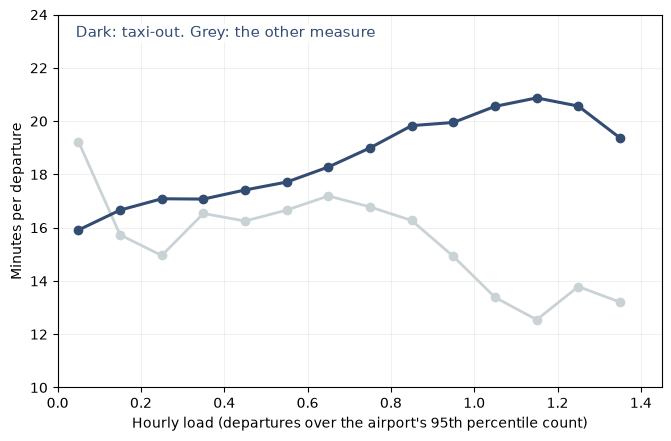

- **Measure:** Taxi-out
- **Year:** 2023
- **Smallest bin kept:** load 0.05, 22,576 departures
- **Mean at load 0.05 (minutes):** 15.91
- **Mean at load 1.15 (minutes):** 20.87
- **Change (minutes):** 4.96
- **Bins kept:** 14

Between the bin at load 0.05 and the bin at load 1.15 the mean rises: 20.87 - 15.91 = 4.96 minutes. Taxi-out is a proxy for runway queueing, and departure delay measures lateness against a schedule, so their slopes differ because they cover different stages. The pooled curve crosses thirty airports and is no one airport's. Bins under 20,000 departures are dropped, and a constructed larger cutoff changes which bins remain.

In [18]:
show(two_measures(measure='taxi', year=2023, min_flights=20000))

**Use the idea.** Plot the physical waiting time against load beside the target based statistic before pricing a change.

**Where the conclusion applies.** Bin means are weighted by scheduled departures and pool thirty airports. The different slopes do not identify padding, since the measures cover different stages.

*Constructed example on the published public record: the bin means are computed from it, and the minimum bin size is a constructed variable.*

Every setting the interactive reader offers for this demonstration:

In [19]:
sweep(two_measures, [('measure', ['taxi', 'delay']), ('year', [2023, 2024]), ('min_flights', [20000, 100000])])

- **measure = taxi, year = 2023, min_flights = 20000**: Measure Taxi-out; Year 2023; Smallest bin kept load 0.05, 22,576 departures; Mean at load 0.05 (minutes) 15.91; Mean at load 1.15 (minutes) 20.87; Change (minutes) 4.96; Bins kept 14
- **measure = taxi, year = 2023, min_flights = 100000**: Measure Taxi-out; Year 2023; Smallest bin kept load 0.25, 125,533 departures; Mean at load 0.25 (minutes) 17.09; Mean at load 1.15 (minutes) 20.87; Change (minutes) 3.79; Bins kept 10
- **measure = taxi, year = 2024, min_flights = 20000**: Measure Taxi-out; Year 2024; Smallest bin kept load 0.05, 23,680 departures; Mean at load 0.05 (minutes) 16.00; Mean at load 1.15 (minutes) 21.03; Change (minutes) 5.03; Bins kept 14
- **measure = taxi, year = 2024, min_flights = 100000**: Measure Taxi-out; Year 2024; Smallest bin kept load 0.25, 114,444 departures; Mean at load 0.25 (minutes) 17.26; Mean at load 1.15 (minutes) 21.03; Change (minutes) 3.77; Bins kept 10
- **measure = delay, year = 2023, min_flights = 20000**: Measure Departure delay against the schedule; Year 2023; Smallest bin kept load 0.05, 22,576 departures; Mean at load 0.05 (minutes) 19.23; Mean at load 1.15 (minutes) 12.54; Change (minutes) (-6.69); Bins kept 14
- **measure = delay, year = 2023, min_flights = 100000**: Measure Departure delay against the schedule; Year 2023; Smallest bin kept load 0.25, 125,533 departures; Mean at load 0.25 (minutes) 14.96; Mean at load 1.15 (minutes) 12.54; Change (minutes) (-2.41); Bins kept 10
- **measure = delay, year = 2024, min_flights = 20000**: Measure Departure delay against the schedule; Year 2024; Smallest bin kept load 0.05, 23,680 departures; Mean at load 0.05 (minutes) 18.40; Mean at load 1.15 (minutes) 14.48; Change (minutes) (-3.92); Bins kept 14
- **measure = delay, year = 2024, min_flights = 100000**: Measure Departure delay against the schedule; Year 2024; Smallest bin kept load 0.25, 114,444 departures; Mean at load 0.25 (minutes) 15.13; Mean at load 1.15 (minutes) 14.48; Change (minutes) (-0.65); Bins kept 10

## 2. A convex curve fitted to one year

*How far does the fitted curve sit from the bins it was fitted to, and from the next year's?*

The grid search chose the curvature that minimizes the mean absolute error over the 2023 bins. A different curvature raises that error, and the next year's bins sit a little above the curve.

    a base plus a curvature times the squared excess of load over a knee

**Symbols and inputs.** Load is unitless. Taxi-out is minutes per departure. Base is 16.79 minutes and the knee 0.0, both from the fit, and curvature is minutes per unit of squared load.

**Predict first.** At the fitted curvature, will the error against 2024 be smaller or larger than against 2023?

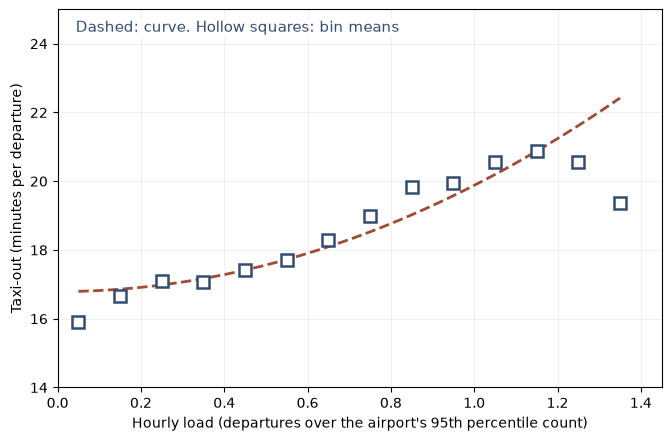

- **Curvature (minutes per unit of squared load):** 3.09
- **Year scored:** 2023
- **Bins scored:** 14
- **Mean absolute error (minutes):** 0.54
- **Curve at load 1.35 (minutes):** 22.42
- **Bin mean at load 1.35 (minutes):** 19.37

The curve is 16.79 + 3.09 x load squared, with the knee at 0.0. At load 1.35 it gives 16.79 + 3.09 x 1.35 x 1.35 = 22.42 against a bin mean of 19.37, a miss of 3.05 minutes. The mean absolute error over the 14 bins is 0.54 minutes. This is the fitted curvature, inferred by the grid search from the 2023 bins. A convex form cannot bend down, so the thin top bins are where form and record part.

In [20]:
show(curve_against_bins(curvature=3.09, year=2023))

**Use the idea.** Hold out a second period and report its error beside the fit error.

**Where the conclusion applies.** A convex form, so it cannot follow the easing of the two thinnest top bins. The fit does not place a knee. The mechanism is not identified.

*Constructed example on the published public record: the base and knee are inferred from it, and the other curvatures are constructed values.*

Every setting the interactive reader offers for this demonstration:

In [21]:
sweep(curve_against_bins, [('curvature', [2.0, 3.09, 4.0]), ('year', [2023, 2024])])

- **curvature = 2.0, year = 2023**: Curvature (minutes per unit of squared load) 2.00; Year scored 2023; Bins scored 14; Mean absolute error (minutes) 0.80; Curve at load 1.35 (minutes) 20.43; Bin mean at load 1.35 (minutes) 19.37
- **curvature = 2.0, year = 2024**: Curvature (minutes per unit of squared load) 2.00; Year scored 2024; Bins scored 14; Mean absolute error (minutes) 1.12; Curve at load 1.35 (minutes) 20.43; Bin mean at load 1.35 (minutes) 20.76
- **curvature = 3.09, year = 2023**: Curvature (minutes per unit of squared load) 3.09; Year scored 2023; Bins scored 14; Mean absolute error (minutes) 0.54; Curve at load 1.35 (minutes) 22.42; Bin mean at load 1.35 (minutes) 19.37
- **curvature = 3.09, year = 2024**: Curvature (minutes per unit of squared load) 3.09; Year scored 2024; Bins scored 14; Mean absolute error (minutes) 0.64; Curve at load 1.35 (minutes) 22.42; Bin mean at load 1.35 (minutes) 20.76
- **curvature = 4.0, year = 2023**: Curvature (minutes per unit of squared load) 4.00; Year scored 2023; Bins scored 14; Mean absolute error (minutes) 0.84; Curve at load 1.35 (minutes) 24.08; Bin mean at load 1.35 (minutes) 19.37
- **curvature = 4.0, year = 2024**: Curvature (minutes per unit of squared load) 4.00; Year scored 2024; Bins scored 14; Mean absolute error (minutes) 0.69; Curve at load 1.35 (minutes) 24.08; Bin mean at load 1.35 (minutes) 20.76

## 3. Pricing a cap needs two points on the curve

*What does capping the busiest hours buy, and what does it cost?*

The benefit is the curve at the load as filed minus the curve at the capped load. Both must sit on the curve, so the slope between them is what prices the cap.

    a difference of the curve at two loads

**Symbols and inputs.** Load is as filed. A cap replaces the load with a lower fixed one. Benefit is minutes of taxi-out above the lowest-load bin per peak departure. Movements lost are shares of scheduled departures.

**Predict first.** At the record's mean peak load, does the p90 cap buy more or less than twice what the p95 cap buys?

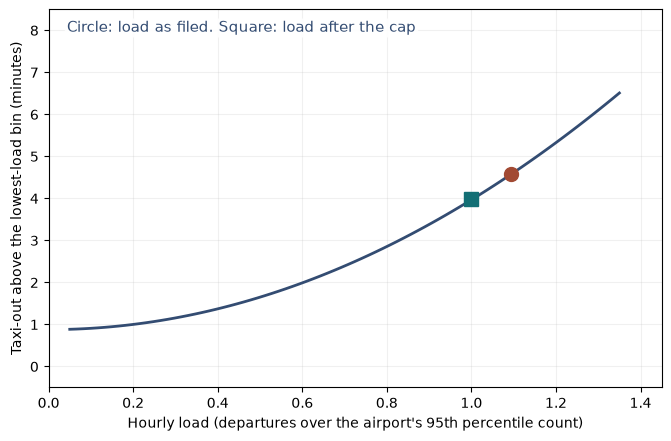

- **Cap:** p95
- **Load as filed:** 1.094
- **Load after the cap:** 1.000
- **Delay above baseline, as filed (minutes):** 4.59
- **Delay above baseline, capped (minutes):** 3.97
- **Benefit per peak departure (minutes):** 0.61
- **Departures kept by the cap (percent):** 98.95
- **Movements lost, model (percent):** 2.26

Benefit = delay as filed - delay capped = 4.586 - 3.975 = 0.611 minutes per peak departure. Movements lost = 1 - 0.98945 x (1 - 0.01215) = 2.26 percent, which adds the cancellation slope to the departures above the cap. The curve is steeper at higher load, so the same cap buys more when the load as filed is higher. The pooled curve is inferred from the record and is no one airport's, and the loads shown are constructed.

In [22]:
show(cap_price(cap='cap_at_p95', load=1.0944))

**Use the idea.** Price a schedule change from the slope of the curve between two loads, not from an average.

**Where the conclusion applies.** The pooled curve is no one airport's. Departures above the cap are counted as lost, not moved. One representative peak hour a day. A tie appears when a cap does not bind.

*Constructed example on the published public record: the curve is inferred from it, the caps are the chapter's constructed policies, and the loads are constructed values.*

Every setting the interactive reader offers for this demonstration:

In [23]:
sweep(cap_price, [('cap', ['cap_at_p95', 'cap_at_p90']), ('load', [0.9958, 1.0944, 1.2218])])

- **cap = cap_at_p95, load = 0.9958**: Cap p95; Load as filed 0.996; Load after the cap 0.996; Delay above baseline, as filed (minutes) 3.95; Delay above baseline, capped (minutes) 3.95; Benefit per peak departure (minutes) 0.00; Departures kept by the cap (percent) 98.95; Movements lost, model (percent) 2.25
- **cap = cap_at_p95, load = 1.0944**: Cap p95; Load as filed 1.094; Load after the cap 1.000; Delay above baseline, as filed (minutes) 4.59; Delay above baseline, capped (minutes) 3.97; Benefit per peak departure (minutes) 0.61; Departures kept by the cap (percent) 98.95; Movements lost, model (percent) 2.26
- **cap = cap_at_p95, load = 1.2218**: Cap p95; Load as filed 1.222; Load after the cap 1.000; Delay above baseline, as filed (minutes) 5.50; Delay above baseline, capped (minutes) 3.97; Benefit per peak departure (minutes) 1.52; Departures kept by the cap (percent) 98.95; Movements lost, model (percent) 2.26
- **cap = cap_at_p90, load = 0.9958**: Cap p90; Load as filed 0.996; Load after the cap 0.899; Delay above baseline, as filed (minutes) 3.95; Delay above baseline, capped (minutes) 3.38; Benefit per peak departure (minutes) 0.57; Departures kept by the cap (percent) 97.34; Movements lost, model (percent) 3.76
- **cap = cap_at_p90, load = 1.0944**: Cap p90; Load as filed 1.094; Load after the cap 0.899; Delay above baseline, as filed (minutes) 4.59; Delay above baseline, capped (minutes) 3.38; Benefit per peak departure (minutes) 1.21; Departures kept by the cap (percent) 97.34; Movements lost, model (percent) 3.76
- **cap = cap_at_p90, load = 1.2218**: Cap p90; Load as filed 1.222; Load after the cap 0.899; Delay above baseline, as filed (minutes) 5.50; Delay above baseline, capped (minutes) 3.38; Benefit per peak departure (minutes) 2.12; Departures kept by the cap (percent) 97.34; Movements lost, model (percent) 3.76

## 4. Padding hides the delay it responds to

*How much of the realized delay does a schedule's padding hide after a year?*

Padding rises toward realized delay at a rate set by the adjustment time. The faster it adjusts, the less of the delay a schedule reports.

    delay a schedule reports is realized delay less padding.

**Symbols and inputs.** Realized delay and padding are minutes per departure. The padding adjustment time is in days. Load is as in the other demonstrations.

**Predict first.** With a 30 day adjustment time, is reported delay at day 365 larger or smaller than with 180 days?

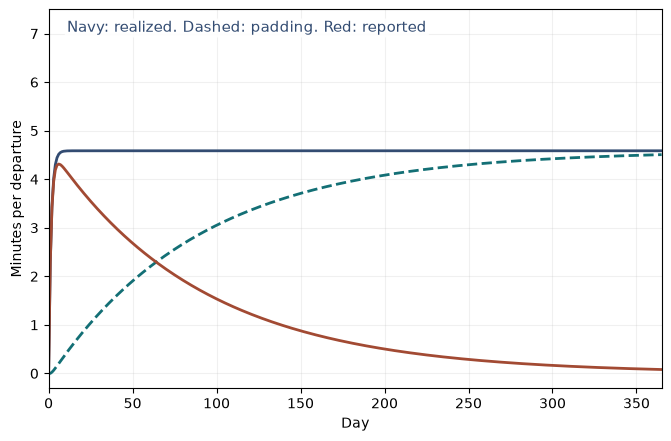

- **Padding adjustment time (days):** 90
- **Load:** 1.094
- **Realized delay, day 365 (minutes):** 4.59
- **Padding, day 90 (minutes):** 2.87
- **Padding, day 365 (minutes):** 4.51
- **Reported delay, day 365 (minutes):** 0.08

Reported delay = realized delay - padding = 4.59 - 4.51 = 0.08 minutes at day 365, and padding at day 90 is 2.87. A longer adjustment time lets the gap stay open longer, so less of the realized delay is hidden by the end of the year. The balancing loop closes the gap between the schedule and the delay, and it does not establish that padding caused the pattern in the record. Adjustment times and loads here are constructed settings.

In [24]:
show(padding_loop(time=90.0, load=1.0944))

**Use the idea.** To test a padding explanation, compare schedule buffers over time for comparable flights.

**Where the conclusion applies.** A model of one balancing loop, with adjustment times chosen here. The record does not establish a padding response, and other mechanisms can produce the same slopes.

*Constructed example on the published public record: the curve is inferred from it, and the adjustment times and loads are constructed values.*

Every setting the interactive reader offers for this demonstration:

In [25]:
sweep(padding_loop, [('time', [30.0, 90.0, 180.0]), ('load', [1.0944, 1.2218])])

- **time = 30.0, load = 1.0944**: Padding adjustment time (days) 30; Load 1.094; Realized delay, day 365 (minutes) 4.59; Padding, day 90 (minutes) 4.35; Padding, day 365 (minutes) 4.59; Reported delay, day 365 (minutes) 0.00
- **time = 30.0, load = 1.2218**: Padding adjustment time (days) 30; Load 1.222; Realized delay, day 365 (minutes) 5.50; Padding, day 90 (minutes) 5.22; Padding, day 365 (minutes) 5.50; Reported delay, day 365 (minutes) 0.00
- **time = 90.0, load = 1.0944**: Padding adjustment time (days) 90; Load 1.094; Realized delay, day 365 (minutes) 4.59; Padding, day 90 (minutes) 2.87; Padding, day 365 (minutes) 4.51; Reported delay, day 365 (minutes) 0.08
- **time = 90.0, load = 1.2218**: Padding adjustment time (days) 90; Load 1.222; Realized delay, day 365 (minutes) 5.50; Padding, day 90 (minutes) 3.44; Padding, day 365 (minutes) 5.40; Reported delay, day 365 (minutes) 0.10
- **time = 180.0, load = 1.0944**: Padding adjustment time (days) 180; Load 1.094; Realized delay, day 365 (minutes) 4.59; Padding, day 90 (minutes) 1.78; Padding, day 365 (minutes) 3.98; Reported delay, day 365 (minutes) 0.61
- **time = 180.0, load = 1.2218**: Padding adjustment time (days) 180; Load 1.222; Realized delay, day 365 (minutes) 5.50; Padding, day 90 (minutes) 2.13; Padding, day 365 (minutes) 4.77; Reported delay, day 365 (minutes) 0.73

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

If taxi-out is 15.9 minutes at load 0.05 and 20.9 at load 1.15, what is the change?

<details><summary>Answer</summary>

20.9 - 15.9 = 5.0 minutes.

</details>

### Exercise 2

If the curve gives 22.4 at load 1.35 and the bin mean is 19.4, what is the miss?

<details><summary>Answer</summary>

22.4 - 19.4 = 3.0 minutes.

</details>

### Exercise 3

If delay as filed is 4.58 and capped is 3.97, what is the benefit?

<details><summary>Answer</summary>

4.58 - 3.97 = 0.61 minutes per peak departure.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/